<a href="https://colab.research.google.com/github/shubha3/pTRpred/blob/main/Reproducible_Battery_Thermal_Runaway.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Specify the directories
import os
if not os.path.exists('NREL_Plots'):
    os.mkdir('NREL_Plots')
if not os.path.exists('NREL_Plots_SVD'):
    os.mkdir('NREL_Plots_SVD')
if not os.path.exists('Simulated_Datasets_Plots'):
    os.mkdir('Simulated_Datasets_Plots')
if not os.path.exists('T_Results_Whole'):
    os.mkdir('T_Results_Whole')
if not os.path.exists('NREL_Dataset'):
    os.mkdir("NREL_Dataset")
if not os.path.exists('Simulated_Datasets'):
    os.mkdir('Simulated_Datasets')
if not os.path.exists("NREL_Dataset_SVD"):
    os.mkdir('NREL_Dataset_SVD')
if not os.path.exists("Threshold_Sensitivity"):
    os.mkdir("Threshold_Sensitivity")


In [ ]:
!pip install adjustText

In [ ]:
#Unzip all of the Datasets:
!unzip NREL_Dataset/T_Results_Whole.zip -d /content/NREL_Dataset
!unzip NREL_Dataset_SVD/SVD_Results_Whole.zip -d /content/NREL_Dataset_SVD
!unzip T_Results_Whole/T_Results_Whole.zip -d /content/T_Results_Whole
!unzip Simulated_Datasets/Simulated_Datasets.zip -d /content/Simulated_Datasets
!unzip Simulated_Datasets_Plots/Simulated_Datasets_Plots.zip -d /content/Simulated_Datasets_Plots

unzip:  cannot find or open NREL_Dataset/T_Results_Whole.zip, NREL_Dataset/T_Results_Whole.zip.zip or NREL_Dataset/T_Results_Whole.zip.ZIP.
unzip:  cannot find or open NREL_Dataset_SVD/SVD_Results_Whole.zip, NREL_Dataset_SVD/SVD_Results_Whole.zip.zip or NREL_Dataset_SVD/SVD_Results_Whole.zip.ZIP.
Archive:  T_Results_Whole/T_Results_Whole.zip
  inflating: /content/T_Results_Whole/500mAh1-20S0C.xlsx_reform_severity_level2.csv_rt_detect_result_window100.csv  
  inflating: /content/T_Results_Whole/500mAh1-40S0C.xlsx_reform_severity_level2.csv_rt_detect_result_window100.csv  
  inflating: /content/T_Results_Whole/500mAh1-60S0C.xlsx_reform_severity_level2.csv_rt_detect_result_window100.csv  
  inflating: /content/T_Results_Whole/500mAh1-80S0C.xlsx_reform_severity_level2.csv_rt_detect_result_window100.csv  
  inflating: /content/T_Results_Whole/500mAh1-100S0C.xlsx_reform_severity_level2.csv_rt_detect_result_window100.csv  
  inflating: /content/T_Results_Whole/500mAh2-20S0C.xlsx_reform_severi

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import os
from matplotlib.colors import TwoSlopeNorm
from numpy import trapezoid
from math import factorial
from itertools import chain, combinations
import importlib.util
from matplotlib.lines import Line2D
import re
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


In [ ]:
#Apply the standard style configs for all of the plots:
def apply_standard_style():
    """The plots configs"""
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "axes.titlesize": 22,
        "axes.labelsize": 16,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 16,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "savefig.dpi": 300,
        "figure.constrained_layout.use": True,
        "figure.facecolor": 'white',
        'axes.facecolor': 'white'
    })

In [ ]:
def plot_battery_sensitivity(csv_path, SVD = True, battery_type_list = ['Lab/Generic', 'Lab/Custom'], window_prefix ='X30', threshold_level = 0.3, output_fig_name = 'Battery_Threshold_Sensitivity.png'):
    df = pd.read_csv(csv_path)
    if df.columns[0].startswith('Unnamed'):
        df = df.iloc[:, 1:]
    df.columns = [c.strip() for c in df.columns]
    value_cols = [c for c in df.columns if c.startswith(window_prefix + '_')]
    label_map = {1: 'Positive', 2: 'Unknown', 0: 'Negative'}
    palette = {'Negative': 'orange', 'Positive': 'steelblue', 'Unknown': 'firebrick'}
    plt.figure()
    if len(battery_type_list) == 4:
        fig, axes = plt.subplots(2, 2, figsize = (12, 15), constrained_layout = True)
    else:
        fig, axes = plt.subplots(1, 3, figsize = (18, 8), constrained_layout = True)
    axes_list = axes.flatten()
    for i, battery_type in enumerate(battery_type_list):
        ax = axes[i]
        df_sub = df[df['battery_category'] == battery_type].copy()
        df_long = pd.melt(
          df_sub, id_vars = ['Label'],
          value_vars = value_cols,
          var_name = 'threshold',
          value_name = 'real_time_detection_score')
        df_long['window_lower'] = df_long['threshold'].apply(lambda X: int(X.split("_")[0][1:]))
        df_long['window_higher'] = df_long['threshold'].apply(lambda X: int(X.split("_")[1]))
        #Filtering and Transformation
        value_cols = [c for c in df_sub.columns if c.startswith(window_prefix)]
        df_sub['threshold'] = 0.3
        df_long['Label_Text'] = df_long['Label'].map(label_map)
        sns.stripplot(
            data=df_long, x='threshold', y='real_time_detection_score', hue='Label_Text',
            palette=palette, ax=ax, jitter=0.25, size=8, alpha=0.7, legend = False)
        ax.set_ylim(0.15, 0.8)
        ax.axhline(y=threshold_level, color='brown', linestyle='--', linewidth=2)
        #Setting the Title labels:
        title_suffix = " (SVD Procedure)" if SVD else ""
        ax.set_title(f"{battery_type}{title_suffix}", fontweight='bold', pad=10)
        ax.set_xlabel('Maximal Window Size')
        ax.set_ylabel('Maximal Detected Value')
    #Creating Legend Manually:
    legend_handles = [
        Line2D([0], [0], marker="o", color="w", label="Negative",
               markerfacecolor=palette["Negative"], markeredgecolor="black", markersize=9),
        Line2D([0], [0], marker="o", color="w", label="Positive",
               markerfacecolor=palette["Positive"], markeredgecolor="black", markersize=9),
        Line2D([0], [0], marker="o", color="w", label="Unknown",
               markerfacecolor=palette["Unknown"], markeredgecolor="black", markersize=9),
        Line2D([0], [0], color="#7F2704", linestyle="--", linewidth=2.2,
               label=f"Threshold = {threshold_level}")
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=4,
        bbox_to_anchor=(0.5, -0.075),
        frameon=True,
        fancybox=True
    )
    plt.savefig(output_fig_name, bbox_inches='tight')
    plt.close()
    print(f"Standardized plot saved as: {output_fig_name}")

In [ ]:
plot_battery_sensitivity('battery_cell_SVD_whole_stats.csv', SVD = True, battery_type_list = ['Commercial (LCO)', 'Soteria', 'Soteria (Control)'],
                         window_prefix = 'X10', threshold_level = 0.3, output_fig_name = 'Battery_Threshold_Sensitivity_SVD_X10.png')

FileNotFoundError: [Errno 2] No such file or directory: 'battery_cell_SVD_whole_stats.csv'

In [ ]:
plot_battery_sensitivity('battery_cell_SVD_whole_stats.csv', SVD = True, battery_type_list = ['Commercial (LCO)', 'Soteria', 'Soteria (Control)'],
                         window_prefix = 'X40', threshold_level = 0.3, output_fig_name = 'Battery_Threshold_Sensitivity_SVD_X40.png')

Standardized plot saved as: Battery_Threshold_Sensitivity_SVD_X40.png


<Figure size 1600x2000 with 0 Axes>

In [ ]:
plot_battery_sensitivity('battery_cell_SVD_whole_stats.csv', SVD = True, battery_type_list = ['Commercial (LCO)', 'Soteria', 'Soteria (Control)'],
                         window_prefix = 'X10', threshold_level = 0.3, output_fig_name = 'Battery_Threshold_Sensitivity_SVD_X10.png')

Standardized plot saved as: Battery_Threshold_Sensitivity_SVD_X10.png


<Figure size 1600x2000 with 0 Axes>

In [ ]:
#The plots for the NREL dataset: temperature ~ real-time detected score results:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'figure.constrained_layout.use': True,
    'axes.grid': False,
    'savefig.dpi': 300
})
THRESHOLD = 0.3
POINTS_AFTER_DETECTED = 200

def plot_dual_axis_overlay(df, title, ax = None, time_col = 'time_ind',
                           signal_col = 'temperature'):
    if ax is None:
        fig, ax1 = plt.subplots(figsize = (16, 16))
    else:
        ax1 = ax
    color_temp = 'darkblue'
    ax1.plot(df['time_ind'], df['temperature'], color = color_temp, lw = 1.5, label = 'Temperature')
    ax1.set_xlabel('Time Index (0.1 s)')
    ax1.set_ylabel('Temperature (°C)', color = color_temp)
    ax1.tick_params(axis = 'y', labelcolor = color_temp)
    ax2 = ax1.twinx()
    color_det = 'red'
    ax2.plot(df['time_ind'], df['detected_value_rt'], color = color_det, lw = 1.5, label = 'Detected Value')
    ax2.set_ylabel('Real-Time Detected Value', color = color_det)
    ax2.tick_params(axis = 'y', labelcolor = color_det)
    ax2.axhline(y = THRESHOLD, color = 'darkgreen', linestyle = '--', lw = 1.5)
    idx_over = df[df['detected_value_rt'] >= THRESHOLD].index
    if not idx_over.empty:
        first_t = df.loc[idx_over, 'time_ind']
        ax2.axvline(x = first_t, color = 'steelblue', linestyle = ':', lw = 1.5)
    ax1.set_title(title, fontsize = 14, fontweight = 'bold')
    return ax1

In [ ]:
#Multiple Plots:
def plot_multi_data(meta_df, cell_id, data_dir):
    sub_df = meta_df[meta_df['cell'] == cell_id].sort_values('SOC', ascending = False)
    n_plots = len(sub_df)
    cols = 2 if n_plots <= 4 else 3
    rows = int(np.ceil(n_plots/ cols))
    fig, axes = plt.subplots(rows, cols, figsize = (6 * cols, 4.5 * rows))
    for i, (_, row) in enumerate(sub_df.iterrows()):
        file_path = os.path.join(data_dir, row['file'])
        df = pd.read_csv(file_path)
        df['time_ind'] = np.arange(len(df))
        idx_over = df[df['detected_value_rt'] >= THRESHOLD].index
        if not idx_over.empty:
            end_idx = min(len(df), idx_over + POINTS_AFTER_DETECTED)
            df_window = df.iloc[:end_idx].copy()
            temp_at_03 = df.loc[idx_over, 'temperature']
            title = f"{row['SOC']}% SOC\nTemp@0.3: {temp_at_03:.1f}°C"
        else:
            df_window = df.head(1000).copy()
            title = f"{row['SOC']}% SOC (No Detect)"
        plot_dual_axis_overlay(df_window, title, ax = axes[i])
    fig.subtitle(f"Multi-SOC Analysis: {cell_id}", fontsize = 20, fontweight = 'bold')
    plt.savefig(f"NREL_cursor/{cell_id}_multiSOC_py.png")
    plt.show()


In [ ]:
def parse_metadata(file_list):
    records = []
    for f in file_list:
        soc_match = re.search(r'-(\d+)(?:SOC|SOC)', f, re.IGNORECASE)
        if soc_match:
            soc = int(soc_match.group(1))
            cell = f.split(f"-{soc}")
            records.append(
                {'file': f,
                 'cell': cell,
                 'SOC': soc})
    return pd.DataFrame(records)

In [ ]:
def apply_standard_style():
    """The plots configs"""
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "axes.titlesize": 20,
        "axes.labelsize": 16,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 16,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "savefig.dpi": 300,
        "figure.constrained_layout.use": True,
        "figure.facecolor": 'white',
        'axes.facecolor': 'white'
    })

def plot_overlay_on_ax(ax, df, title, threshold = 0.3):
    ax2 = ax.twinx()
    l1, _ = ax.plot(df['time_ind'], df['temperature'], color = 'darkblue', lw = 1.5, label = 'Temp')
    ax.set_ylabel('Temperature (°C)', color = 'darkblue')
    ax.tick_params(axis = 'y', labelcolor = 'darkblue')
    #
    l2 = ax2.plot(df['time_ind'], df['detected_value_rt'], color = 'red', lw = 1.5, label = 'Detection')
    ax2.set_ylabel('Real-Time Detected Score', color = 'red')
    ax2.tick_params(axis = 'y', labelcolor = 'red')
    ax2.set_ylim(-0.1, 1.1)
    ax2.axhline(y = threshold, color = 'darkgreen', linestyle = '--', lw = 1.5)
    ax.set_title(title, fontweight = 'bold', pad = 8)
    ax.set_xlabel('Time (0.1s)')
    return [l1, l2]

#Visualize the 2 * 2 plots for the Temperatures
def plot_battery_quad_T(file_list, threshold = 0.3, point_before = 100, point_after = 100,
                      output_name = 'cell1_name_list.png'):
    apply_standard_style()
    fig, axes = plt.subplots(2, 2, figsize = (16, 16))
    axes_flat = axes.flatten()
    for i, filename in enumerate(file_list):
        ax = axes_flat[i]
        df = pd.read_csv(filename)
        trigger_indices = df.index[df['detected_value_rt'] >= threshold].tolist()
        if trigger_indices:
            trigger_point = trigger_indices[0]
            start_idx = max(0, trigger_point - point_before)
            end_idx = min(len(df), trigger_point + point_after)
            df_plot = df.iloc[start_idx:end_idx,:].reset_index(drop = True)
            temp_at_trigger = df.iloc[trigger_point]['temperature']
        else:
            df_plot = df.iloc[:min(len(df), 1500)].reset_index(drop = True)
            temp_at_trigger = None
        #draw the two axis:
        ax_score = ax.twinx()
        line_t  = ax.plot(df_plot.index, df_plot['temperature'], color = '#1f77b4', lw = 2, label = 'Temperature')
        ax.set_ylabel('Temperature (°C)', color = '#1f77b4')
        ax.tick_params(axis = 'y', labelcolor = '#1f77b4')
        line_d = ax_score.plot(df_plot.index, df_plot['detected_value_rt'], color = '#d62728', lw = 2, label = 'Detection')
        ax_score.set_ylabel('Real-Time Detected Score', color = '#d62728')
        ax_score.tick_params(axis = 'y', labelcolor = '#d62728')
        ax_score.set_ylim(-0.2, 1.2)
        ax_score.axhline(y = THRESHOLD, color = 'green', ls = '--', alpha = 0.6)
        soc_match = re.search(r'-(\d+)(SOC|SOC)', filename, re.I)
        soc_str = f"{soc_match.group(1)}% SOC" if soc_match else 'Unknown SOC'
        cell_label = os.path.basename(filename).split('-')
        title_text = "Cell Name Visualization"
        if temp_at_trigger:
            title_text += f"\n The Temperature at Trigger: {temp_at_trigger:.1f}Temperature (°C)"
        ax.set_title(title_text, fontsize = 11, fontweight = 'bold')
        ax.set_label('Time Indice (0.1s)')
        legend_handles = [line_t, line_d]
    fig.legend(legend_handles, ['Temperature (°C)', 'Real-time Detection Score'],
               loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.02), frameon=True, edgecolor='black')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    #plt.suptitle("Battery Thermal Runaway Real-time Detection (2x2 Grid)",
    #             fontsize=18, fontweight='bold', y=1.03)
    # Saving the Figures
    plt.savefig(output_name, bbox_inches='tight')
    #plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os
def apply_standard_style():
    """The plots configs"""
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "axes.titlesize": 20,
        "axes.labelsize": 16,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 16,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "savefig.dpi": 300,
        "figure.constrained_layout.use": True,
        "figure.facecolor": 'white',
        'axes.facecolor': 'white'
    })
def plot_minimal_pro_T(filename, threshold=0.3, point_before=100, point_after=100,
                      output_name=None):
    if output_name is None:
        base_name = os.path.splitext(os.path.basename(filename))
        output_name = f"{base_name}_minimal_pro.png"
    fig, ax = plt.subplots(figsize=(13.5, 9.5))
    df = pd.read_csv(filename)
    trigger_indices = df.index[df['detected_value_rt'] >= threshold].tolist()
    if trigger_indices:
        trigger_point = trigger_indices[0] # Grab the first trigger
        start_idx = max(0, trigger_point - point_before)
        end_idx = min(len(df), trigger_point + point_after)
        df_plot = df.iloc[start_idx:end_idx].reset_index(drop=True)
        val = df.iloc[trigger_point]['temperature']
        temp_at_trigger = float(val.iloc if hasattr(val, 'iloc') else val)
    else:
        df_plot = df.iloc[:min(len(df), 1500)].reset_index(drop=True)
        temp_at_trigger = None
    time_seconds = df_plot.index * 0.1
    #fig, ax = plt.subplots(figsize=(13.5, 9.5))
    ax.plot(time_seconds, df_plot['temperature'], color='darkblue', lw=3)
    ax.set_ylabel('Temperature (°C)', color='darkblue', fontsize=20, fontweight='bold')
    ax.tick_params(axis='y', labelcolor='darkblue')
    ax_score = ax.twinx()
    ax_score.plot(time_seconds, df_plot['detected_value_rt'], color='#d62728', lw=3)
    ax_score.axhline(y=threshold, color='green', ls='--', alpha=0.5)
    ax_score.set_ylim(-0.1, 1.1)
    ax_score.set_ylabel('Detected Score', color='#d62728', fontsize=18, fontweight='bold')
    ax_score.tick_params(axis='y', labelcolor='#d62728')
    ax.set_xlabel('Seconds', fontsize=20, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_visible(False)
    for spine in ax_score.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    ax_score.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=20, length=4)
    ax_score.tick_params(axis='y', which='major', labelsize=20, length=4)
    cell_name = os.path.basename(filename).split('-')
    title_text = f"Battery Cell Thermal Analysis"
    if temp_at_trigger is not None:
        title_text += f" | Temp at Trigger: {temp_at_trigger:.1f}°C"
    ax.set_title(title_text, fontsize=22, fontweight='bold', pad=30)
    plt.tight_layout()
    plt.savefig(output_name, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Clean numerical plot saved: {output_name}")

In [ ]:
apply_standard_style()
plot_minimal_pro_T('NREL_Dataset/OE-10Ahr-NMC-100SOC-cell11.xlsx_reform_severity_level7.csv_rt_detect_result_window100.csv',
                      output_name = 'sample_data/OE-NMC10Ah-45SOC.xlsx_reform_severity_level7_plot.png')

/tmp/ipykernel_2691/1531362500.py:65: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Clean numerical plot saved: sample_data/OE-NMC10Ah-45SOC.xlsx_reform_severity_level7_plot.png


In [ ]:
#Visualize the 2 * 2 plots for the SVD Procedure
def plot_battery_quad_SVD(file_list, threshold = 0.3, point_before = 100, point_after = 100,
                      output_name = 'cell1_name_list.png'):
    apply_standard_style()
    fig, axes = plt.subplots(2, 2, figsize = (16, 16))
    axes_flat = axes.flatten()
    for i, filename in enumerate(file_list):
        ax = axes_flat[i]
        df = pd.read_csv(filename)
        trigger_indices = df.index[df['detected_value_rt'] >= threshold].tolist()
        if trigger_indices:
            trigger_point = trigger_indices[0]
            start_idx = max(0, trigger_point - point_before)
            end_idx = min(len(df), trigger_point + point_after)
            df_plot = df.iloc[start_idx:end_idx,:].reset_index(drop = True)
            temp_at_trigger = df.iloc[trigger_point]['temperature']
        else:
            df_plot = df.iloc[:min(len(df), 1500)].reset_index(drop = True)
            temp_at_trigger = None
        #draw the two axis:
        ax_score = ax.twinx()
        #Left Column(Blue):
        line_t  = ax.plot(df_plot.index, df_plot['temperature'], color = '#1f77b4', lw = 2, label = 'Temperature')
        ax.set_ylabel('Temperature (°C)', color = '#1f77b4')
        ax.tick_params(axis = 'y', labelcolor = '#1f77b4')
        #Right Column(Red):
        line_d = ax_score.plot(df_plot.index, df_plot['detected_value_rt'], color = '#d62728', lw = 2, label = 'Detection')
        ax_score.set_ylabel('Real-Time Detected Score', color = '#d62728')
        ax_score.tick_params(axis = 'y', labelcolor = '#d62728')
        ax_score.set_ylim(-0.2, 1.2)
        #The thresholding line:
        ax_score.axhline(y = THRESHOLD, color = 'green', ls = '--', alpha = 0.6)
        soc_match = re.search(r'-(\d+)(SOC|SOC)', filename, re.I)
        soc_str = f"{soc_match.group(1)}% SOC" if soc_match else 'Unknown SOC'
        cell_label = os.path.basename(filename).split('-')
        #title_text = f"Cell: {cell_label} | {soc_str}"
        title_text = "Cell Name Visualization"
        if temp_at_trigger:
            title_text += f"\n The Temperature at Trigger: {temp_at_trigger:.1f}Temperature (°C)"
        ax.set_title(title_text, fontsize = 16, fontweight = 'bold')
        ax.set_label('Time Indice (0.1s)')
        legend_handles = [line_t, line_d]
    fig.legend(legend_handles, ['Temperature (°C)', 'Real-time Detection Score'],
               loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.02), frameon=True, edgecolor='black')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(output_name, bbox_inches='tight')
    #plt.show()

In [ ]:
def apply_standard_style():
    """The plots configs"""
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "axes.titlesize": 20,
        "axes.labelsize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "savefig.dpi": 300,
        "figure.constrained_layout.use": True,
        "figure.facecolor": 'white',
        'axes.facecolor': 'white'
    })
apply_standard_style()

/tmp/ipykernel_9489/3738974194.py:76: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  fig.legend(legend_handles, ['Temperature (°C)', 'Real-time Detection Score'],
/tmp/ipykernel_9489/3738974194.py:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])
/tmp/ipykernel_9489/3738974194.py:76: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  fig.legend(legend_handles, ['Temperature (°C)', 'Real-time Detection Score'],
/tmp/ipykernel_9489/3738974194.py:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])
/tmp/ipykernel_9489/3738974194.py:76: UserWarning: Legend does not support handles for l

IsADirectoryError: [Errno 21] Is a directory: 'NREL_Data_Results/__MACOSX'

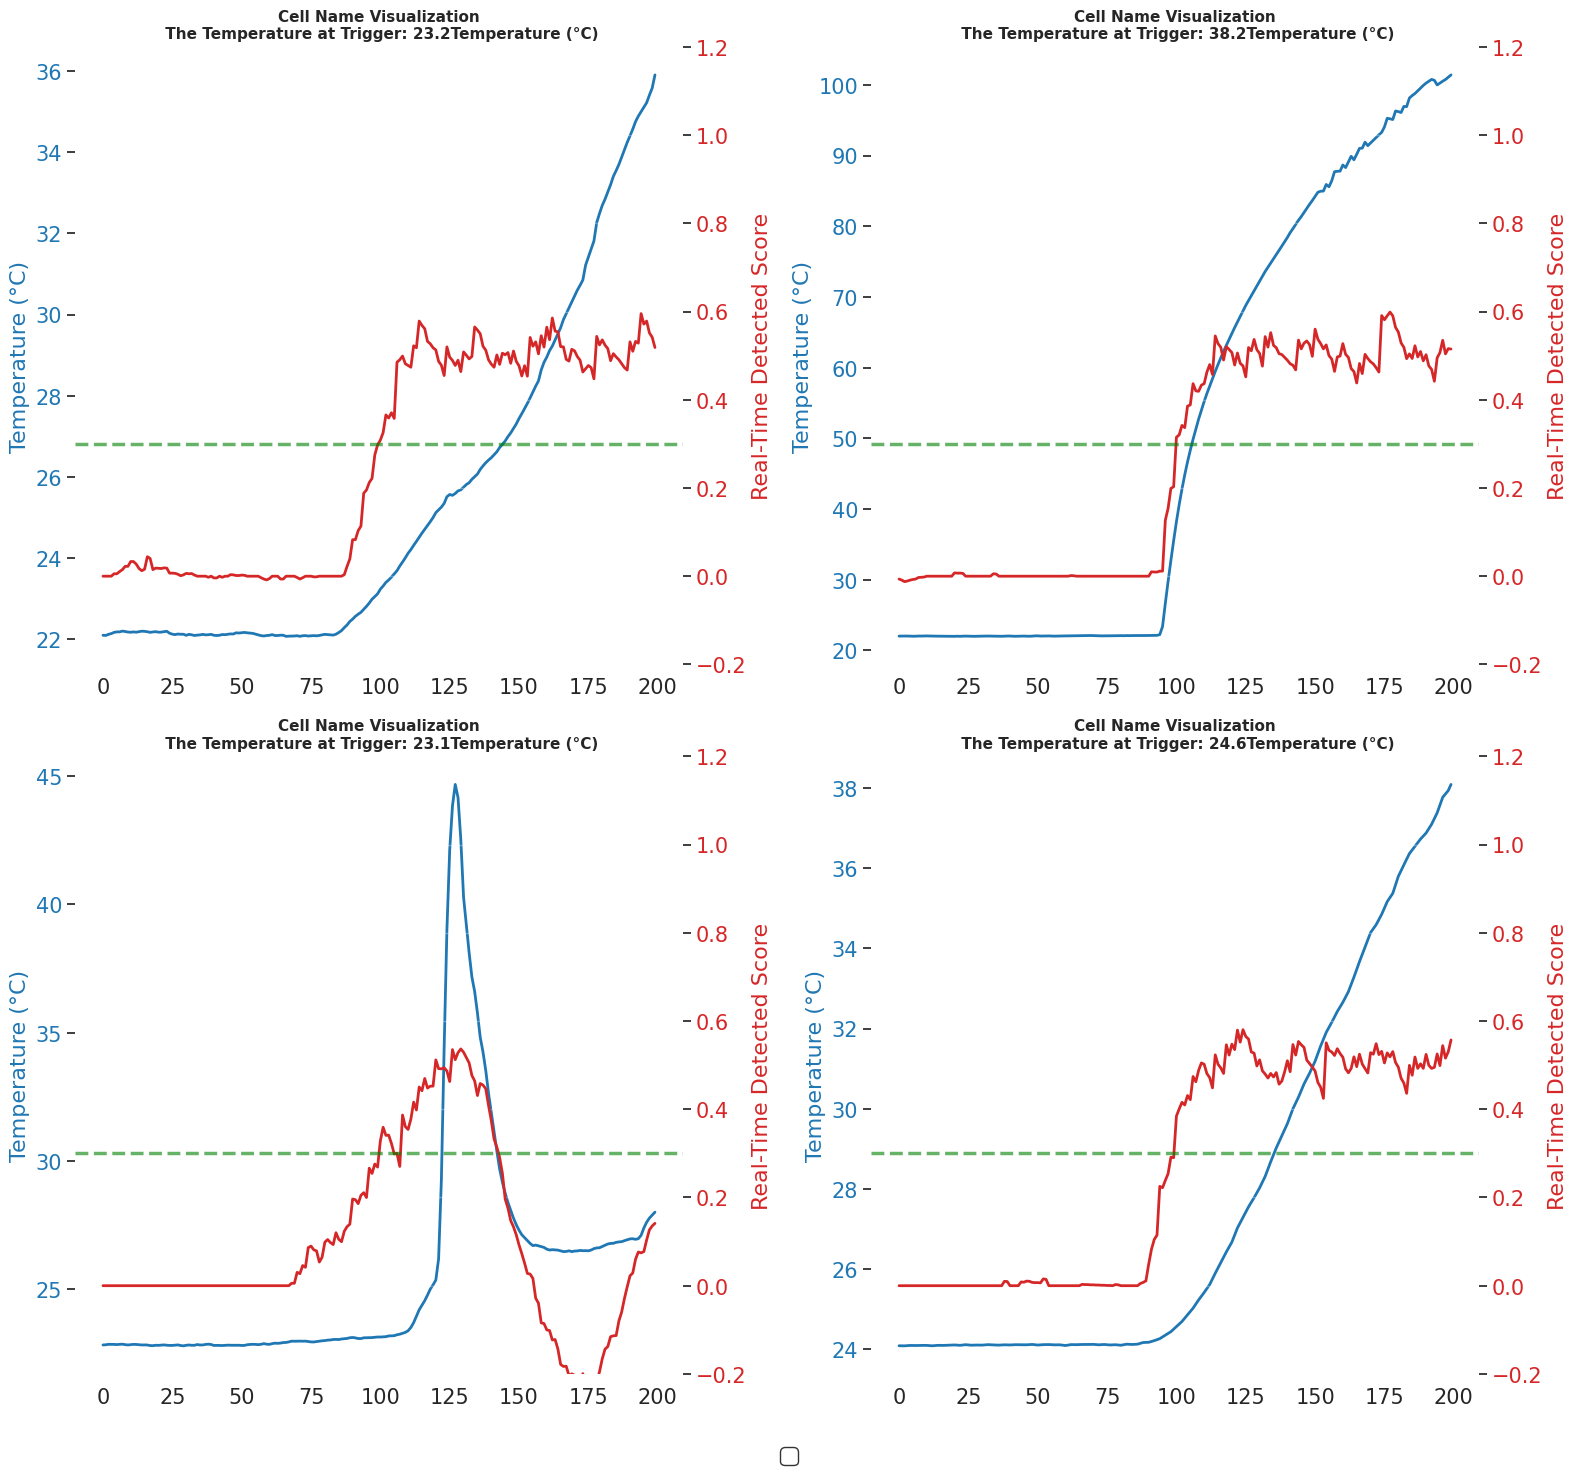

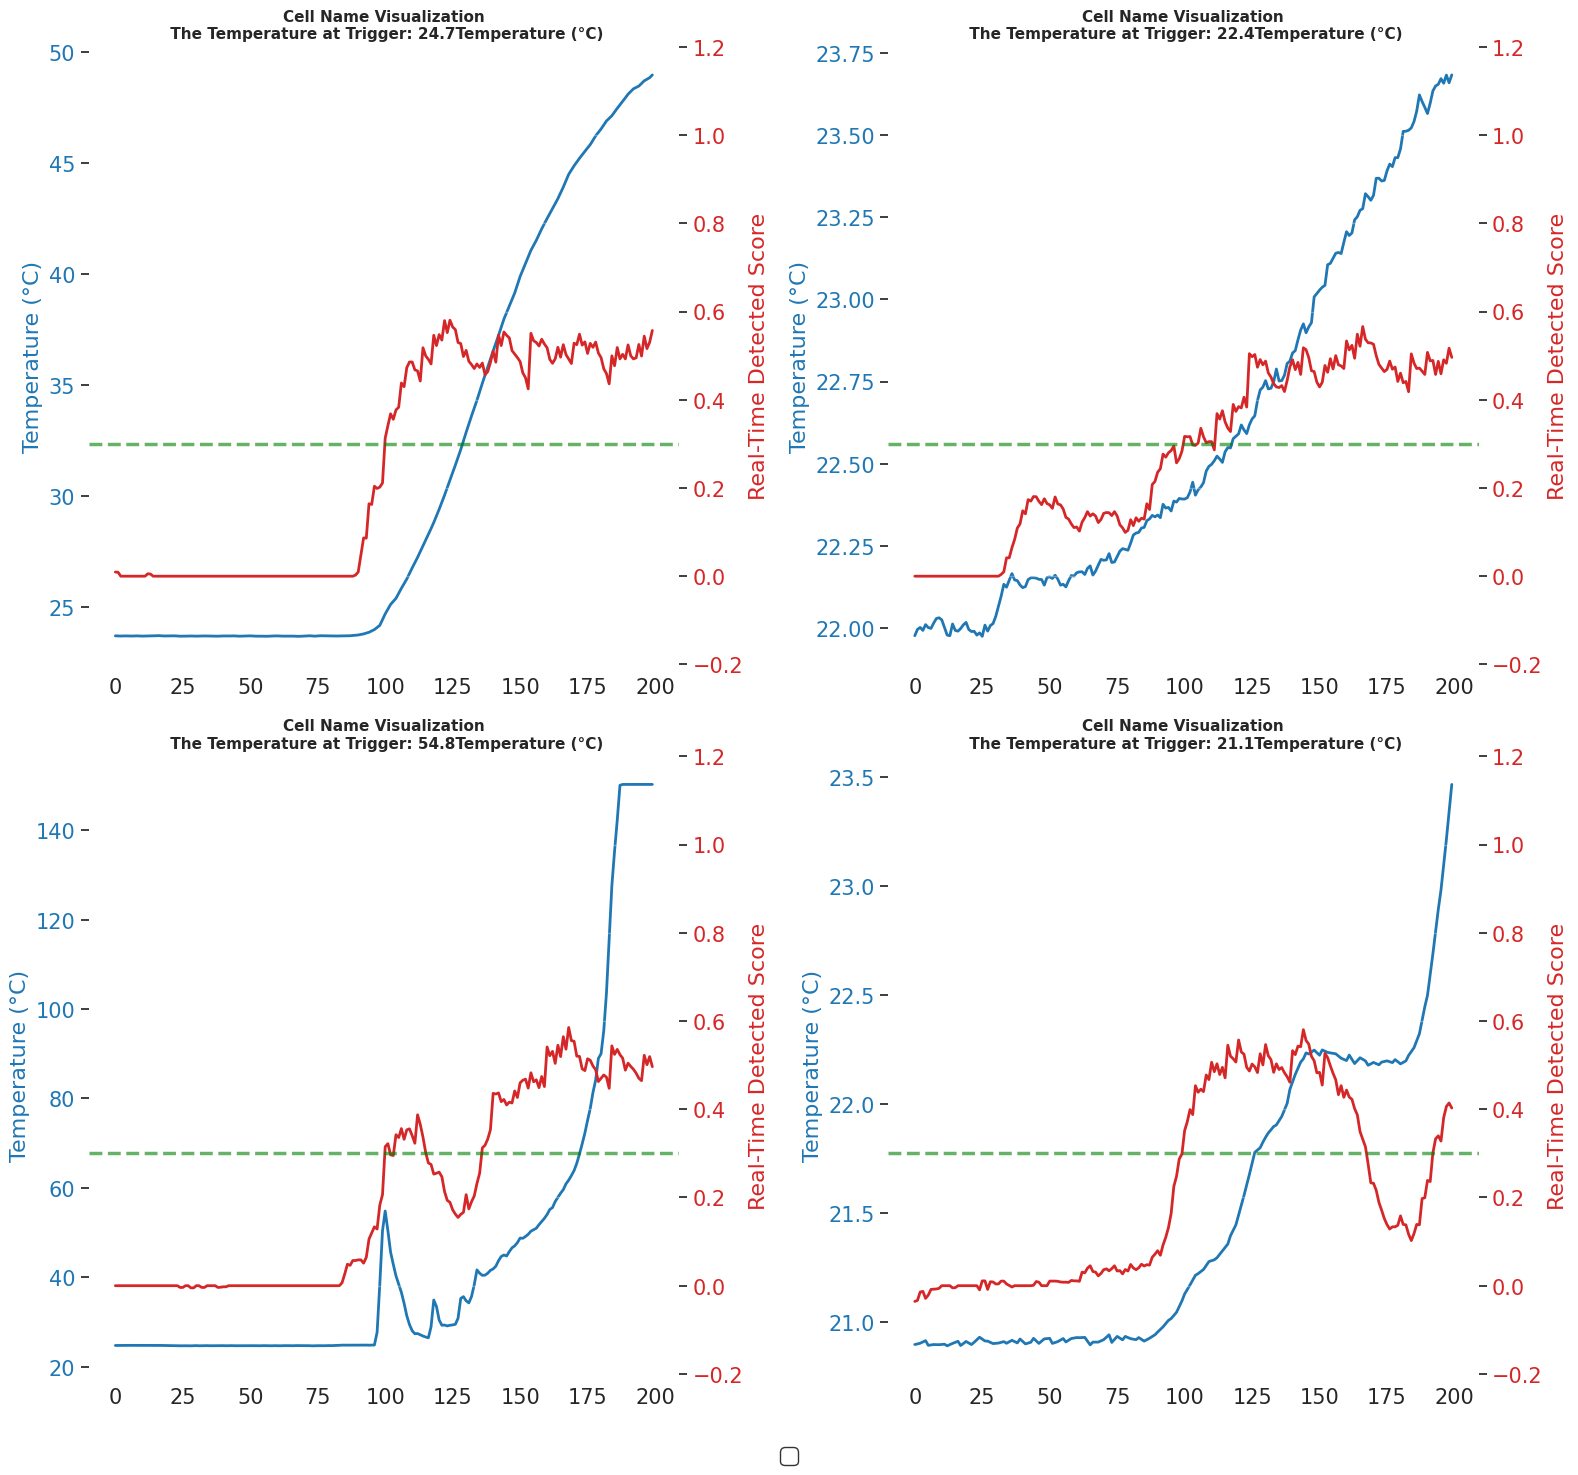

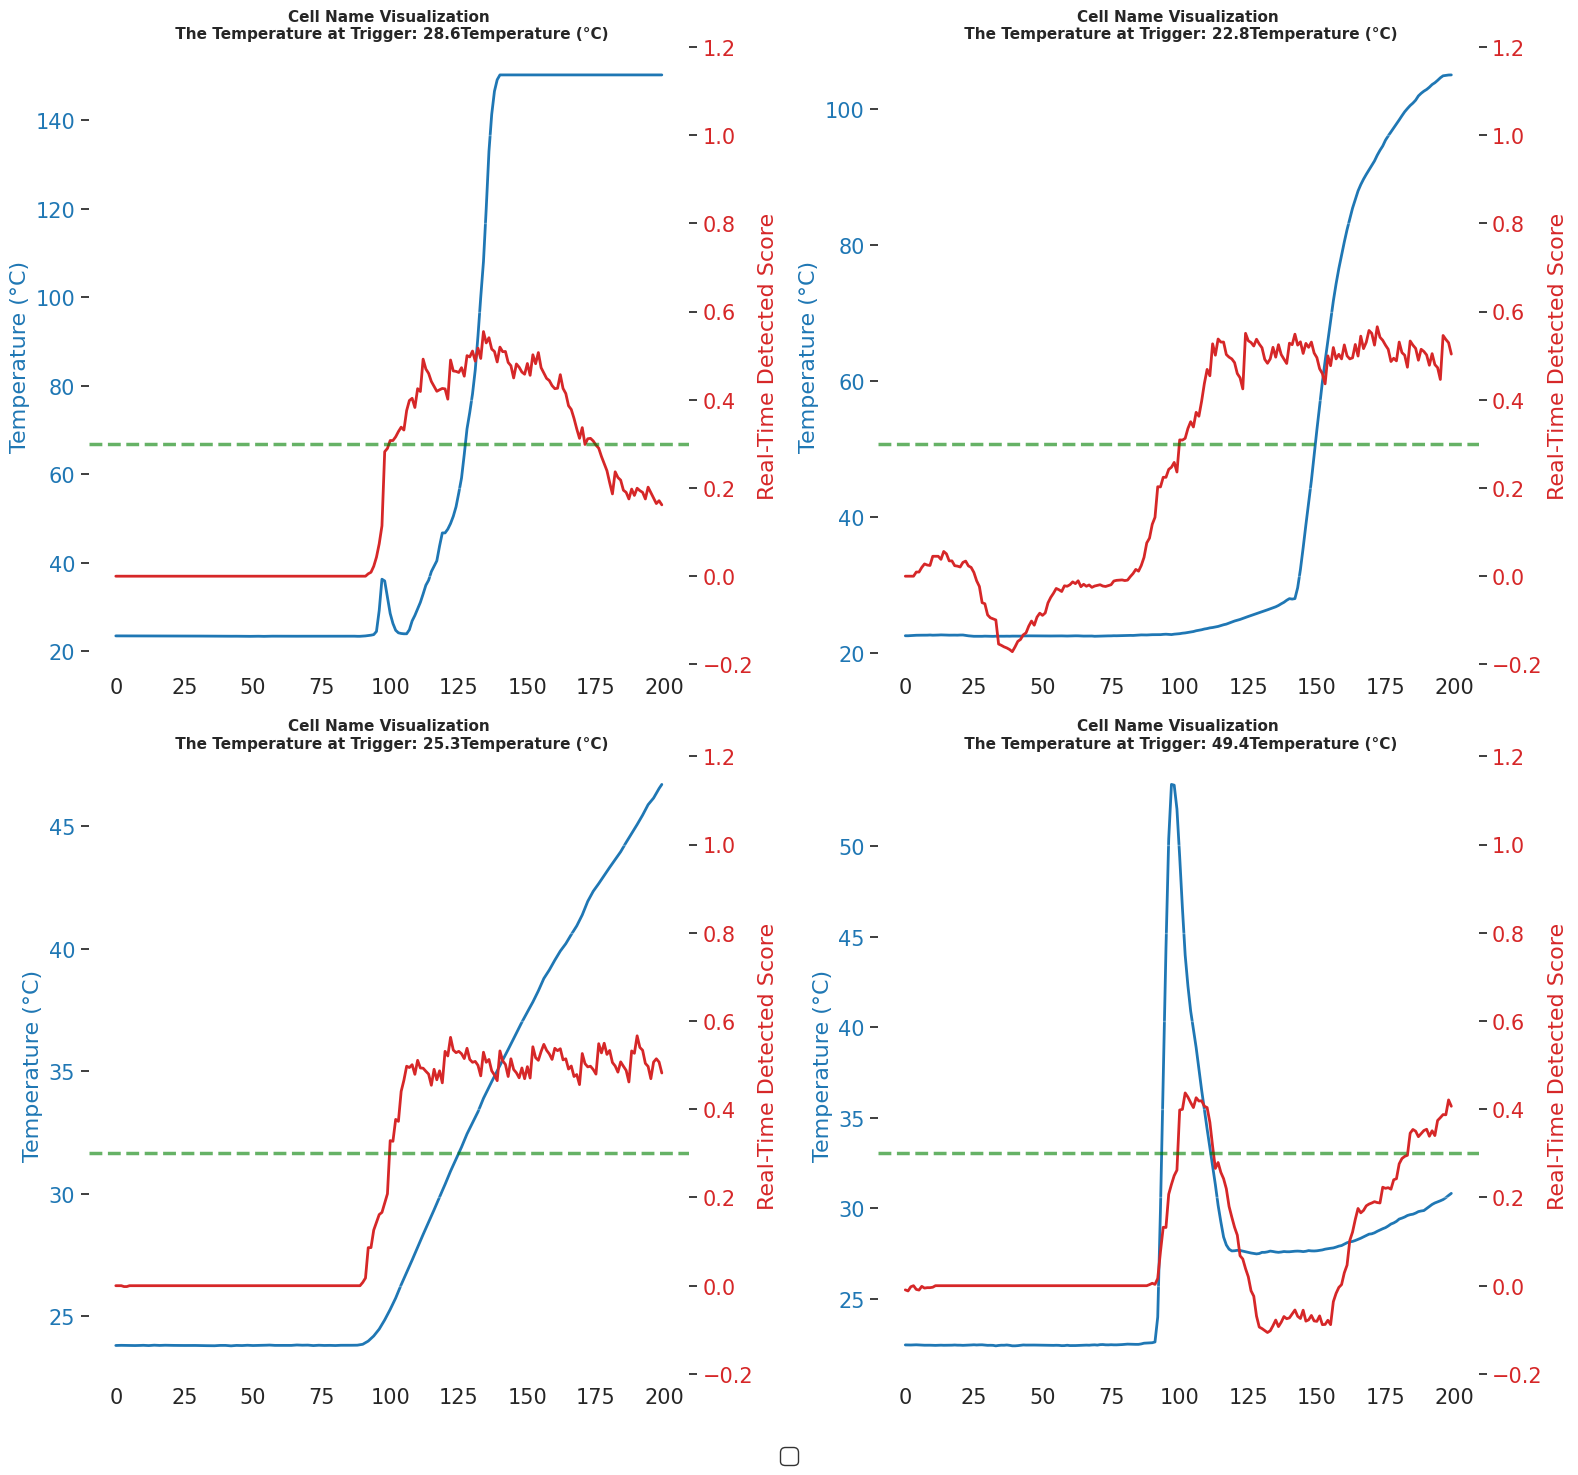

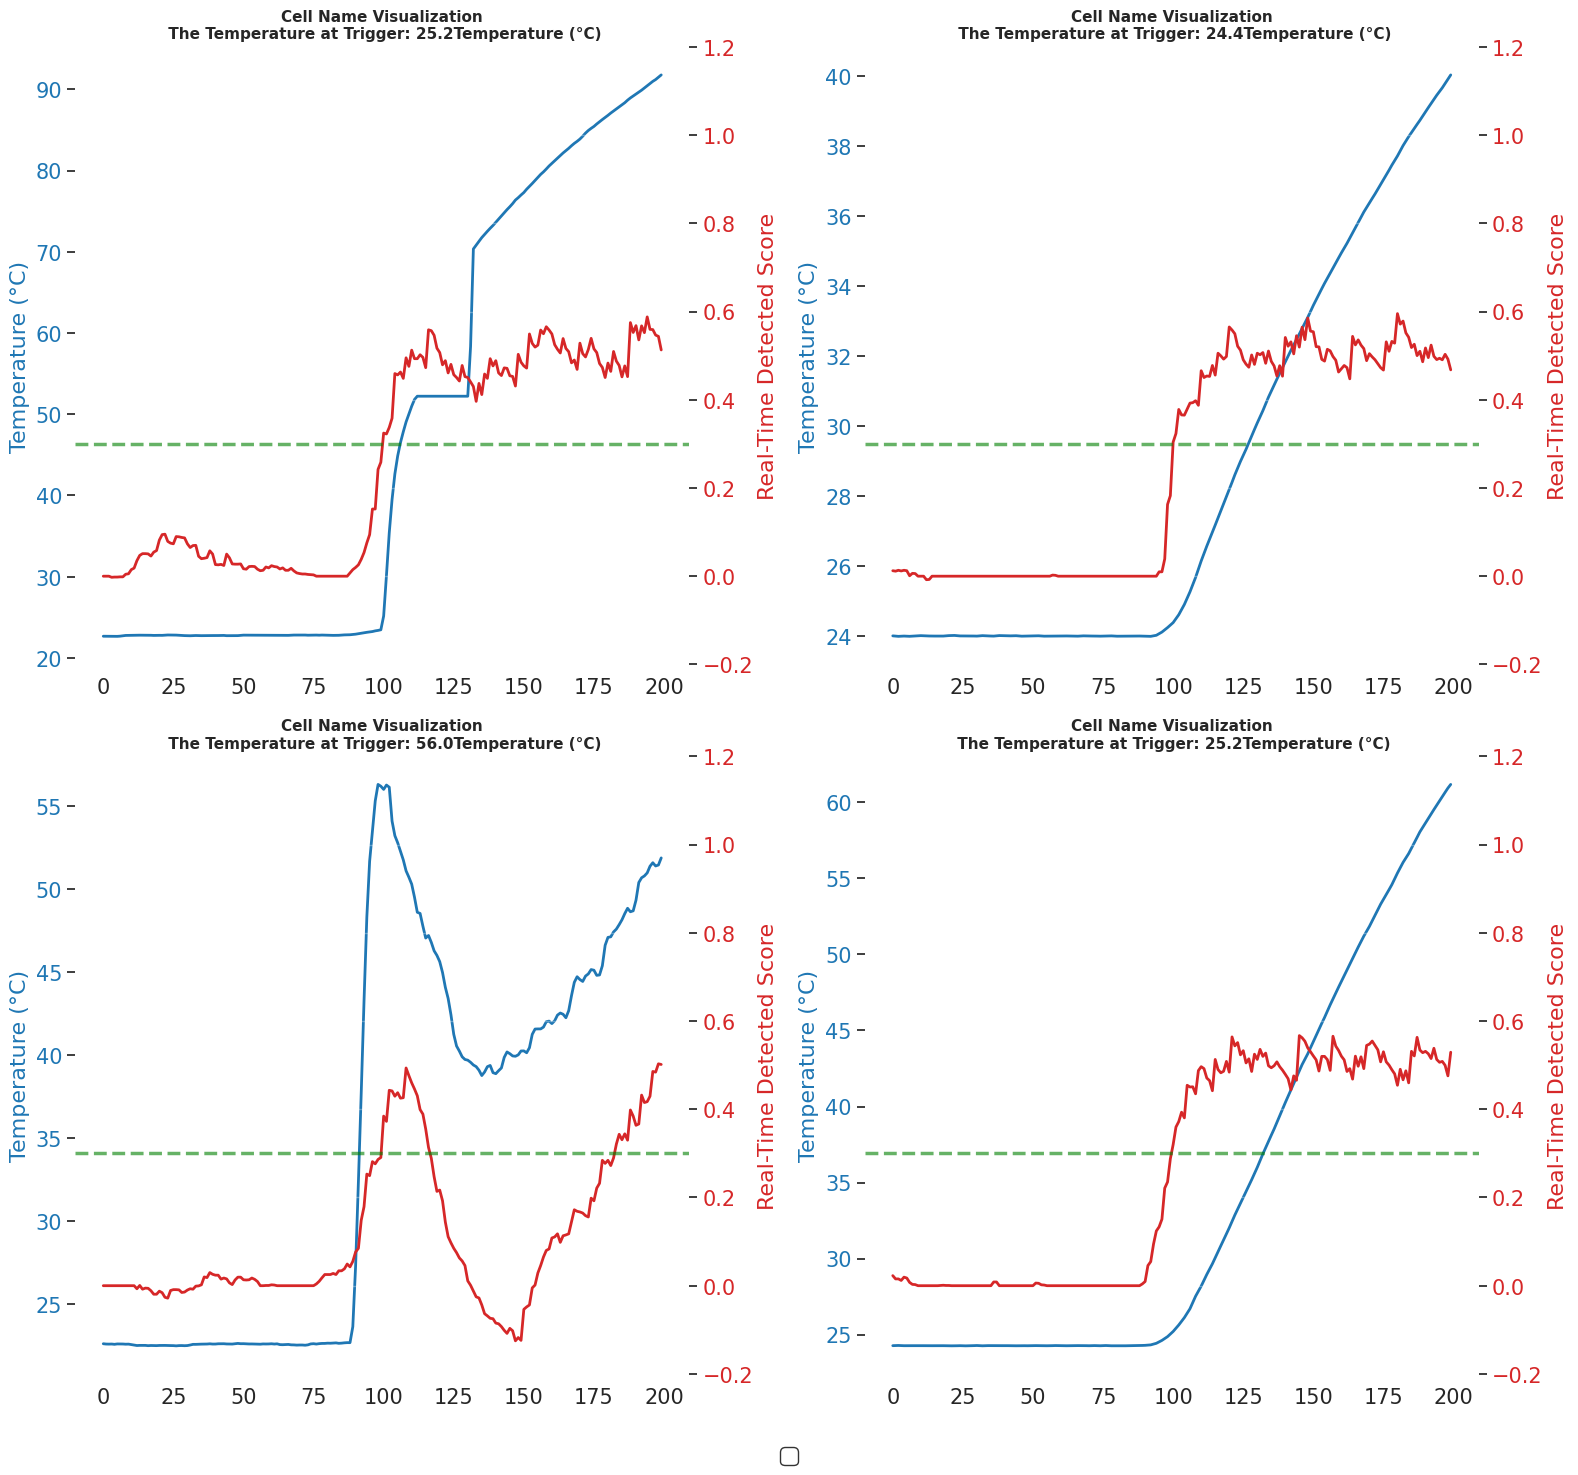

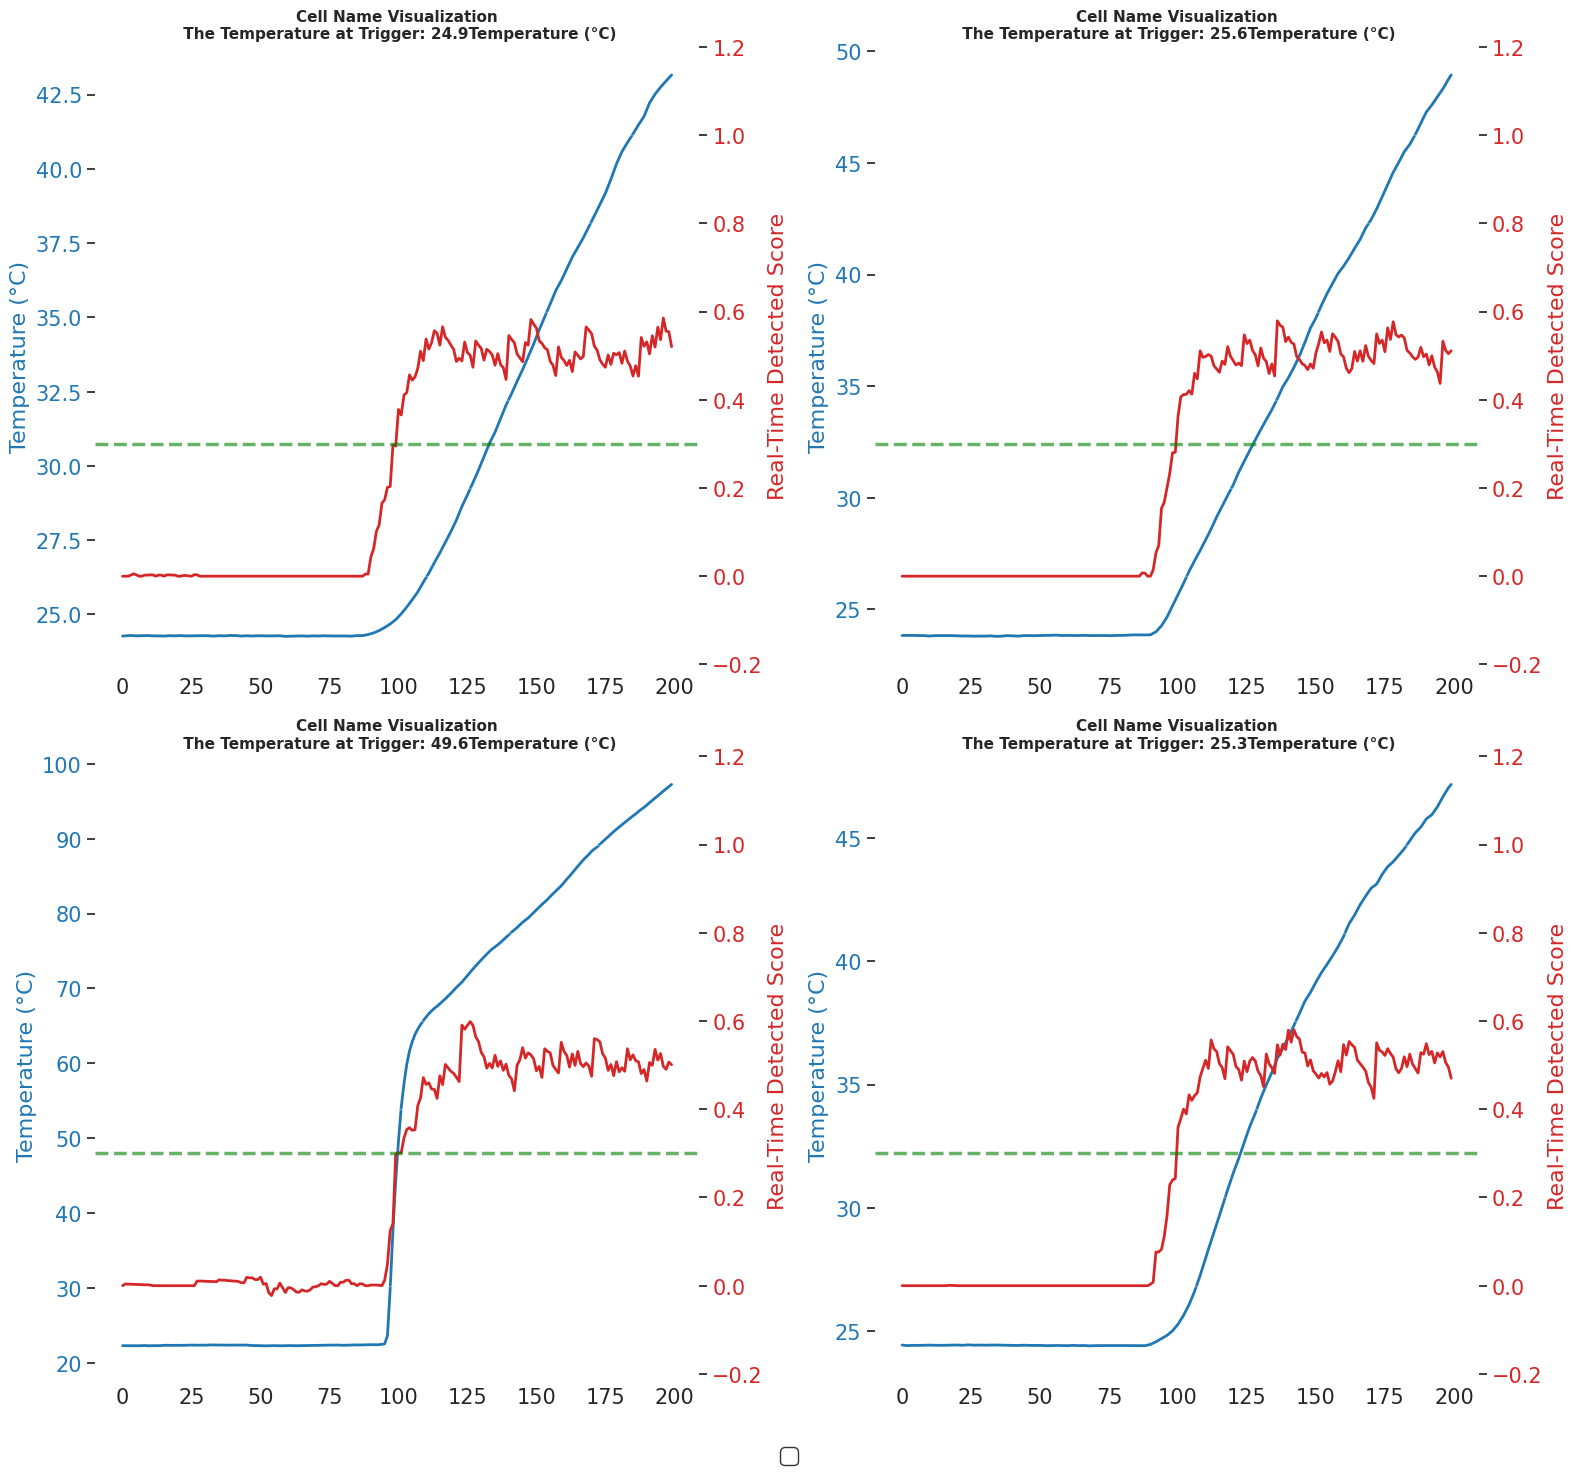

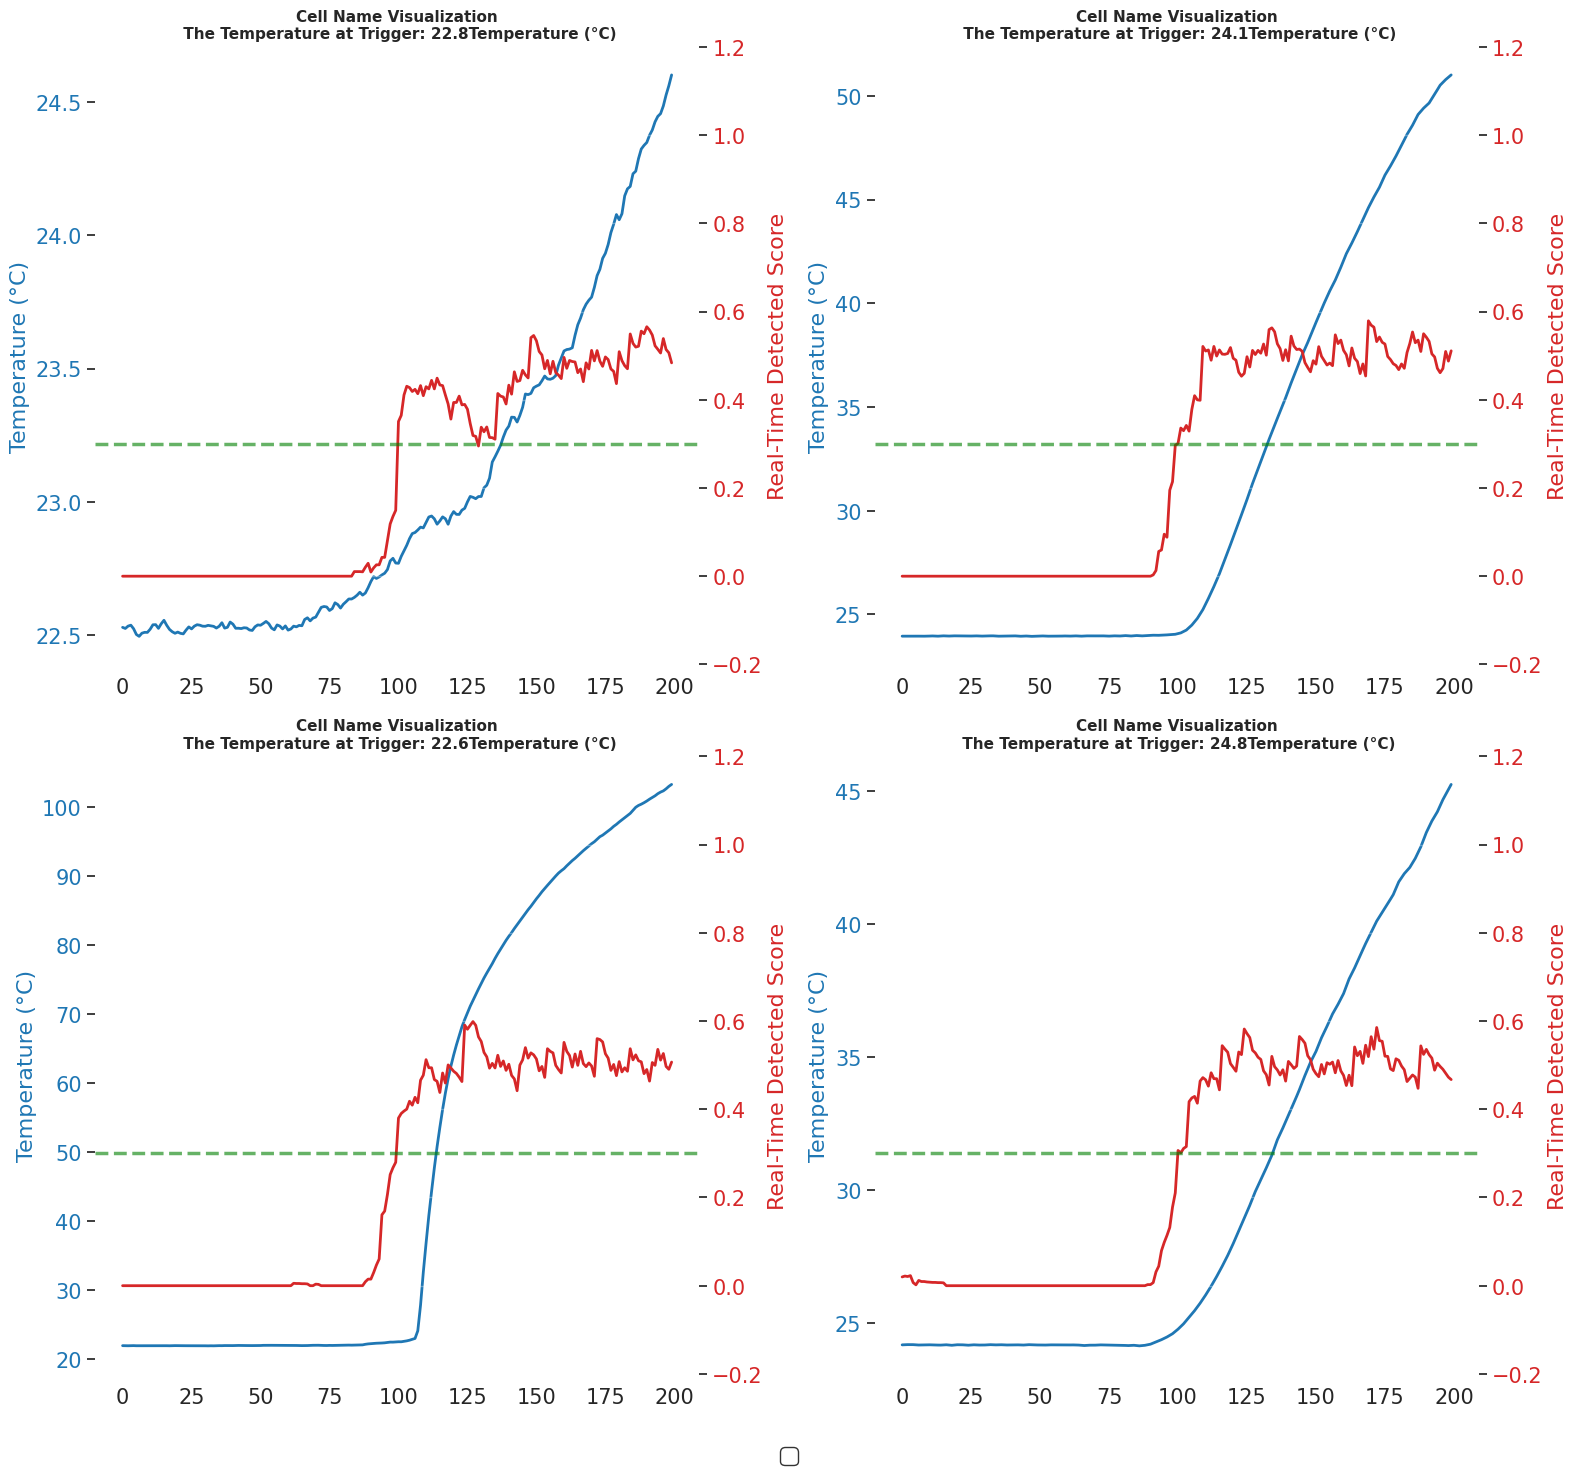

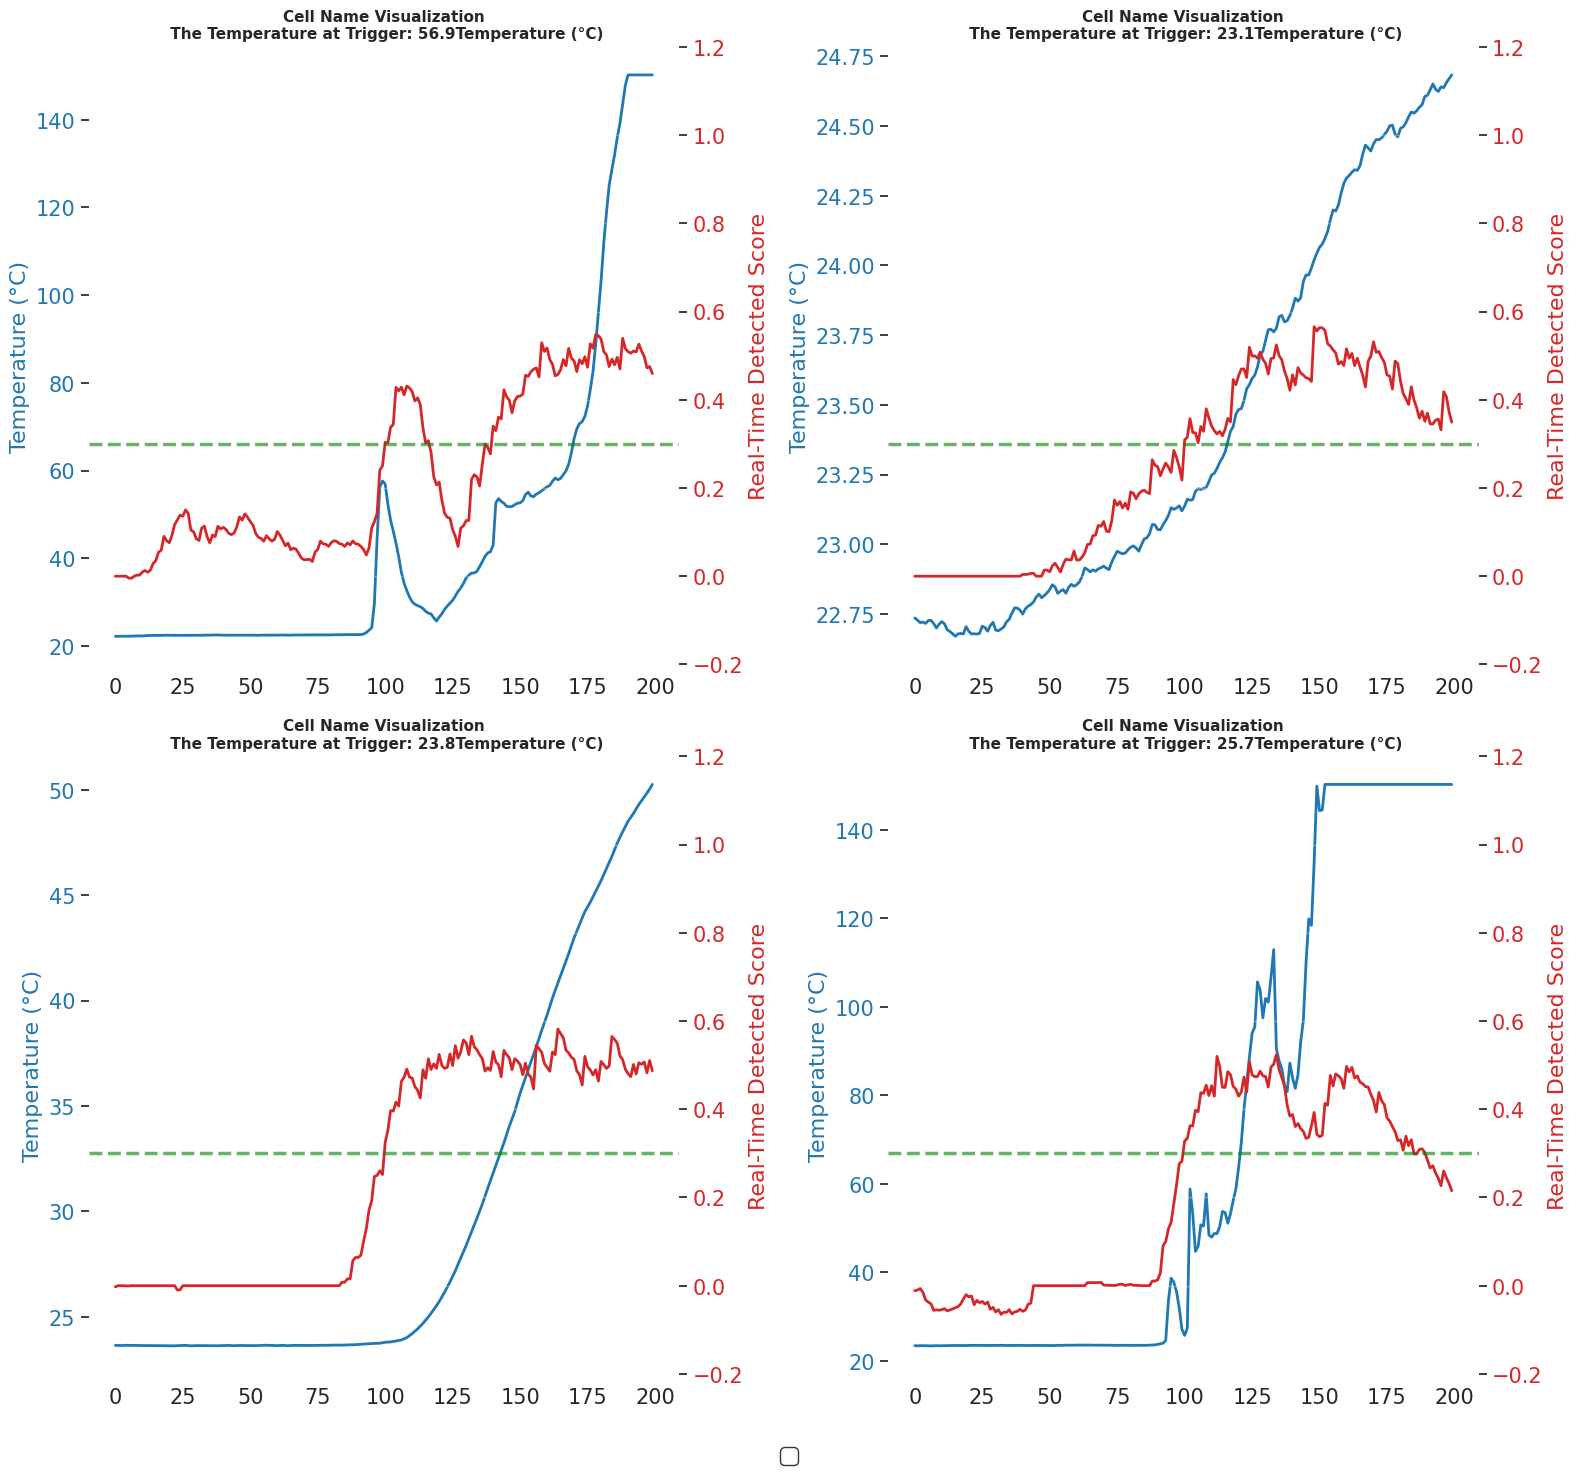

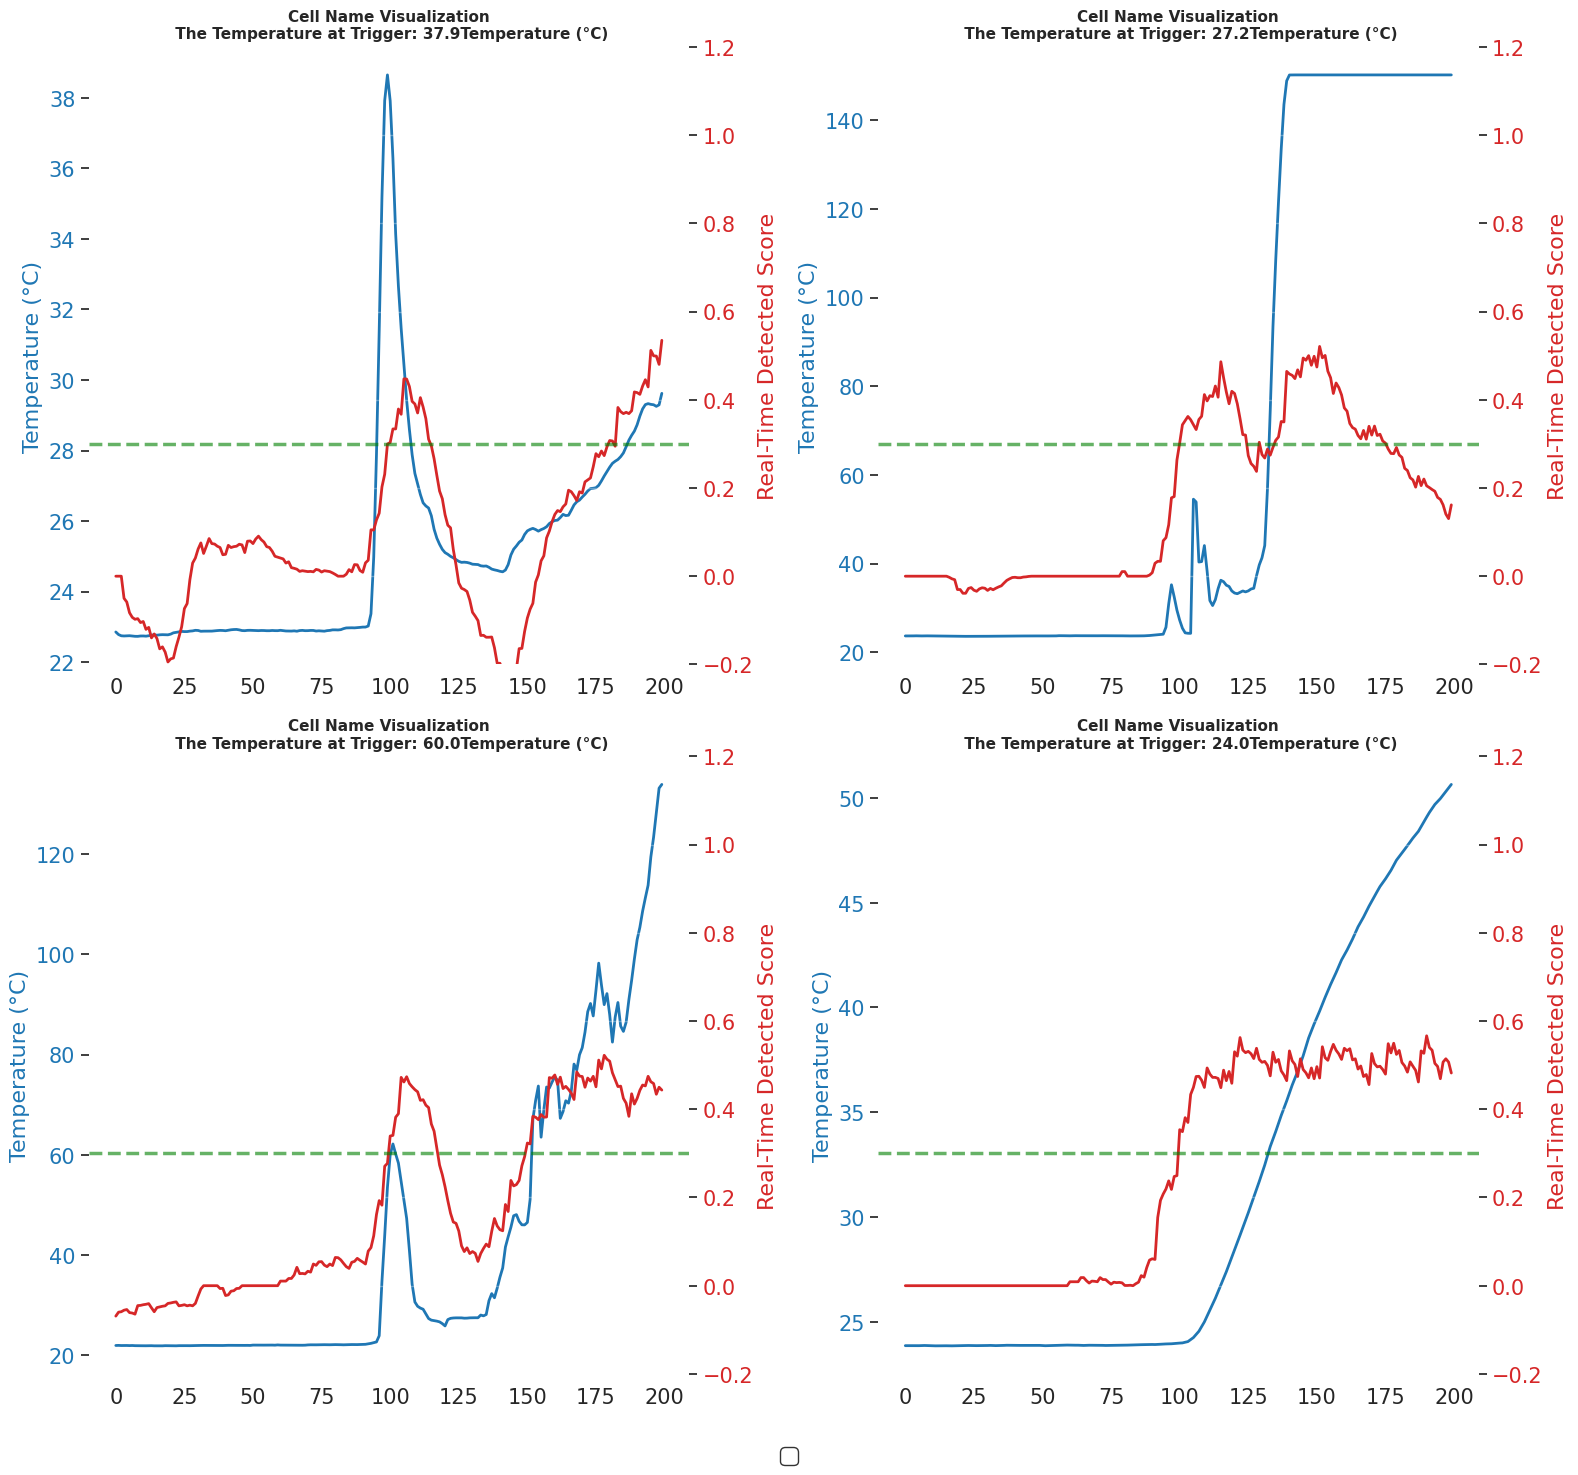

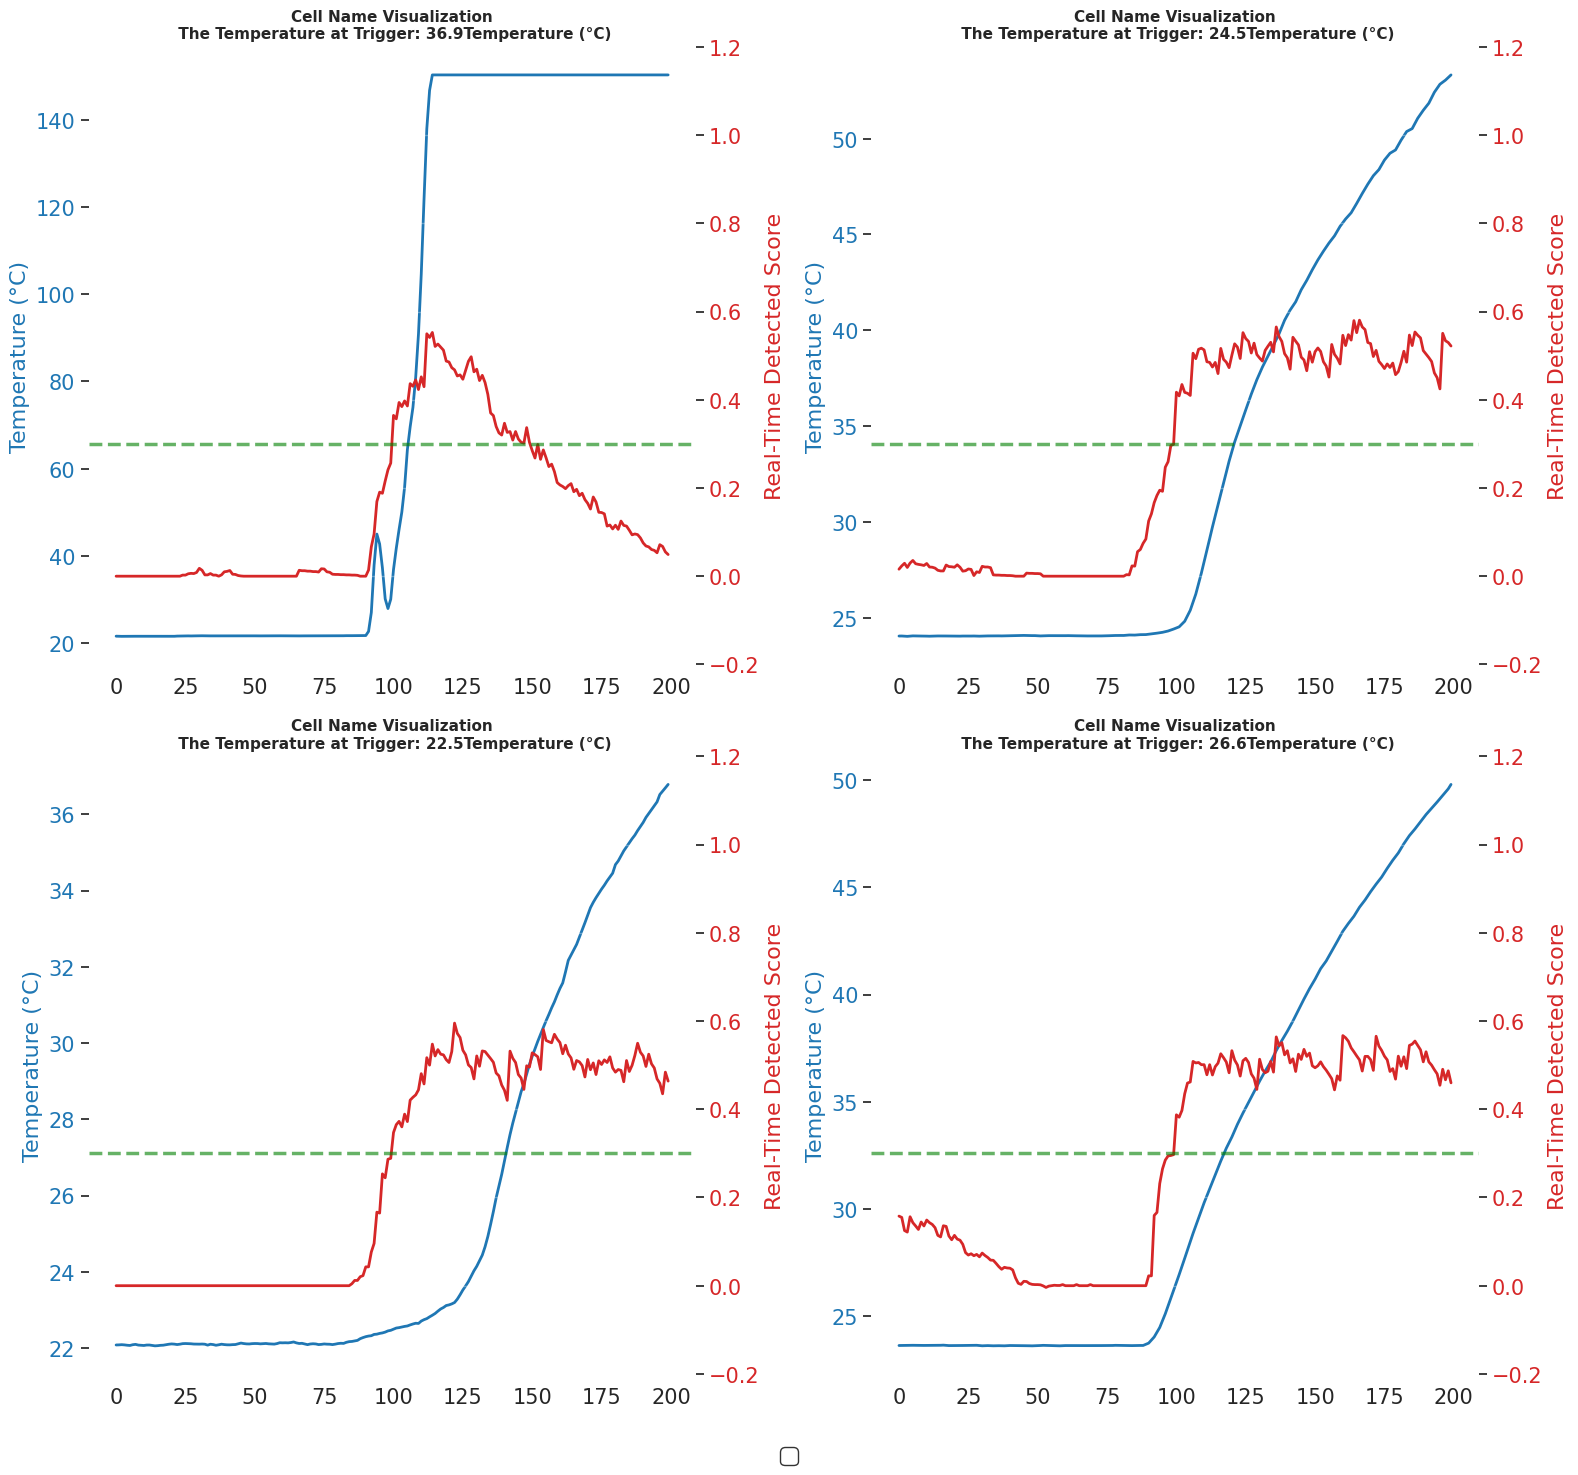

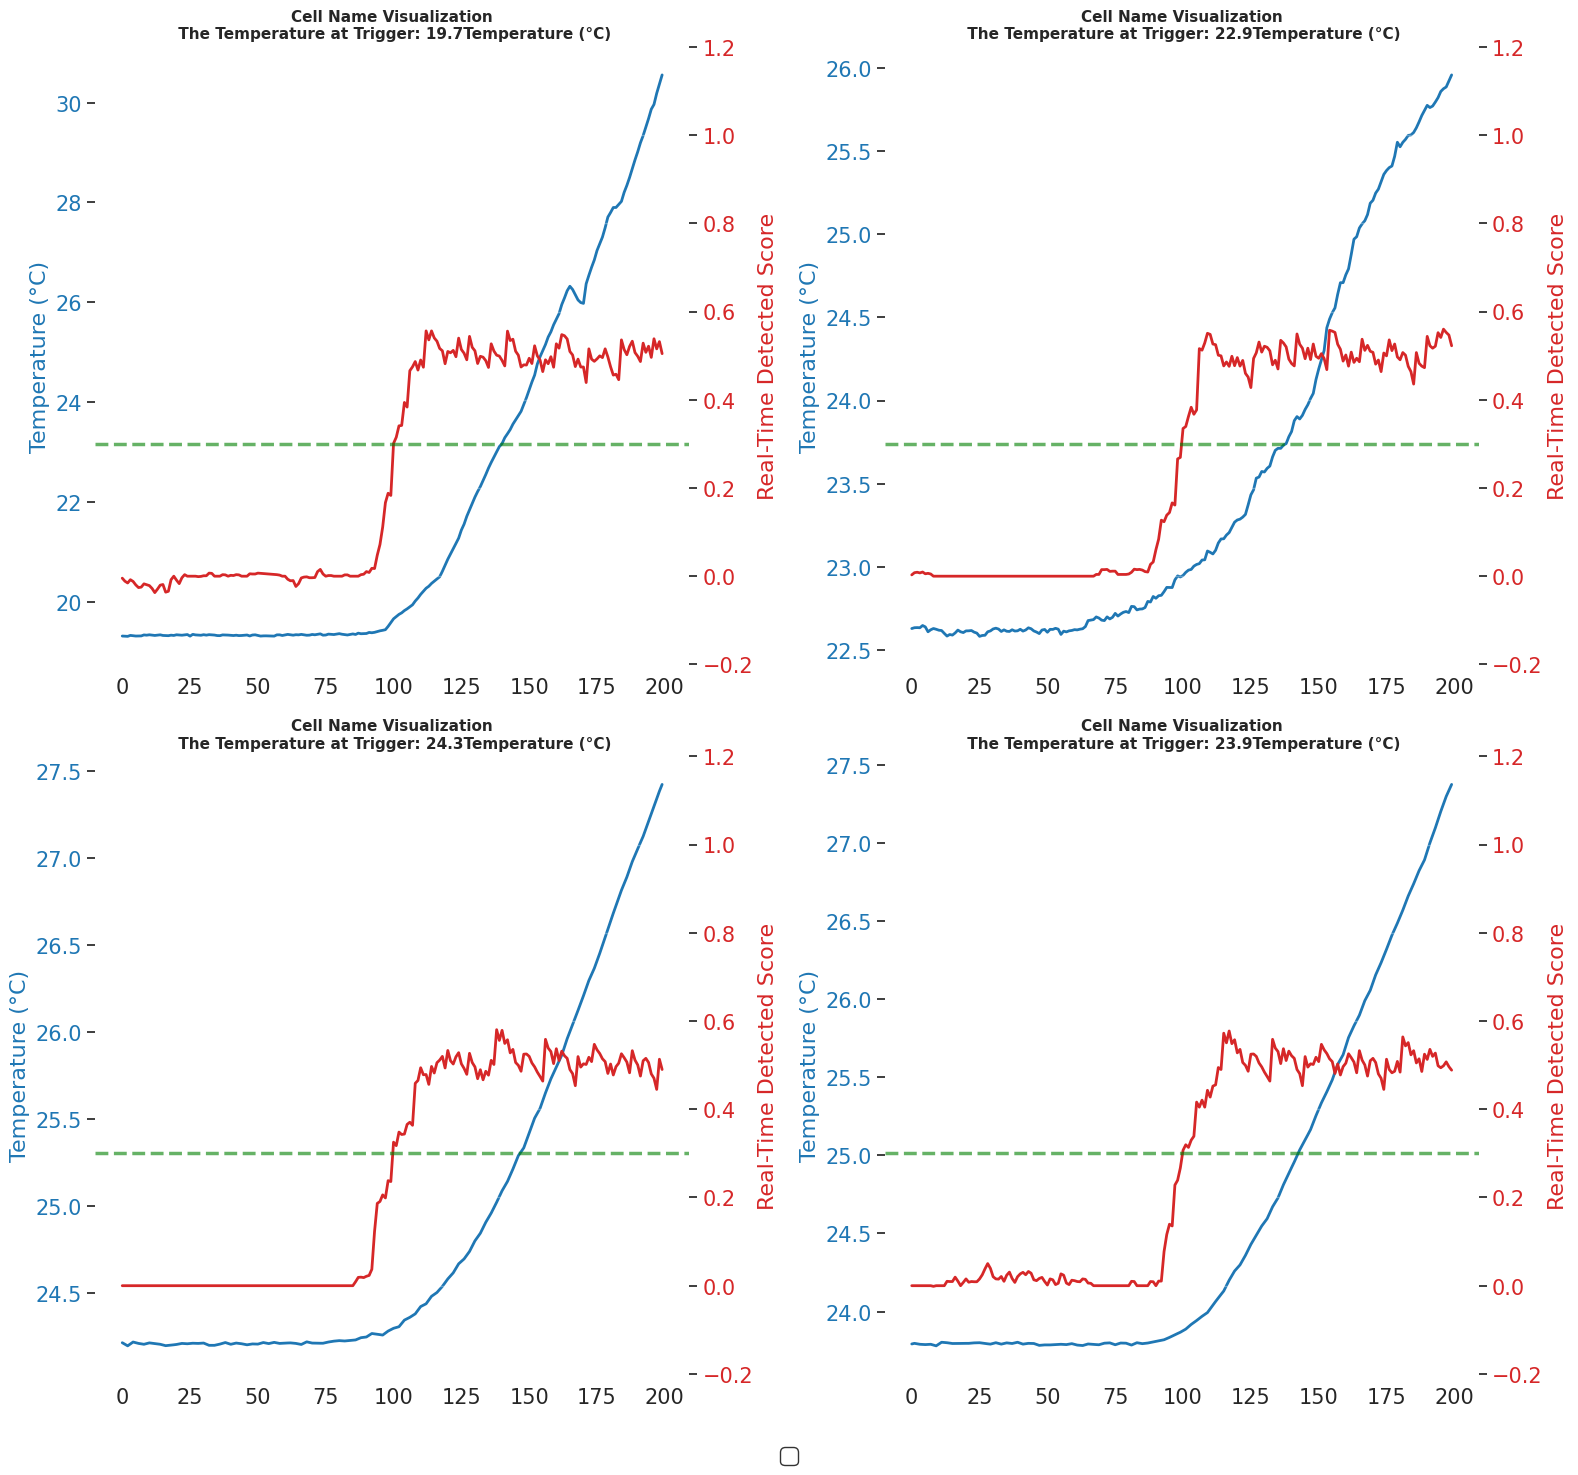

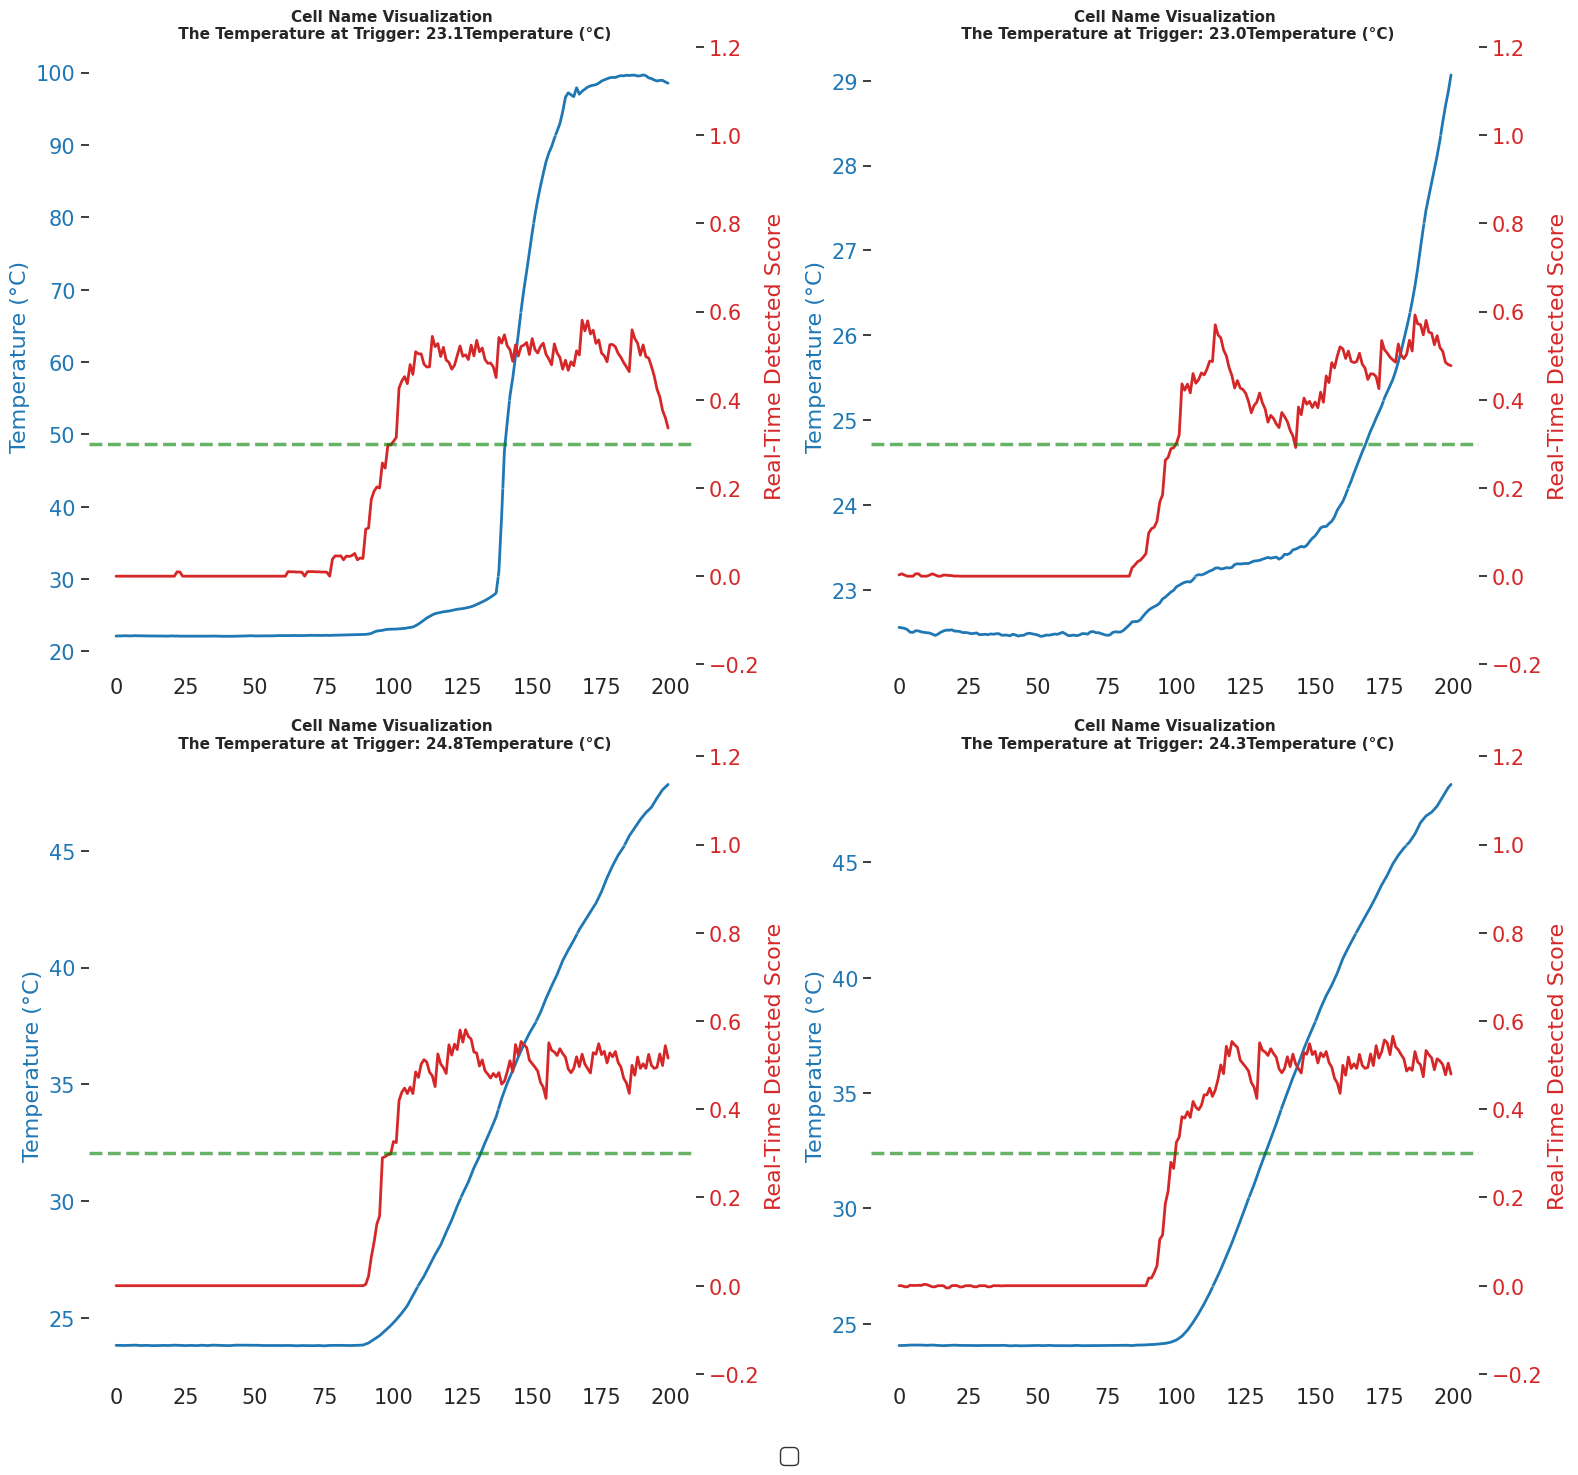

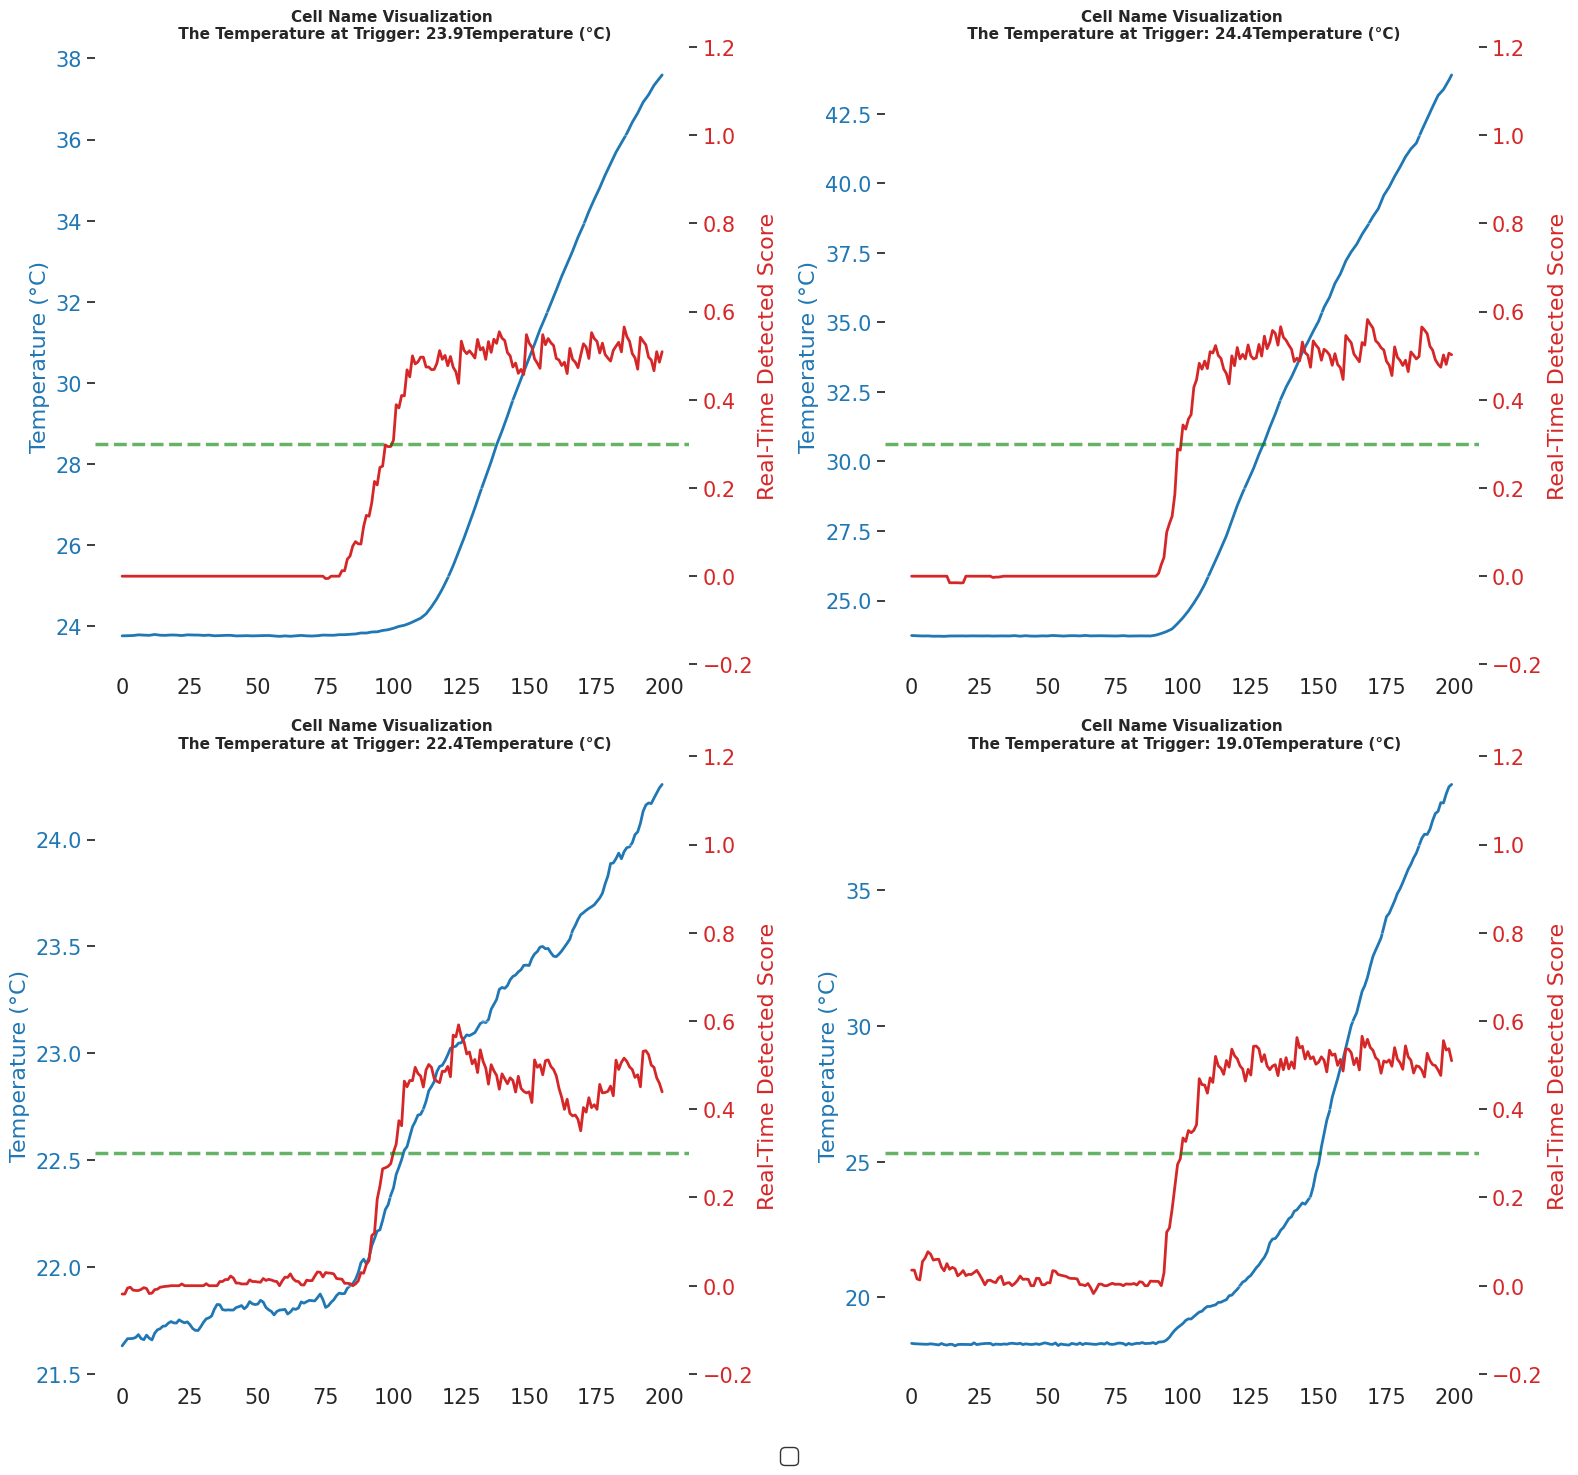

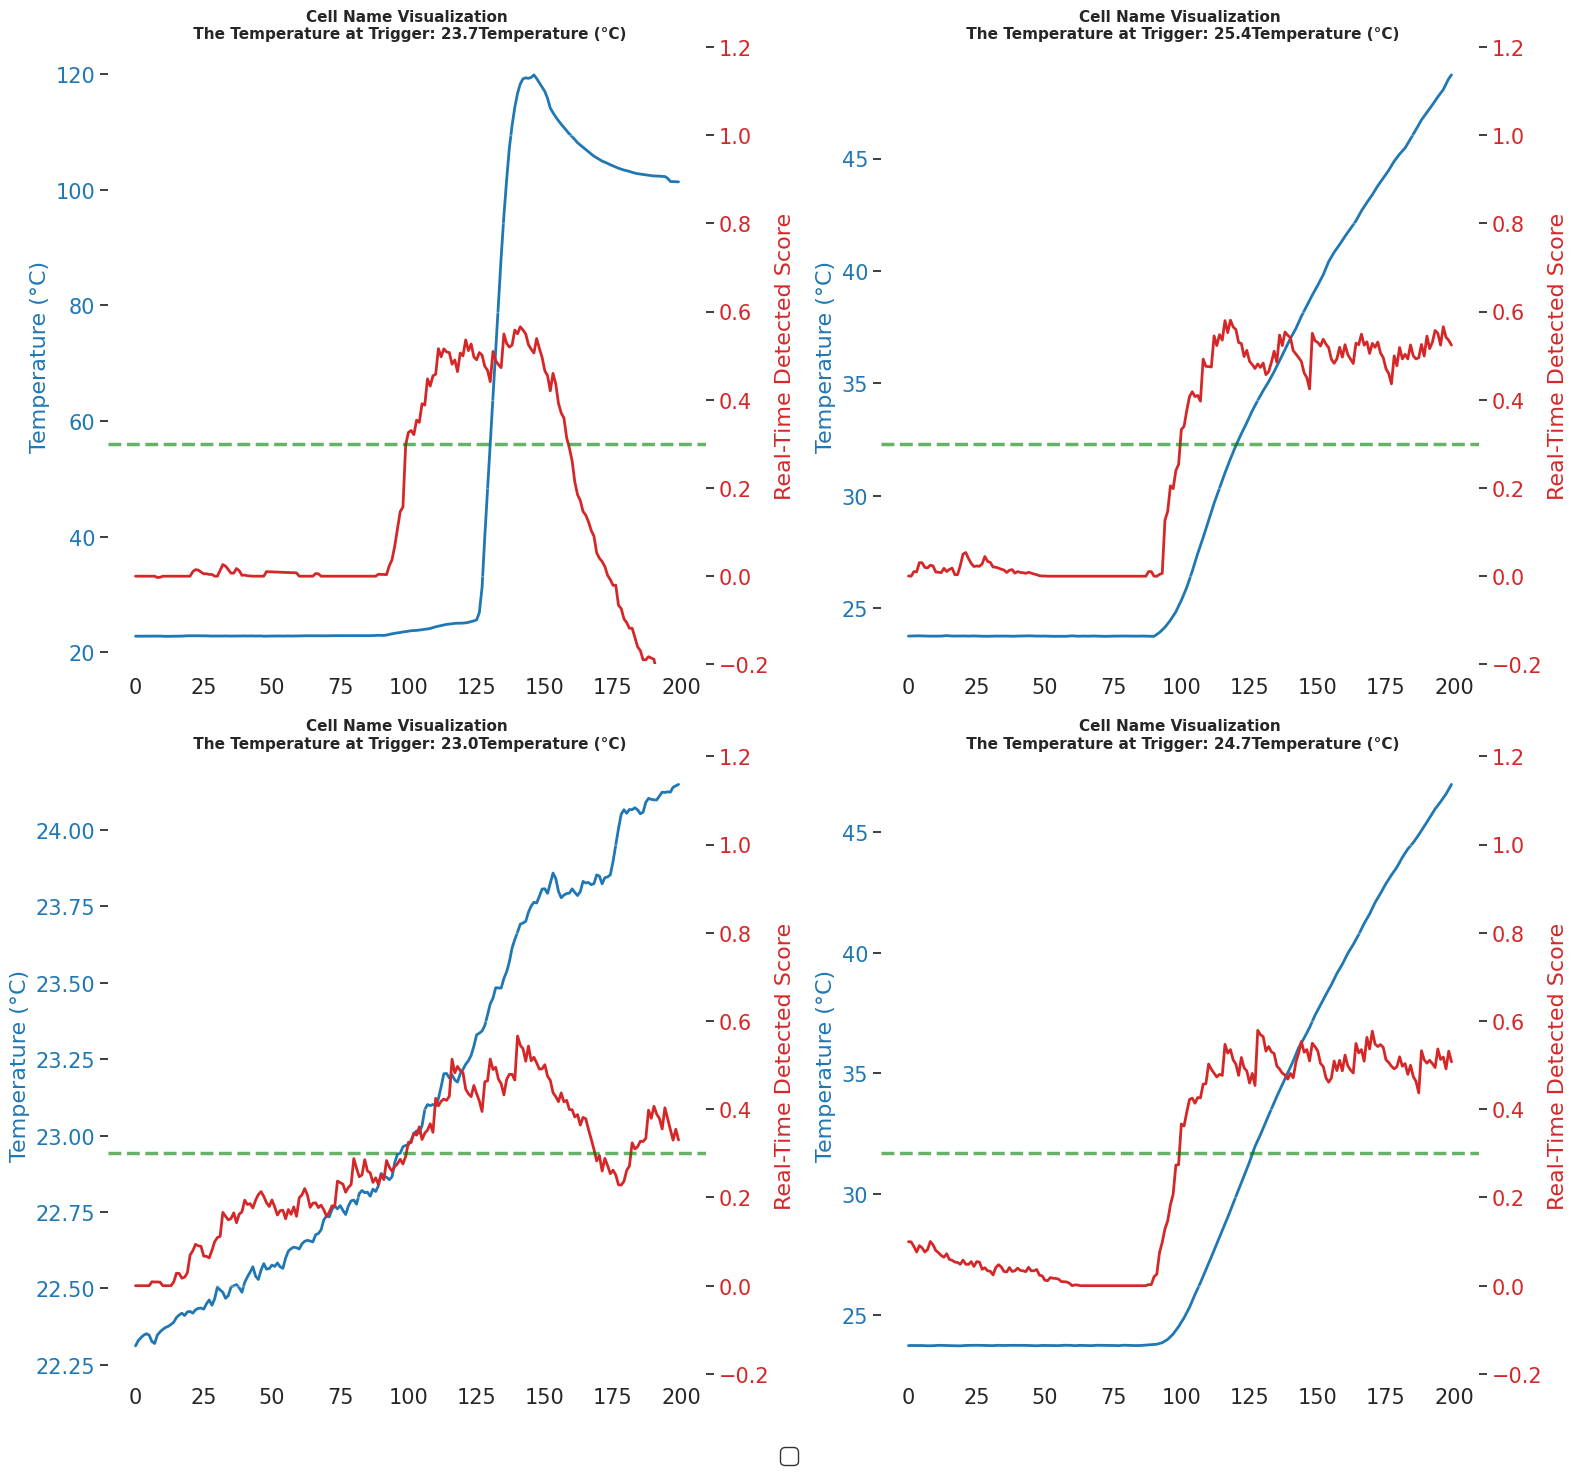

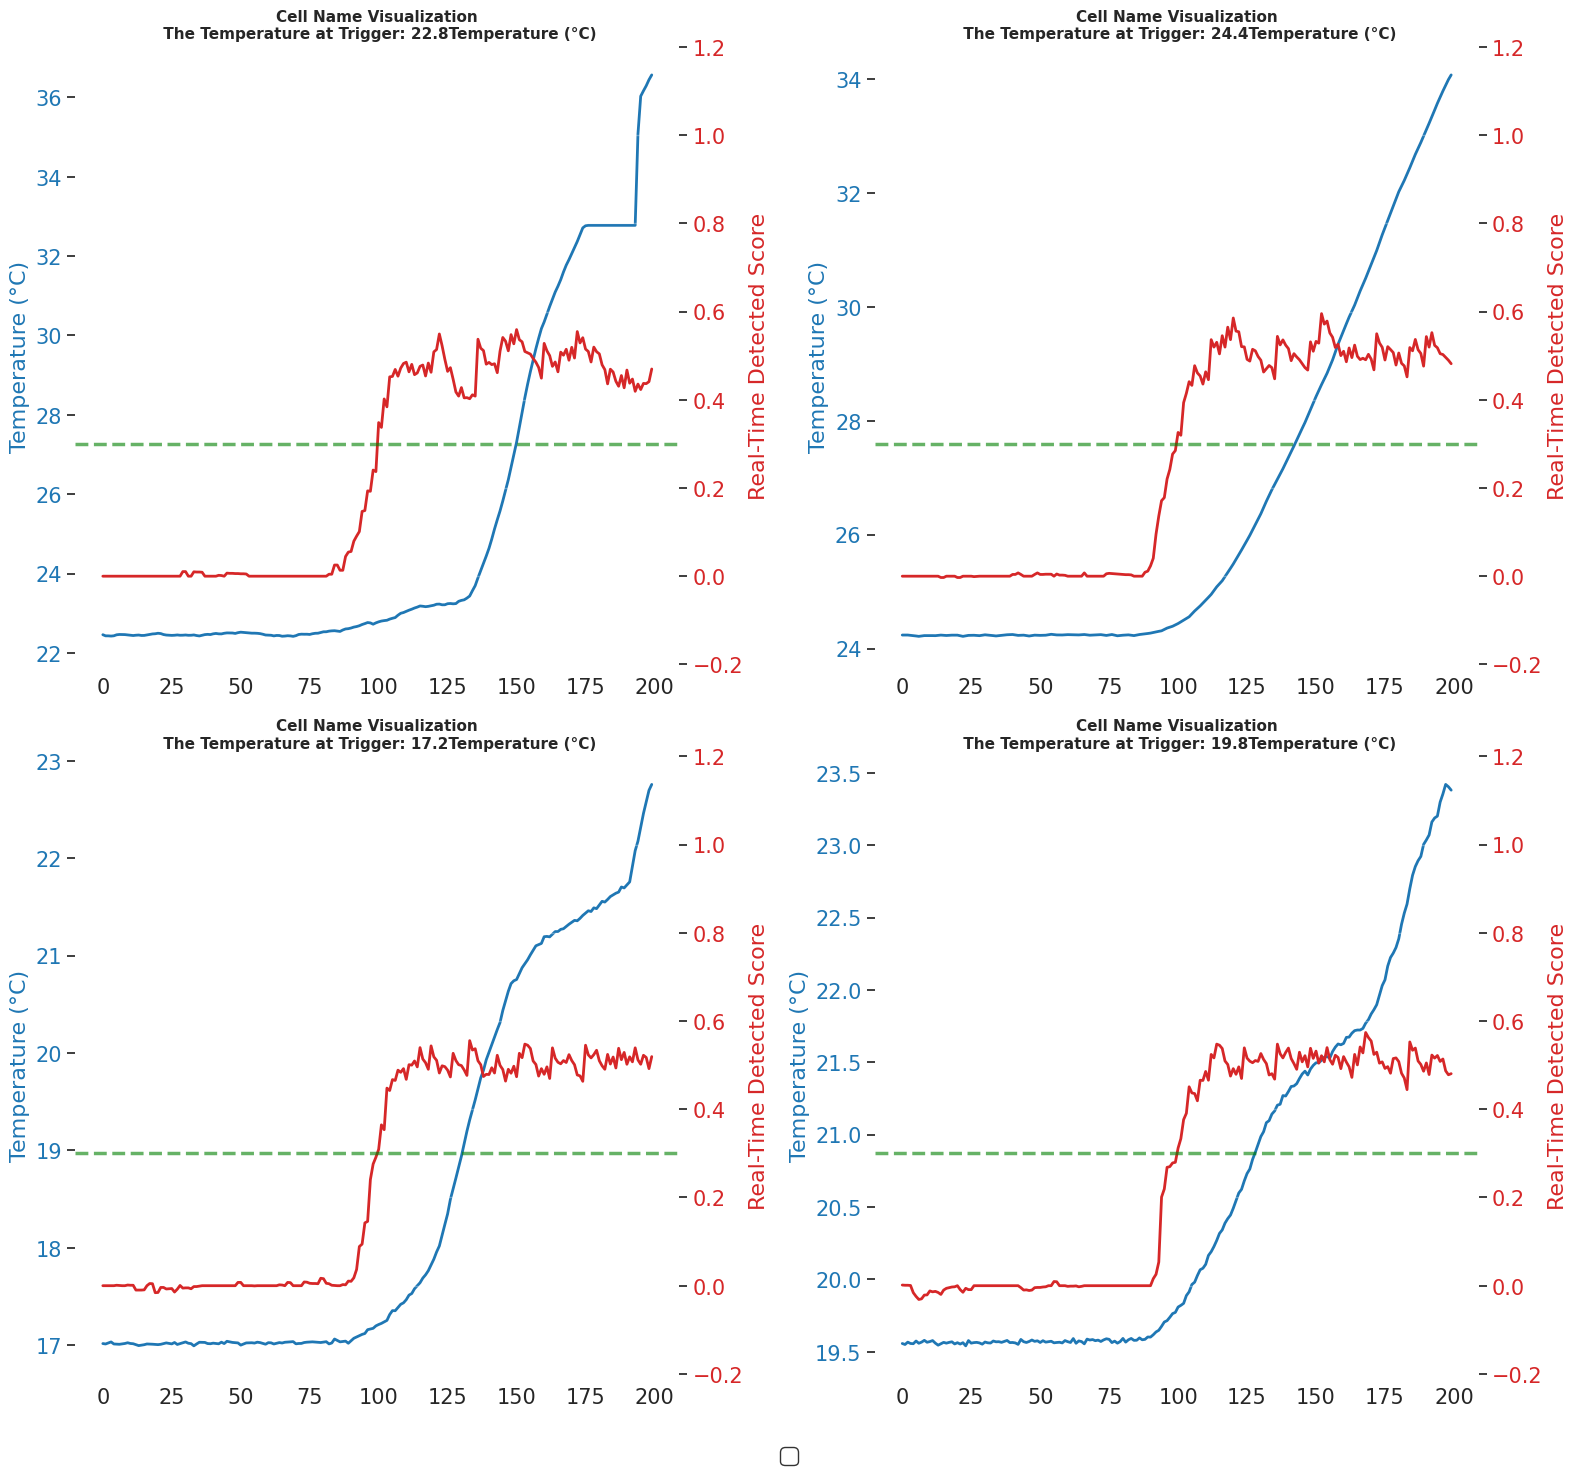

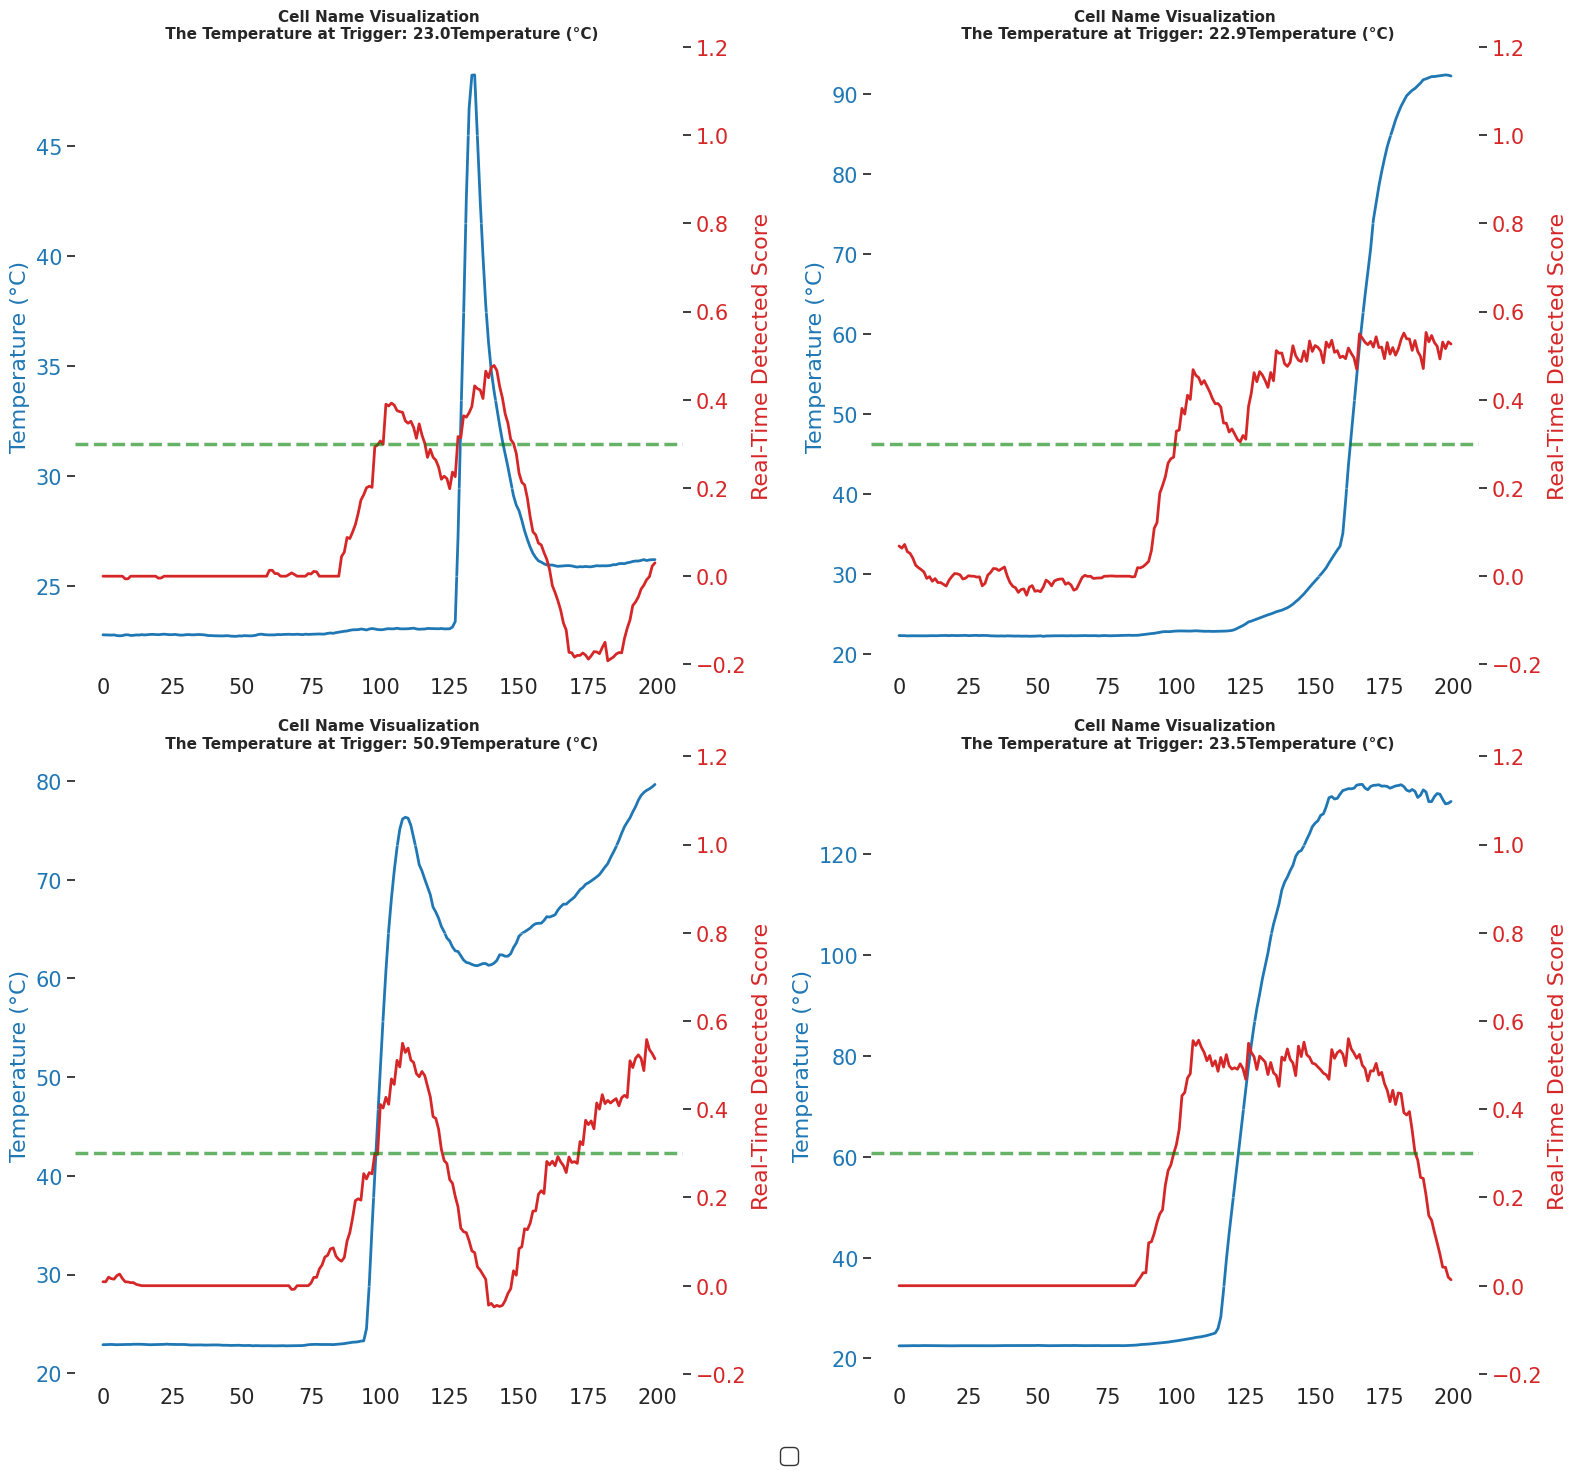

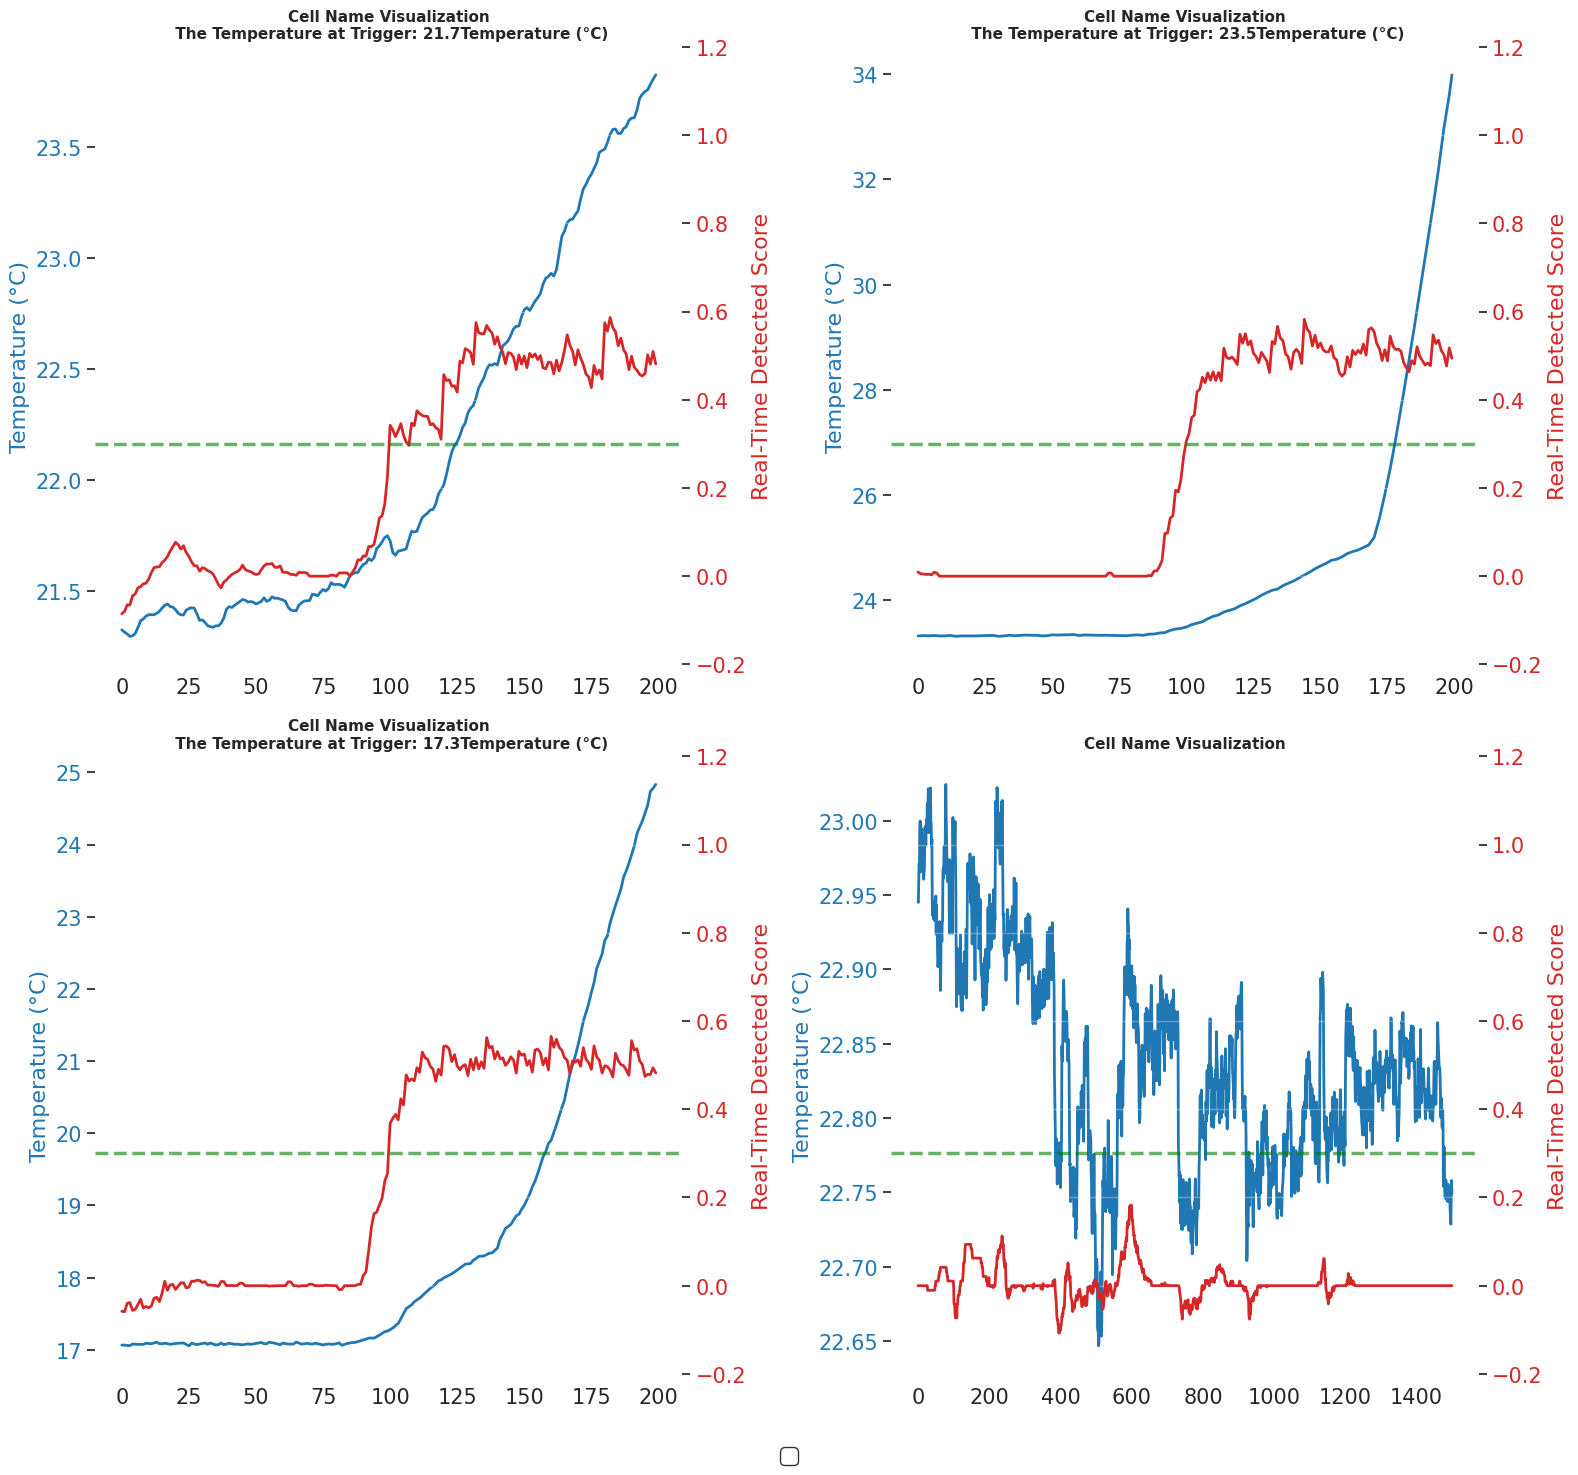

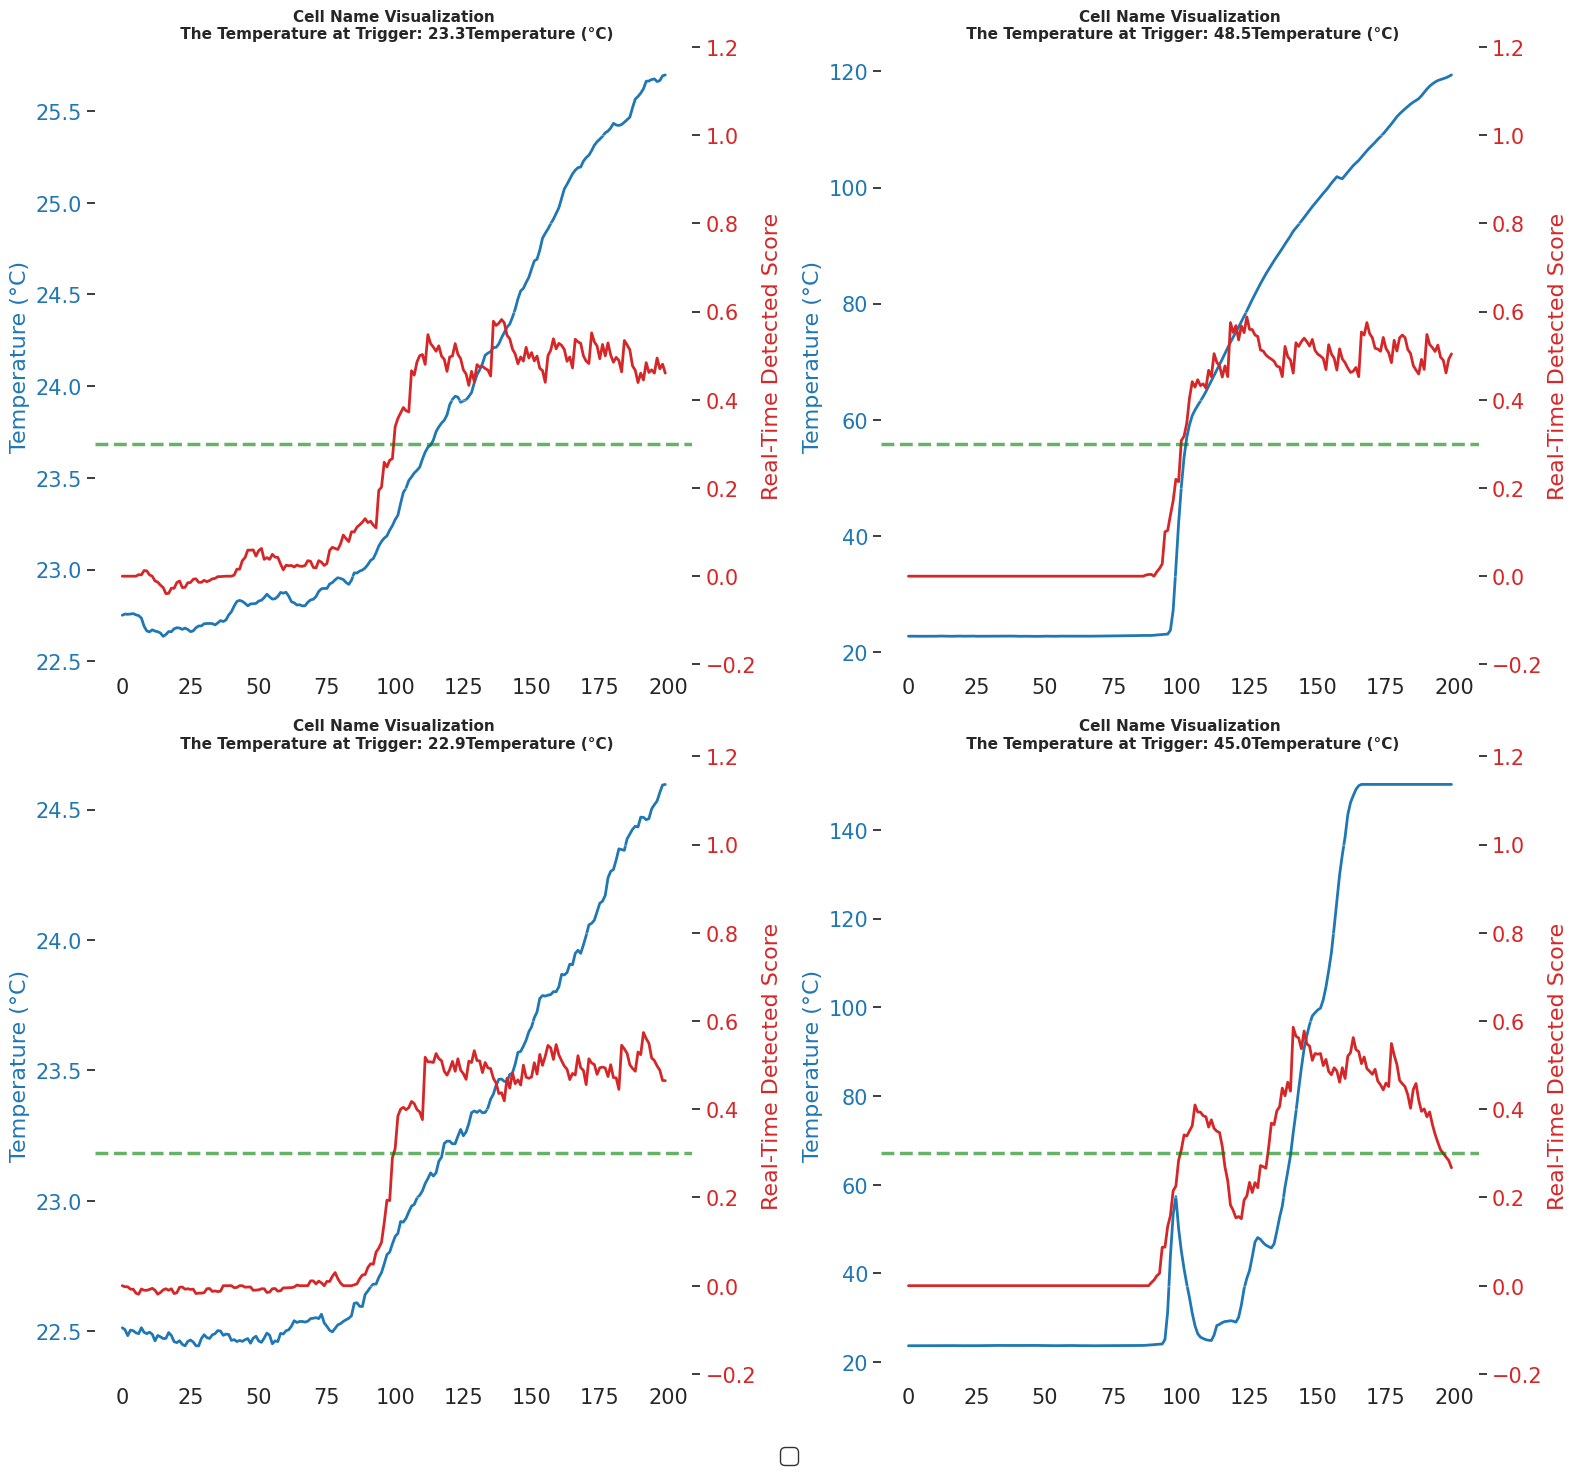

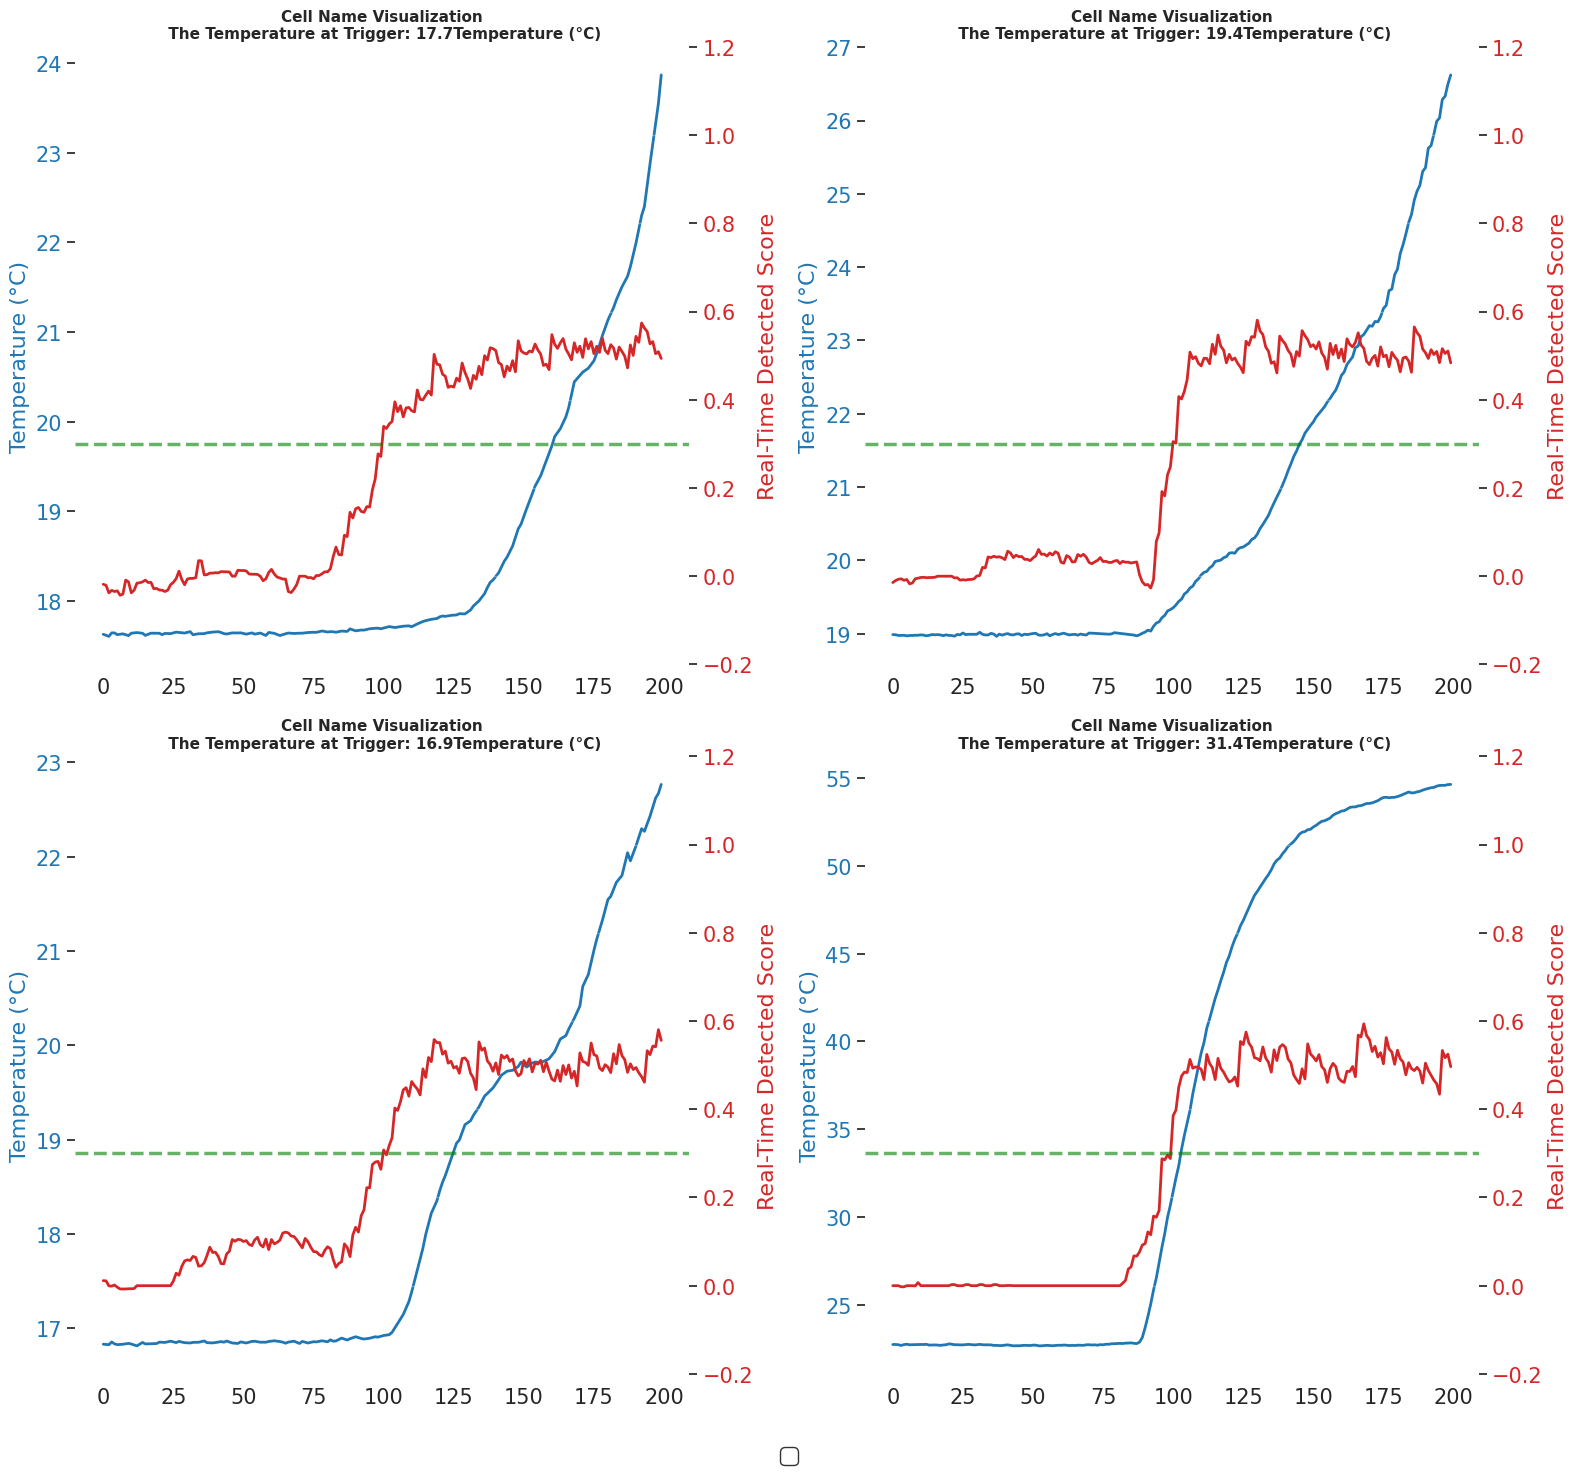

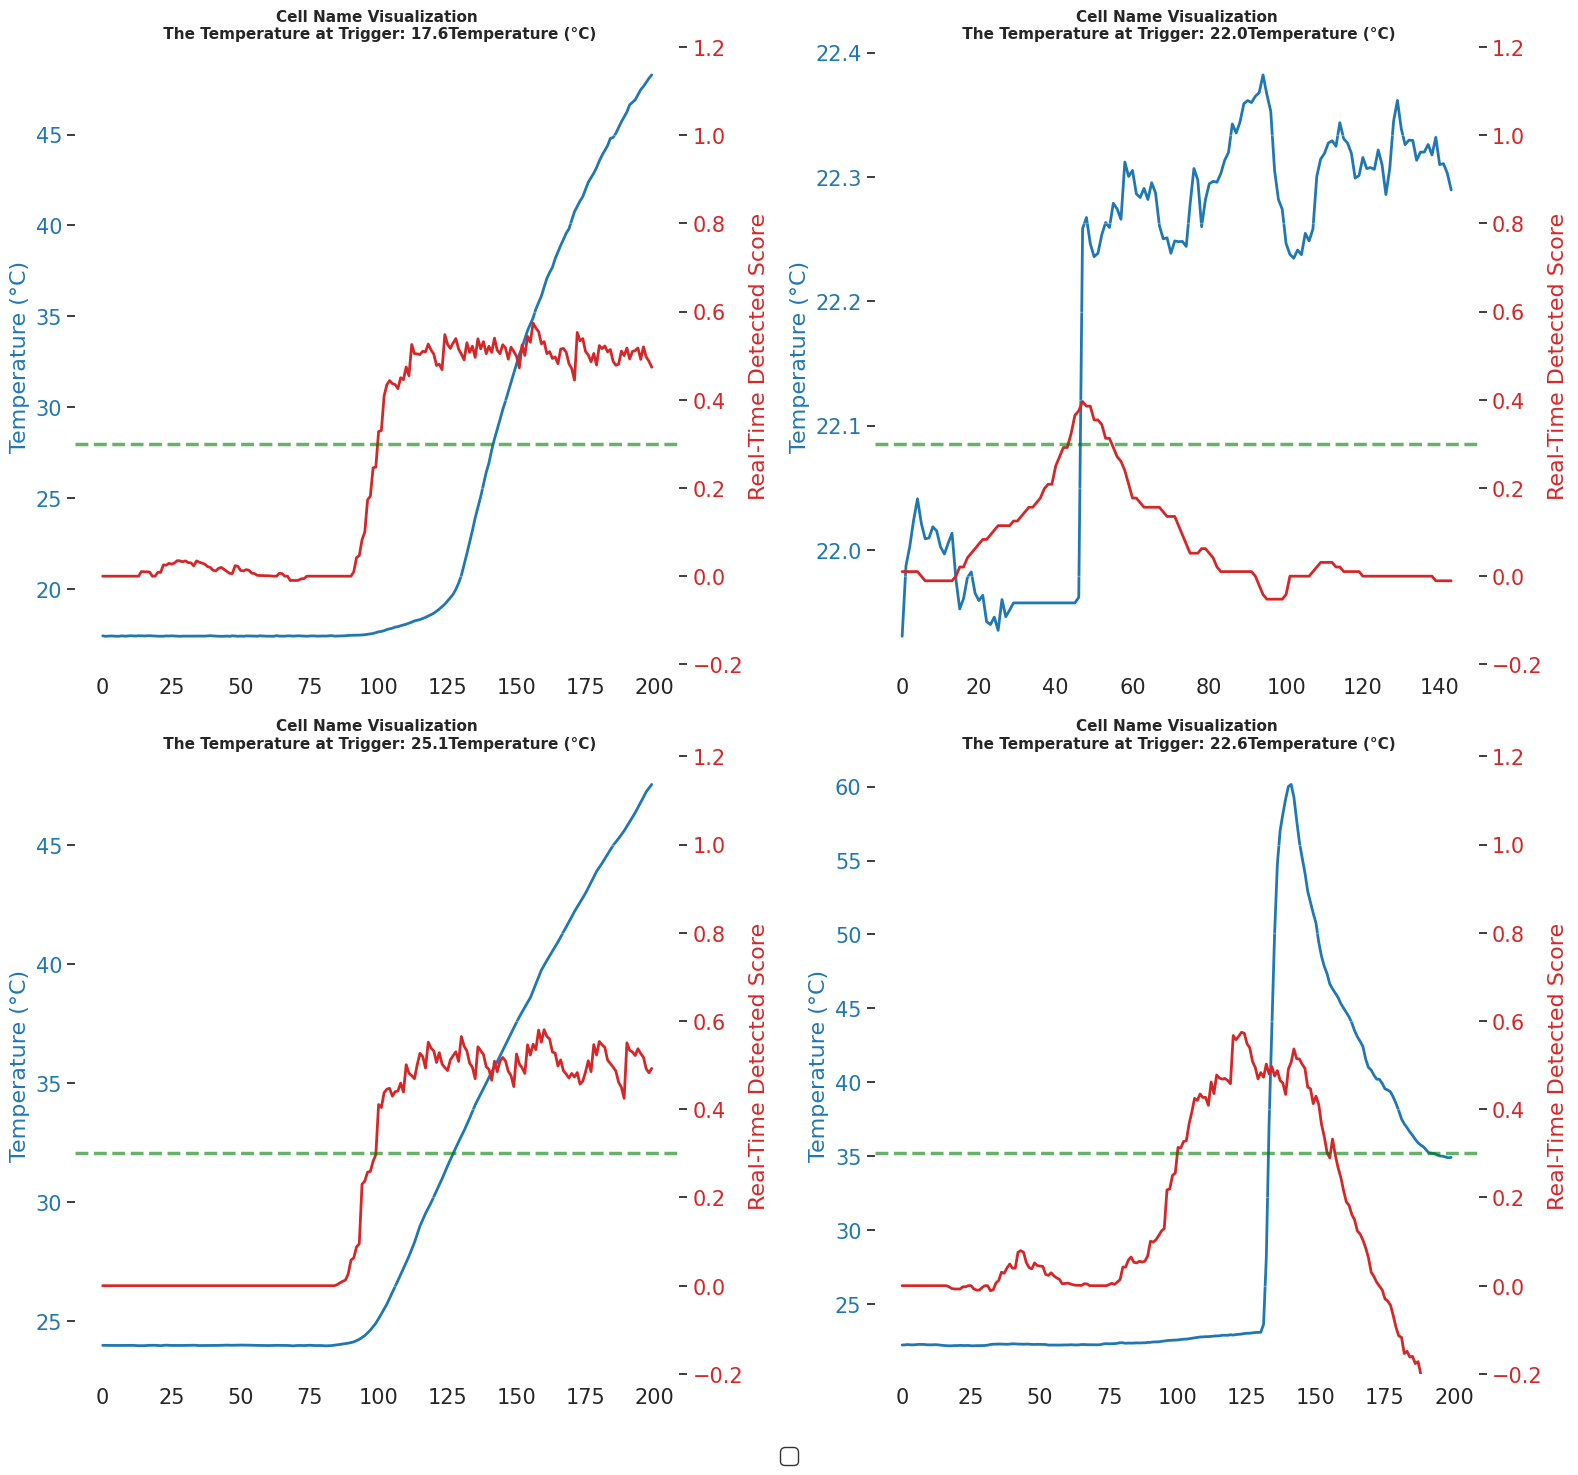

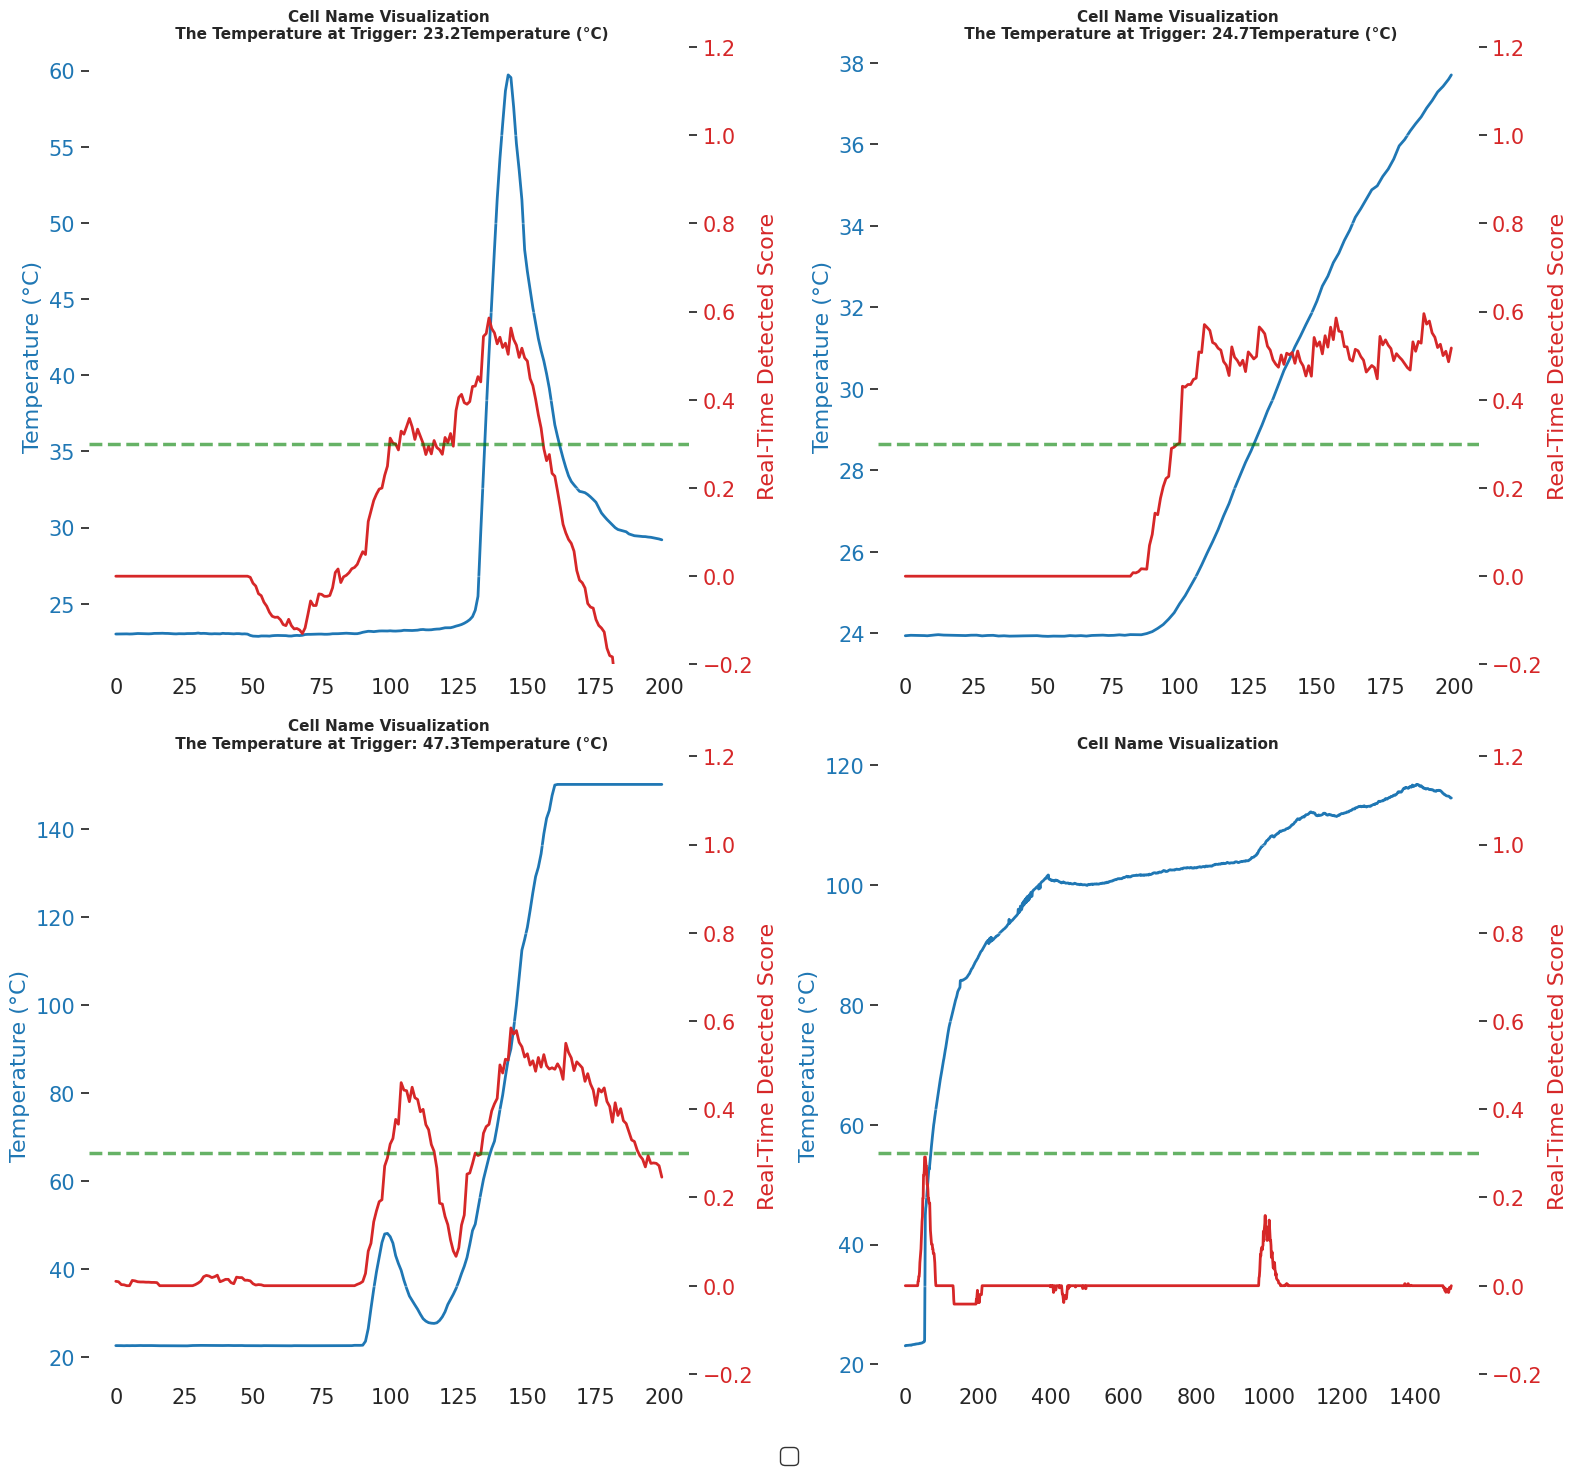

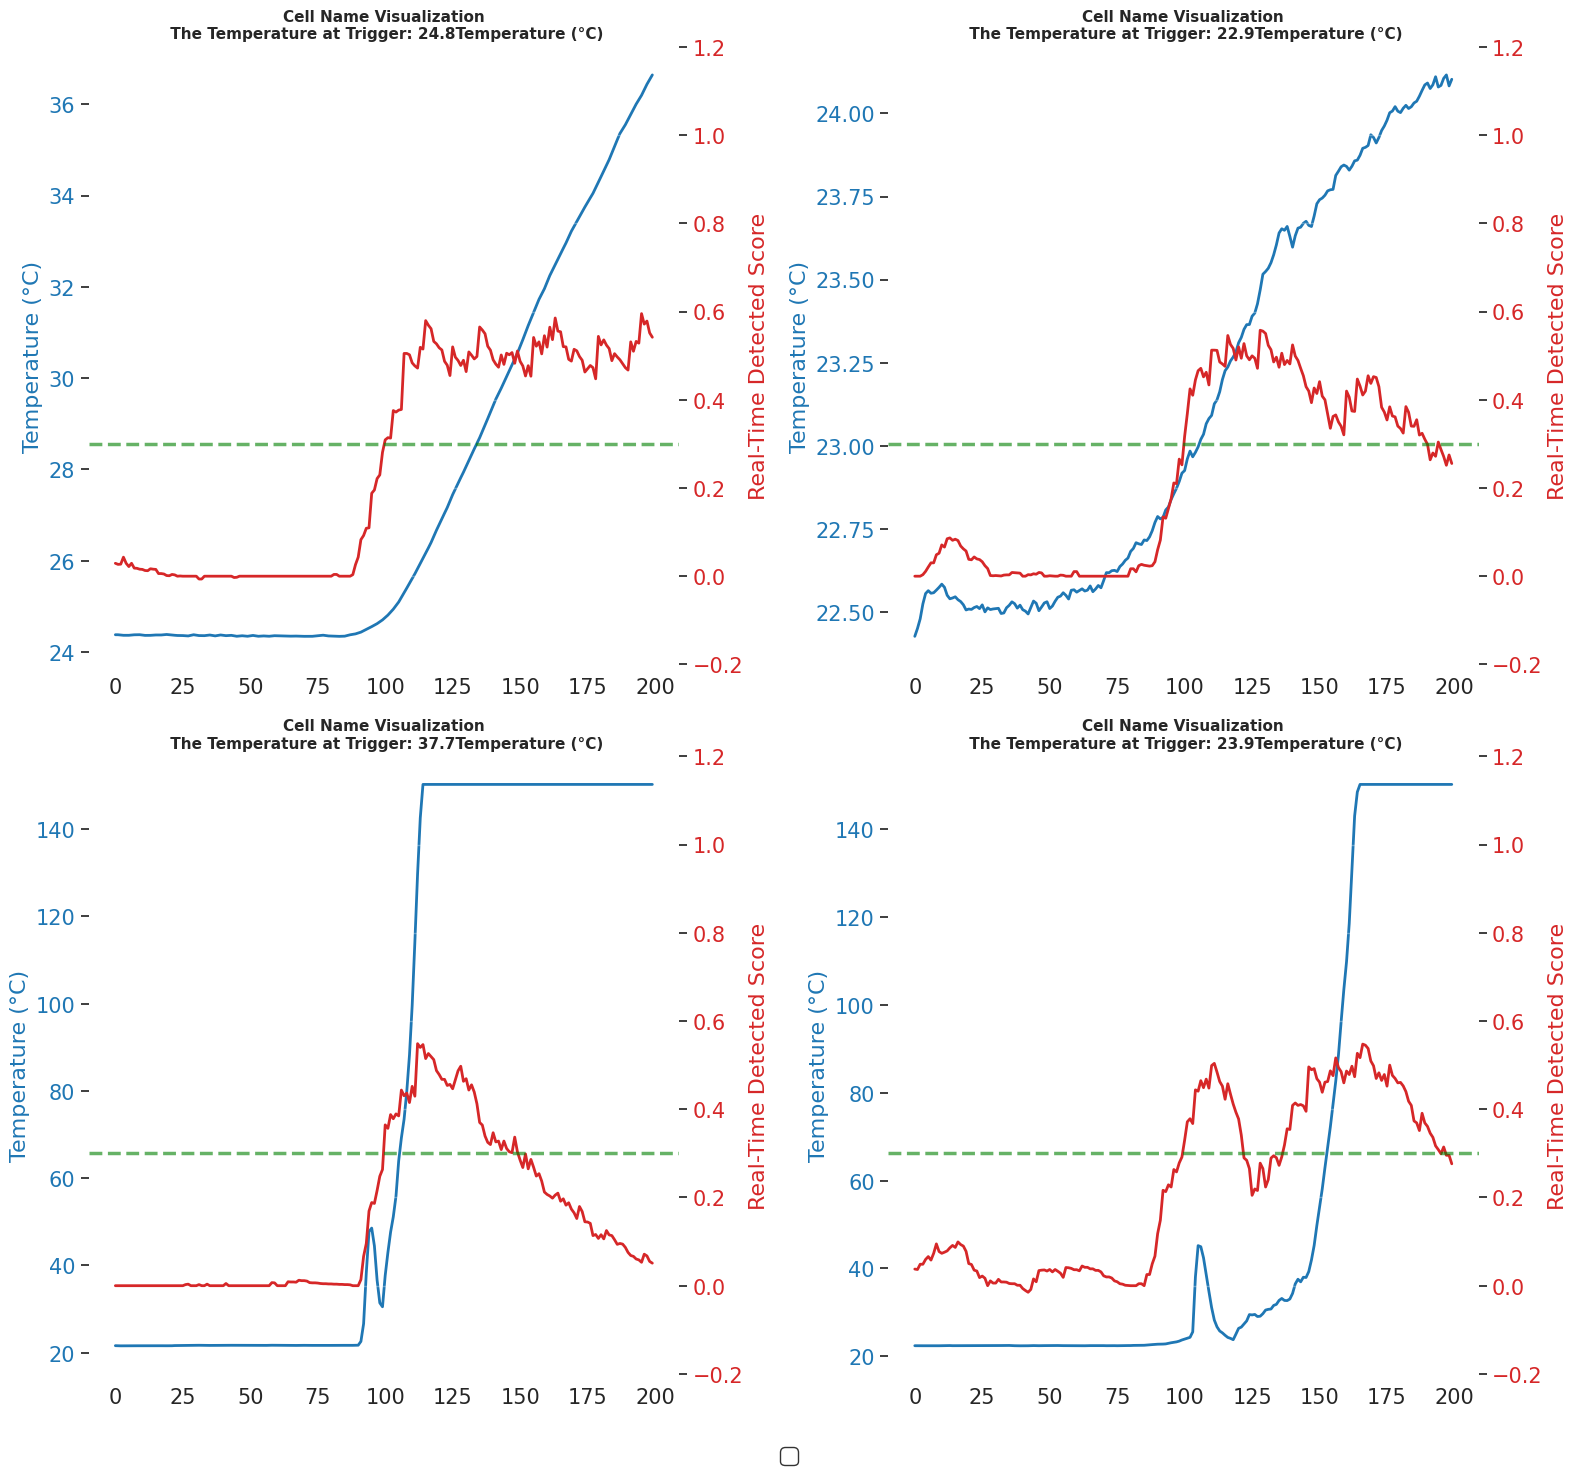

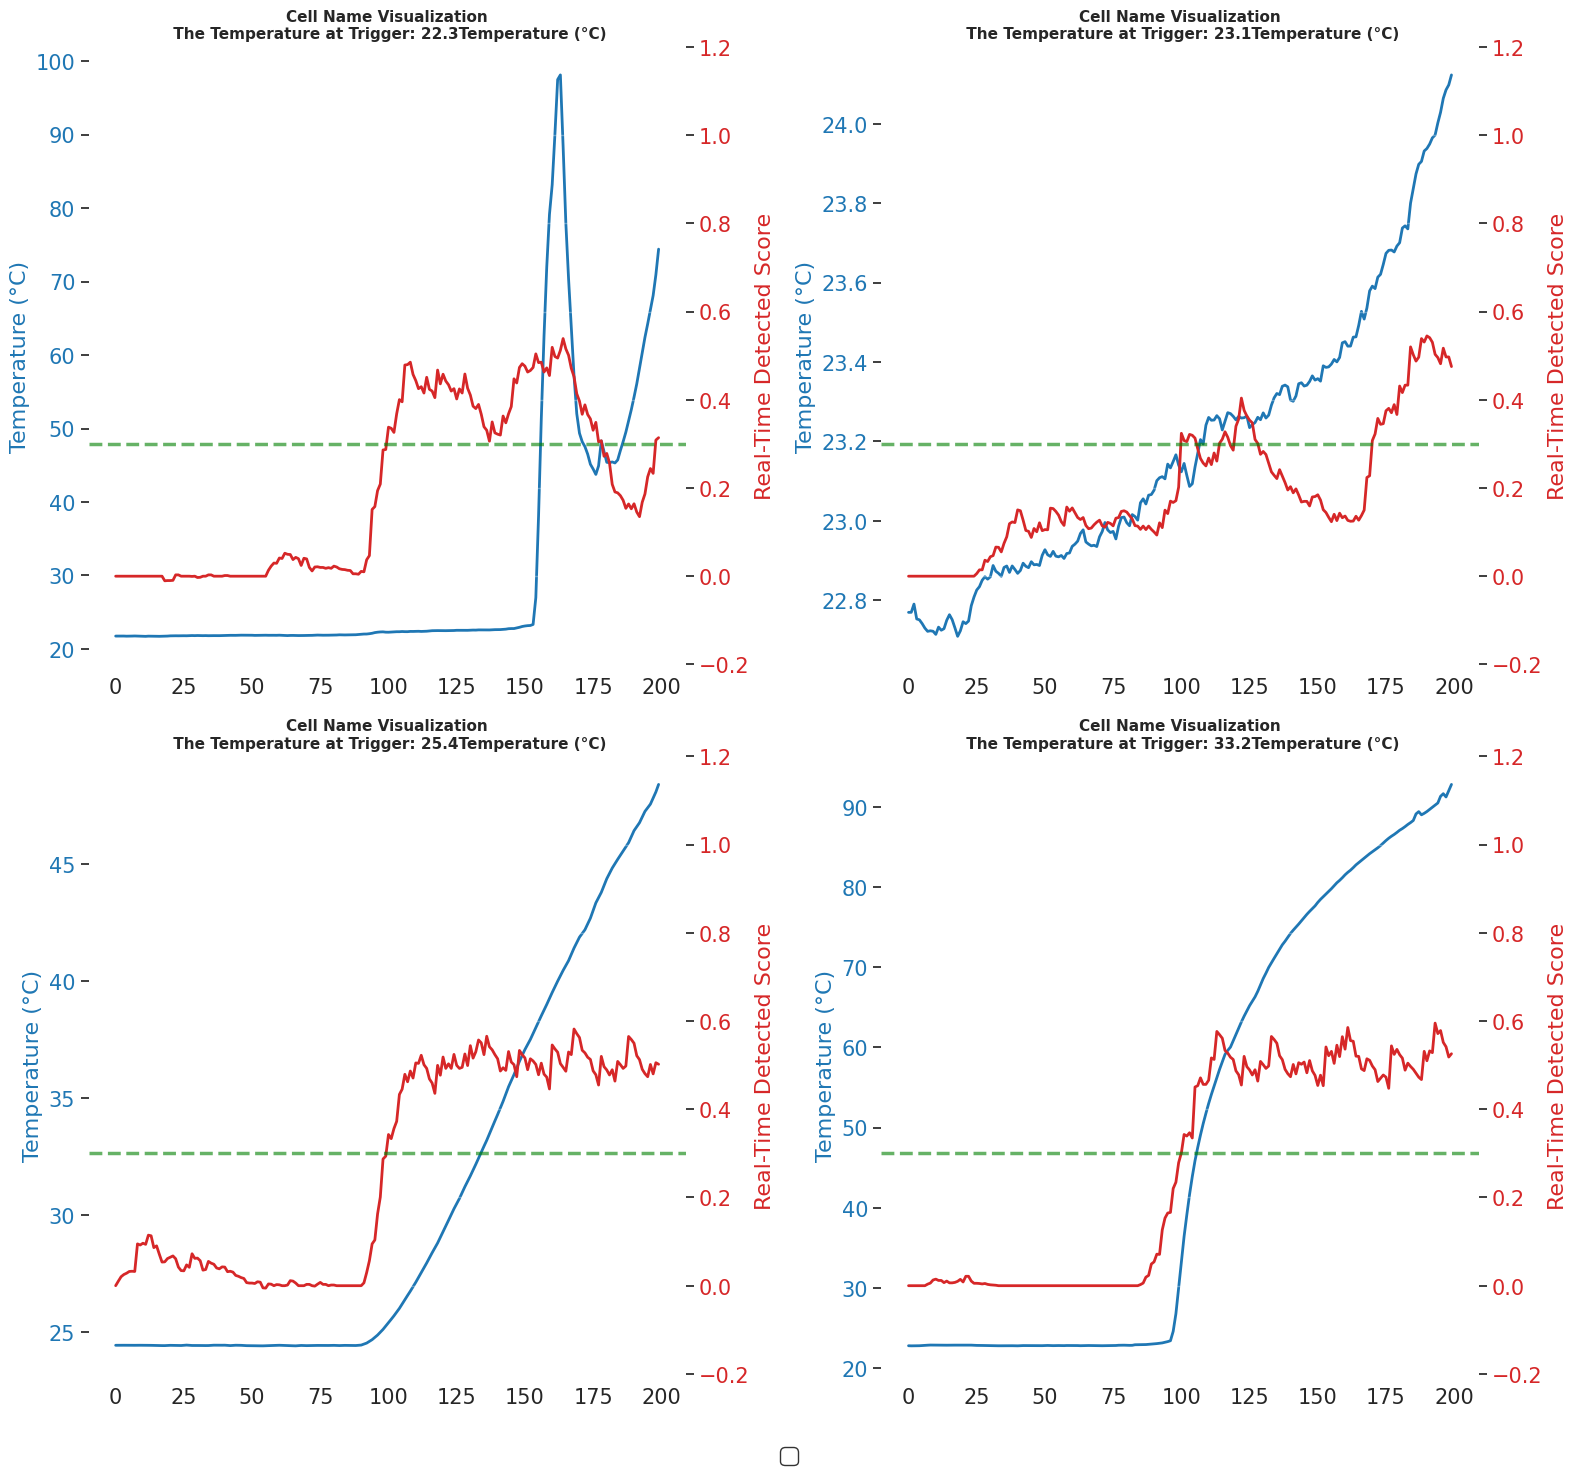

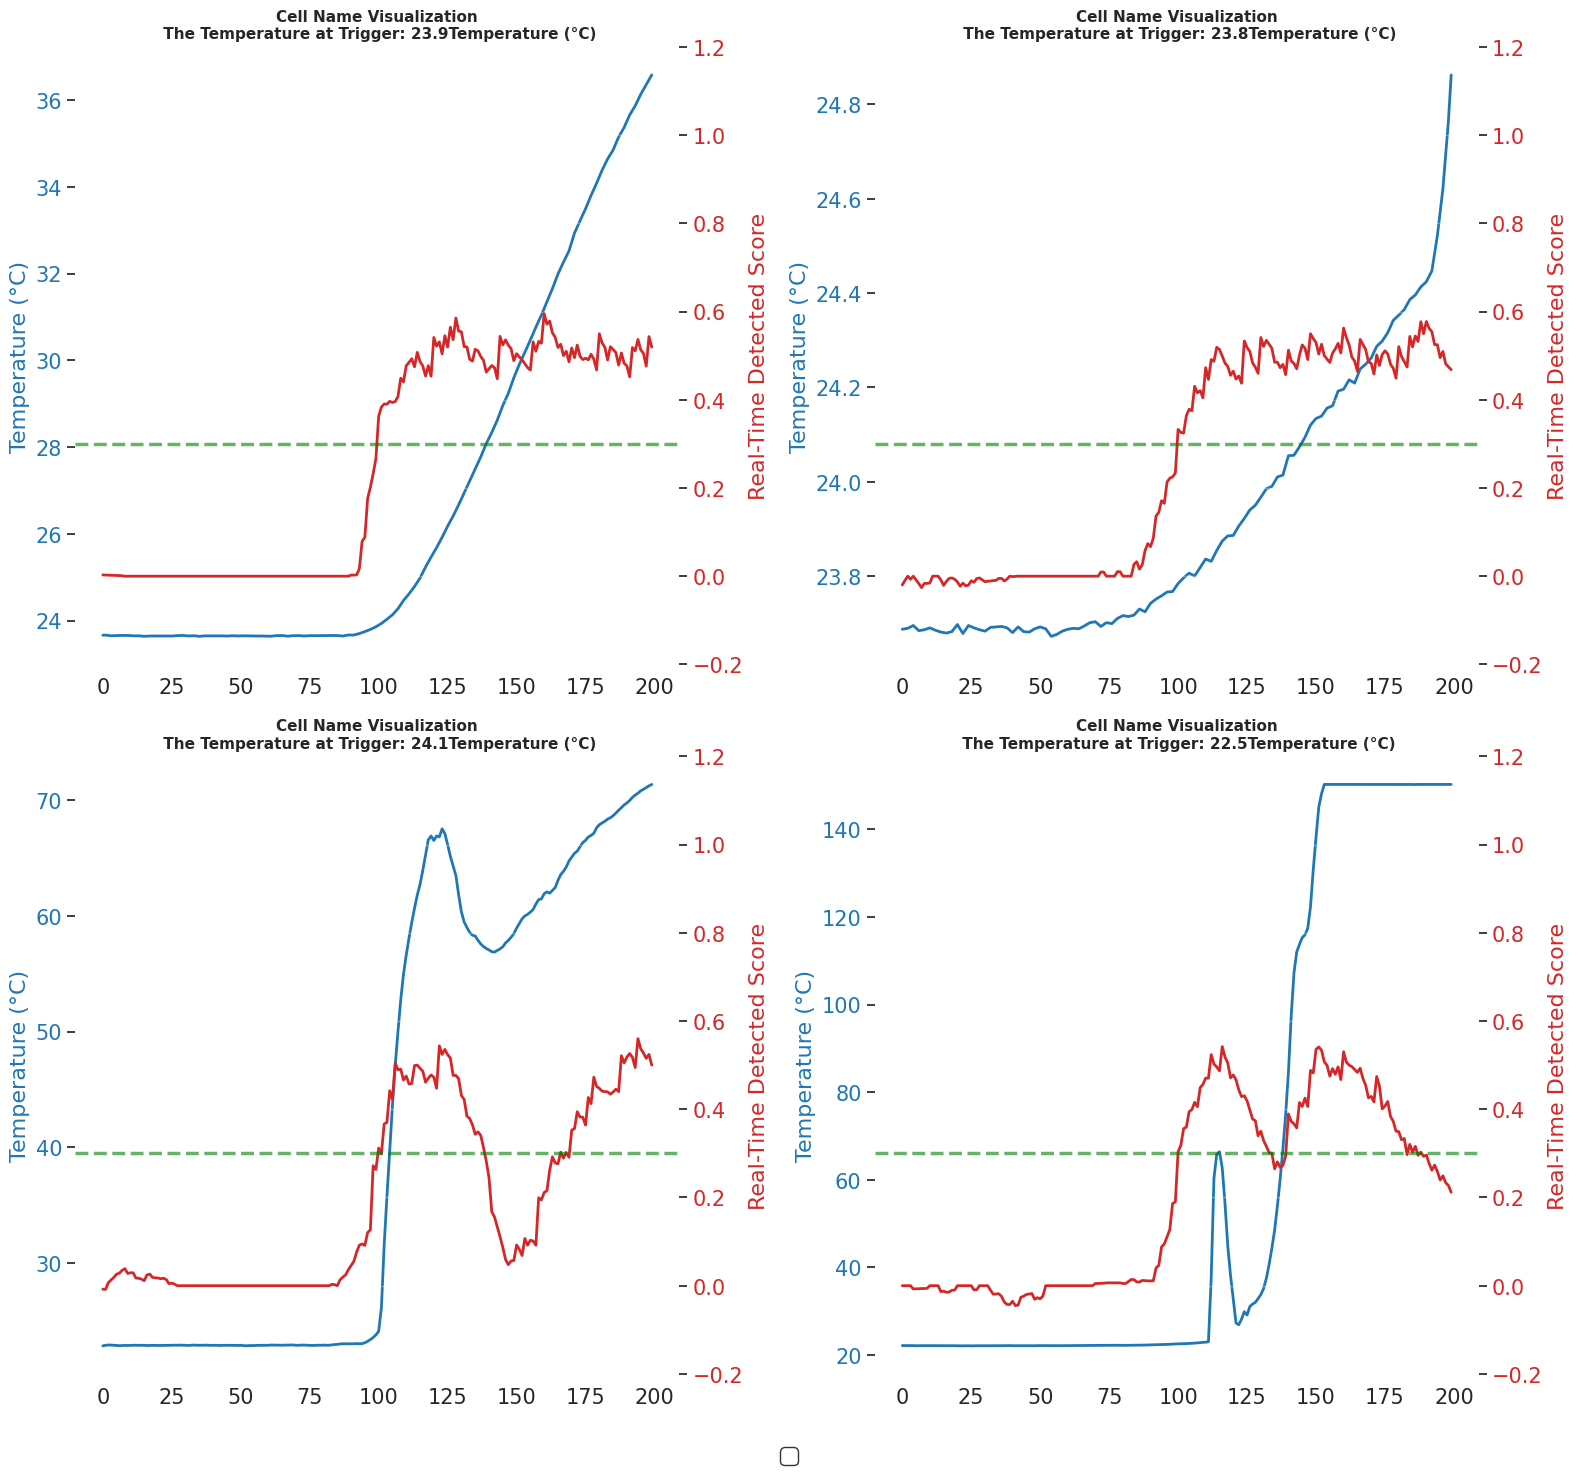

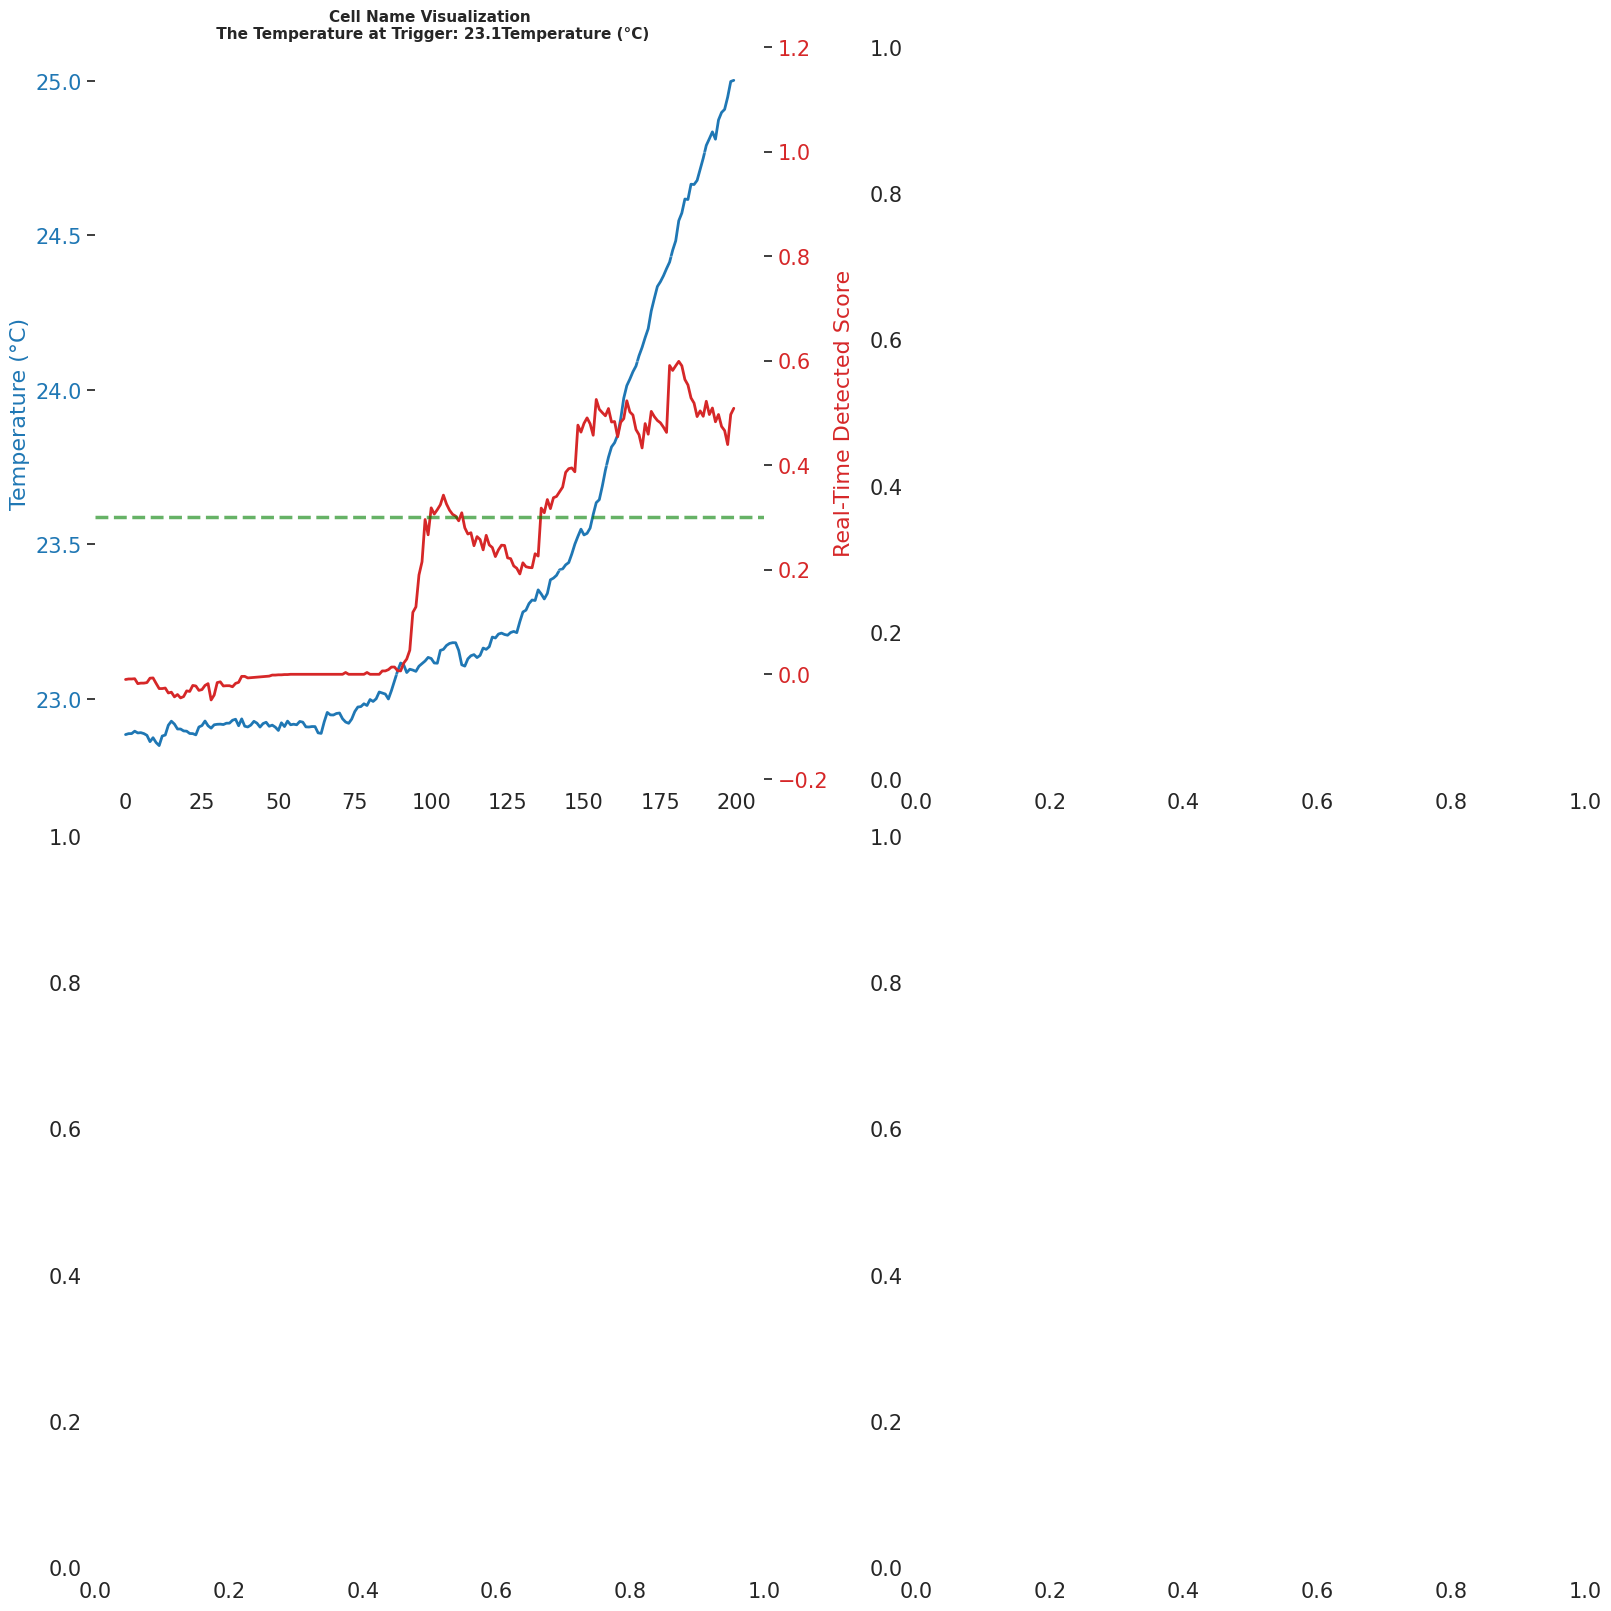

In [ ]:
folder_path = 'NREL_Data_Results'
valid_extensions = ('.csv')
if not os.path.exists("NREL_Plots"):
    os.mkdir("NREL_Plots")
step_size = 4
list_files = os.listdir(folder_path)
for i in range(0, len(list_files), step_size):
    file_list = list_files[i:(i + step_size)]
    file_list = [folder_path + "/" + file for file in file_list]
    plot_battery_quad_T(file_list, threshold = 0.3, point_before = 100, point_after = 100,
                      output_name = f'cell{i}_cell{i+step_size}_T_result_visualization_NREL.png')


In [ ]:
#draw for all of the plots:
import zipfile
with zipfile.ZipFile('SVD_Results_Whole.zip', 'r') as zip_ref:
     zip_ref.extractall('NREL_Data_Results_SVD')

In [ ]:
#Visualize the 2 * 2 plots for the SVD Procedure
def plot_battery_quad_SVD(file_list, threshold = 0.3, point_before = 100, point_after = 100,
                      output_name = 'cell1_name_list.png'):
    apply_standard_style()
    fig, axes = plt.subplots(2, 2, figsize = (16, 16))
    axes_flat = axes.flatten()
    for i, filename in enumerate(file_list):
        ax = axes_flat[i]
        df = pd.read_csv(filename)
        trigger_indices = df.index[df['detected_value_rt'] >= threshold].tolist()
        if trigger_indices:
            trigger_point = trigger_indices[0]
            start_idx = max(0, trigger_point - point_before)
            end_idx = min(len(df), trigger_point + point_after)
            df_plot = df.iloc[start_idx:end_idx,:].reset_index(drop = True)
            temp_at_trigger = df.iloc[trigger_point]['signal']
        else:
            df_plot = df.iloc[:min(len(df), 1500)].reset_index(drop = True)
            temp_at_trigger = None
        #draw the two axis:
        ax_score = ax.twinx()
        #Left Column(Blue):
        line_t, = ax.plot(df_plot.index, df_plot['temperature'], color='#003399', lw=3.5, label='Temperature (°C)')
        ax.set_ylabel('Signal(First Singular Value)', color = '#1f77b4')
        ax.tick_params(axis = 'y', labelcolor = '#1f77b4')
        #Right Column(Red):
        line_d, = ax_score.plot(df_plot.index, df_plot['detected_value_rt'], color='#CC0000', lw=2.5, label='Detection Score')
        ax_score.set_ylabel('Real-Time Detected Score', color = '#d62728')
        ax_score.tick_params(axis = 'y', labelcolor = '#d62728')
        ax_score.set_ylim(-0.2, 1.2)
        #The thresholding line:
        line_th = ax_score.axhline(y=threshold, color='darkgreen', ls='--', lw=2, alpha=0.8)
        ax_score.axhline(y = THRESHOLD, color = 'green', ls = '--', alpha = 0.6)
        soc_match = re.search(r'-(\d+)(SOC|SOC)', filename, re.I)
        soc_str = f"{soc_match.group(1)}% SOC" if soc_match else 'Unknown SOC'
        cell_label = os.path.basename(filename).split('-')
        #title_text = f"Cell: {cell_label} | {soc_str}"
        title_text = "Cell Name Visualization"
        if temp_at_trigger:
            title_text += f"\n The First Singular Value at Trigger: Sigma = {temp_at_trigger:.1f}"
        ax.set_title(title_text, fontsize = 11, fontweight = 'bold')
        ax.set_label('Time Indice (0.1s)')
        legend_handles = [line_t, line_d]
    fig.legend(legend_handles, ['Signal(First Singular Value)', 'Real-time Detection Score'],
               loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.02), frameon=True, edgecolor='black')
    #Tight Layout in the Bottom here:
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(output_name, bbox_inches='tight')
    #plt.show()

In [ ]:
def plot_battery_quad_SVD_polished(file_list, threshold=0.3, point_before=200, point_after=200, output_name='polished_quad_plot.png'):
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.spines.left': False,
        'axes.spines.bottom': False
    })
    fig, axes = plt.subplots(2, 2, figsize=(18, 14), facecolor='white')
    axes_flat = axes.flatten()
    legend_info = {}
    for i, filename in enumerate(file_list):
        if i >= 4: break
        ax = axes_flat[i]
        df = pd.read_csv(filename)
        trigger_indices = df.index[df['detected_value_rt'] >= threshold].tolist()
        if trigger_indices:
            trigger_point = trigger_indices[0]
            start_idx = max(0, trigger_point - point_before)
            end_idx = min(len(df), trigger_point + point_after)
            df_plot = df.iloc[start_idx:end_idx,:].reset_index(drop=True)
            temp_at_trigger = df.iloc[trigger_point]['']
        else:
            df_plot = df.iloc[:min(len(df), 2500)].reset_index(drop=True)
            temp_at_trigger = None
        ax_score = ax.twinx()
        line_t, = ax.plot(df_plot.index, df_plot['temperature'], color='#003399', lw=3.5, label='Temperature (°C)')
        line_d, = ax_score.plot(df_plot.index, df_plot['detected_value_rt'], color='#CC0000', lw=2.5, label='Detection Score')
        line_th = ax_score.axhline(y=threshold, color='darkgreen', ls='--', lw=2, alpha=0.8)
        ax.set_ylabel('Temperature (°C)', color='#003399', fontweight='bold', fontsize=12)
        ax.tick_params(axis='y', labelcolor='#003399', length=0)
        ax_score.set_ylabel('Score [0-1]', color='#CC0000', fontweight='bold', fontsize=12)
        ax_score.tick_params(axis='y', labelcolor='#CC0000', length=0)
        ax_score.set_ylim(-0.05, 1.05)
        ax.set_xlabel('Time Indice (0.1s)', fontsize=12)
        ax.tick_params(axis='x', length=0)
        base = os.path.basename(filename)
        cell_name = base.split('.').replace('_reform', '').split('_rt_detect')
        soc_match = re.search(r'(\d+S?0C)', base, re.I)
        soc_str = f" ({soc_match.group(1)})" if soc_match else ""
        title_text = f"{cell_name}{soc_str}"
        if temp_at_trigger is not None:
            title_text += f"\nTemperature at Trigger: {temp_at_trigger:.1f}°C"
        ax.set_title(title_text, fontsize=14, fontweight='bold', pad=20)
        for spine in ax.spines.values(): spine.set_visible(False)
        for spine in ax_score.spines.values(): spine.set_visible(False)
        if i == 0:
            legend_info['handles'] = [line_t, line_d, line_th]
            legend_info['labels'] = ['Temperature (°C)', 'Real-time Detection Score', f'Green line Threshold = {threshold}']
    fig.legend(legend_info['handles'], legend_info['labels'],
               loc='lower center', ncol=3, frameon=False, fontsize=13)
    plt.tight_layout(rect=[0, 0.08, 1, 0.98])
    plt.savefig(output_name, dpi=300)
    plt.show()

KeyError: 'temperature'

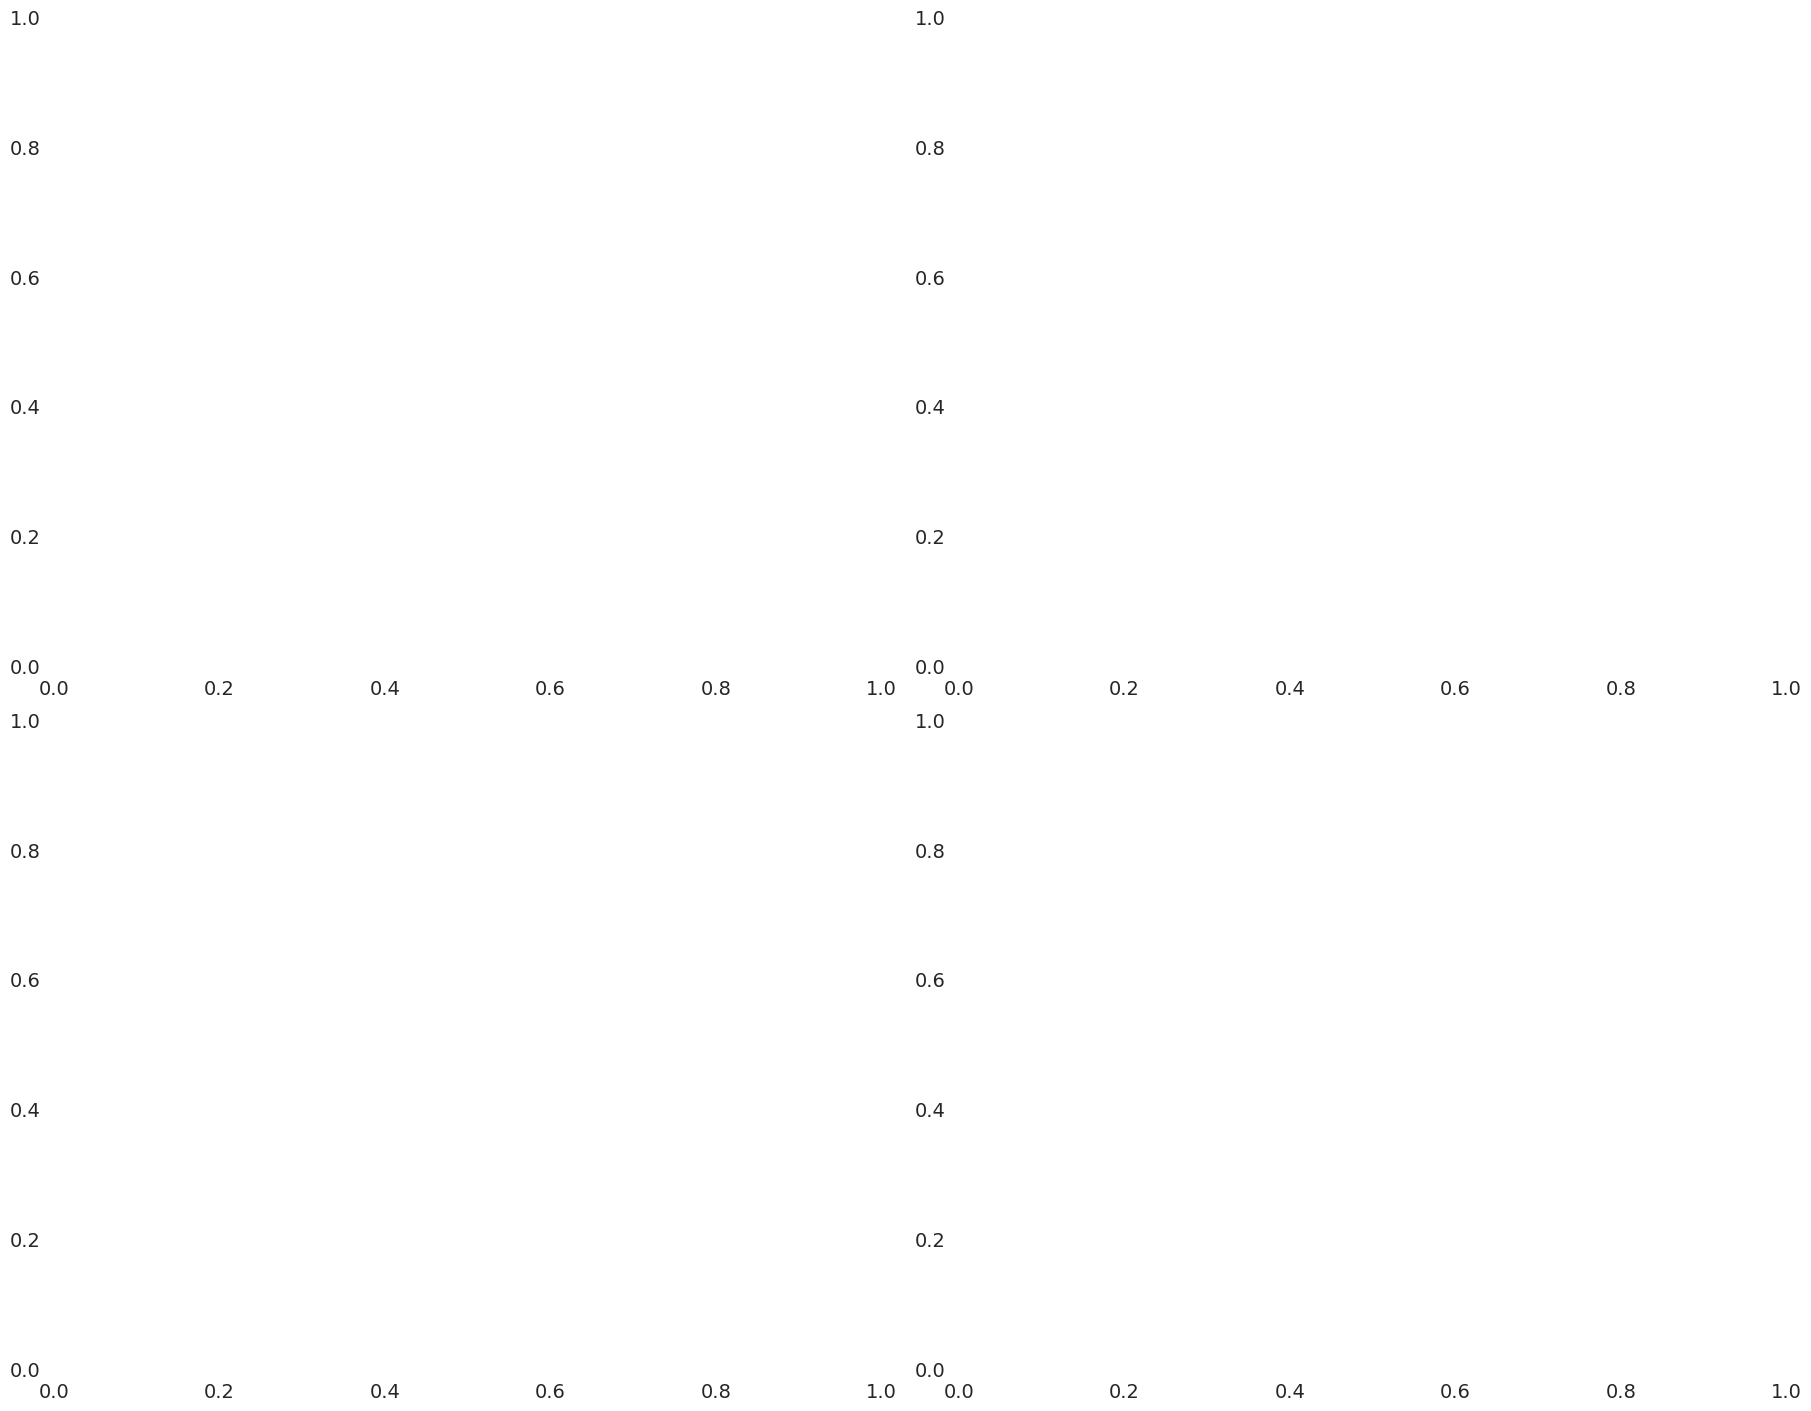

In [ ]:
#The plots for the NREL dataset: first SVD ~ real-time detected score results:
folder_path = 'NREL_Data_Results_SVD'
valid_extensions = ('.csv')
if not os.path.exists("NREL_Plots_SVD"):
    os.mkdir("NREL_Plots_SVD")
step_size = 4
list_files = os.listdir(folder_path)
for i in range(0, len(list_files), step_size):
    file_list = list_files[i:(i + step_size)]
    file_list = [folder_path + "/" + file for file in file_list]
    plot_battery_quad_SVD_polished(file_list, threshold = 0.3, point_before = 100, point_after = 100,
                      output_name = f'cell{i}_cell{i+step_size}_SVD_result_visualization_NREL.png')


## Plot the Simulated dataset:


In [ ]:
if not os.path.exists("Simulated_Datasets"):
    os.mkdir("Simulated_Datasets")

In [ ]:
import shutil
shutil.move('batteryCCCV_ordinary_54_ws_lower50_merged.csv', 'Simulated_Datasets/batteryCCCV_ordinary_54_ws_lower50_merged.csv')

'Simulated_Datasets/batteryCCCV_ordinary_54_ws_lower50_merged.csv'

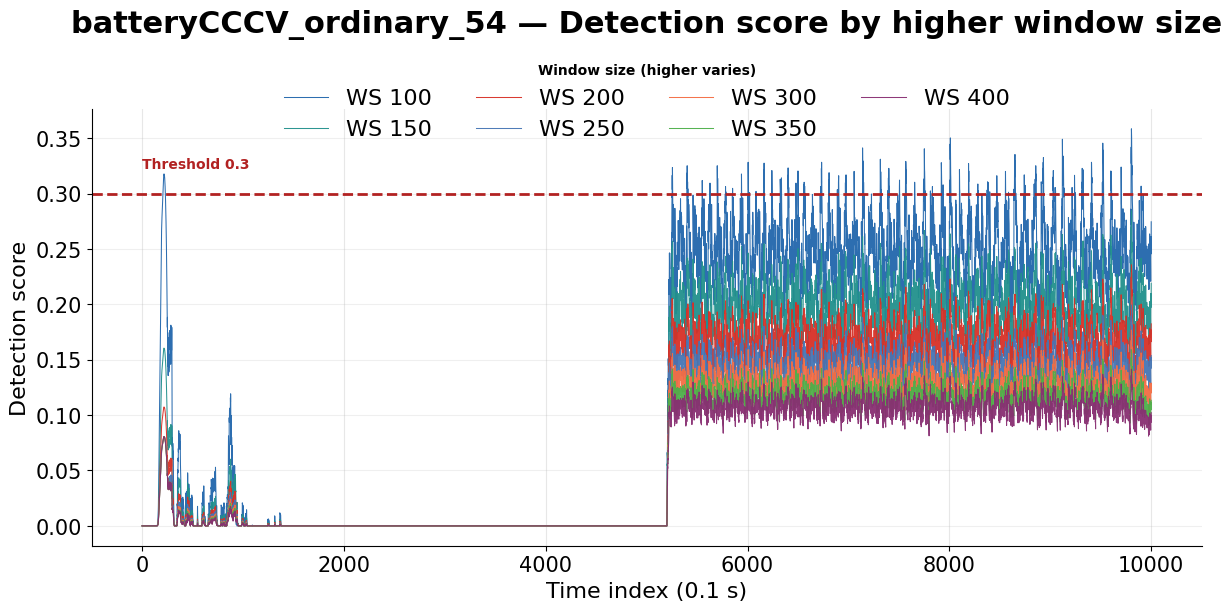

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
file_name = 'Simulated_Datasets/batteryCCCV_ordinary_54_ws_lower50_merged.csv'
apply_standard_style()
df = pd.read_csv(file_name)
ws_levels = sorted(df['window_size'].unique())
colors = {
    100: "#2166AC",  # blue
    150: "#21908C",  # teal
    200: "#D73027",  # red
    250: "#4575B4",  # steel blue
    300: "#F46D43",  # orange
    350: "#4DAF4A",  # green
    400: "#882E72"   # magenta
}
fig, ax = plt.subplots(figsize = (12, 6))
for ws in ws_levels:
    subset = df[df['window_size'] == ws]
    ax.plot(subset['time_ind'], subset['detected_value_rt'],
            label=f"WS {ws}", color=colors[ws], linewidth=0.75, alpha=0.95)
threshold = 0.3
ax.axhline(y=threshold, color="#B22222", linewidth=2.0, linestyle='--')
ax.text(df['time_ind'].min(), threshold + 0.02, "Threshold 0.3",
        color="#B22222", fontweight="bold", va='bottom', ha='left')
ax.set_xlabel("Time index (0.1 s)")
ax.set_ylabel("Detection score")
ax.set_title("batteryCCCV_ordinary_54 — Detection score by higher window size",
             fontweight='bold',
             pad=8,
             y=1.15)
ax.grid(True, axis='y', linestyle='-', alpha=0.2)
sns.despine()
legend = ax.legend(title="Window size (higher varies)", loc='upper center',
                   bbox_to_anchor=(0.5, 1.15), ncol=4, frameon=False)
plt.setp(legend.get_title(), fontweight='bold')
#Save the picture
if not os.path.exists("Simulated_Datasets_Plots"):
    os.mkdir("Simulated_Datasets_Plots")
output_file = "Simulated_Datasets_Plots/batteryCCCV_ordinary_54_ws_lower50_detection_overlay_py.png"
plt.savefig(output_file, bbox_inches='tight')


In [ ]:
def get_slope_calc(df, col_time, col_temp, t_start, t_end):
    """Calculates the slope of temperature over time for a given window."""
    subset = df[(df[col_time] >= t_start) & (df[col_time] <= t_end)]
    if len(subset) < 2:
        return 0.0
    slope, _ = np.polyfit(subset[col_time], subset[col_temp], 1)
    return slope

In [ ]:
def plot_minimal_pro_T(filename, threshold=0.3, point_before=100, point_after=100,
                      output_name=None):
    if output_name is None:
        base_name = os.path.splitext(os.path.basename(filename))
        output_name = f"{base_name}_minimal_pro.png"
    fig, ax = plt.subplots(figsize=(13.5, 10.0))
    df = pd.read_csv(filename)
    trigger_indices = df.index[df['detected_value_rt'] >= threshold].tolist()
    if trigger_indices:
        trigger_point = trigger_indices[0] # Grab the first trigger
        start_idx = max(0, trigger_point - point_before)
        end_idx = min(len(df), trigger_point + point_after)
        df_plot = df.iloc[start_idx:end_idx].reset_index(drop=True)
        val = df.iloc[trigger_point]['temperature']
        temp_at_trigger = float(val.iloc if hasattr(val, 'iloc') else val)
    else:
        df_plot = df.iloc[:min(len(df), 1500)].reset_index(drop=True)
        temp_at_trigger = None
    time_seconds = df_plot.index * 0.1
    #fig, ax = plt.subplots(figsize=(13.5, 9.5))
    ax.plot(time_seconds, df_plot['temperature'], color='darkblue', lw=3.5)
    ax.set_ylabel('Temperature (°C)', color='darkblue', fontsize=20, fontweight='bold')
    ax.tick_params(axis='y', labelcolor='darkblue')
    ax_score = ax.twinx()
    ax_score.plot(time_seconds, df_plot['detected_value_rt'], color='#d62728', lw=3.5)
    ax_score.axhline(y=threshold, color='green', ls='--', alpha=0.5)
    ax_score.set_ylim(-0.1, 1.1)
    ax_score.set_ylabel('Detected Score', color='#d62728', fontsize=18, fontweight='bold')
    ax_score.tick_params(axis='y', labelcolor='#d62728')
    ax.set_xlabel('Seconds', fontsize=20, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_visible(False)
    for spine in ax_score.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    ax_score.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=20, length=4)
    ax_score.tick_params(axis='y', which='major', labelsize=20, length=4)
    cell_name = os.path.basename(filename).split('-')
    title_text = f"Battery Cell Thermal Analysis"
    if temp_at_trigger is not None:
        title_text += f" | Temp at Trigger: {temp_at_trigger:.1f}°C"
    ax.set_title(title_text, fontsize=22, fontweight='bold', pad=30)
    plt.tight_layout()
    plt.savefig(output_name, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Clean numerical plot saved: {output_name}")

/tmp/ipykernel_12955/145017890.py:124: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax_temp.axvspan(tp, tp + win_size, color='blue', alpha = 0.15, linestyle='--', edgecolor='blue', linewidth=1)


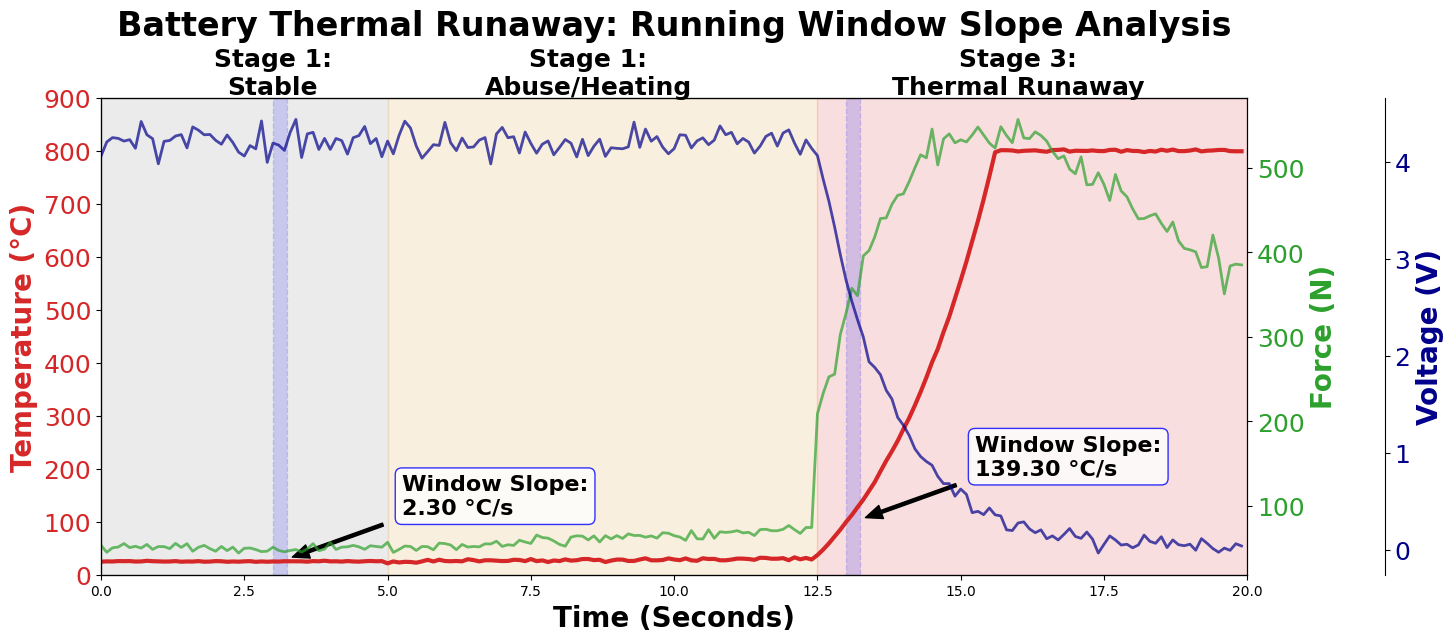

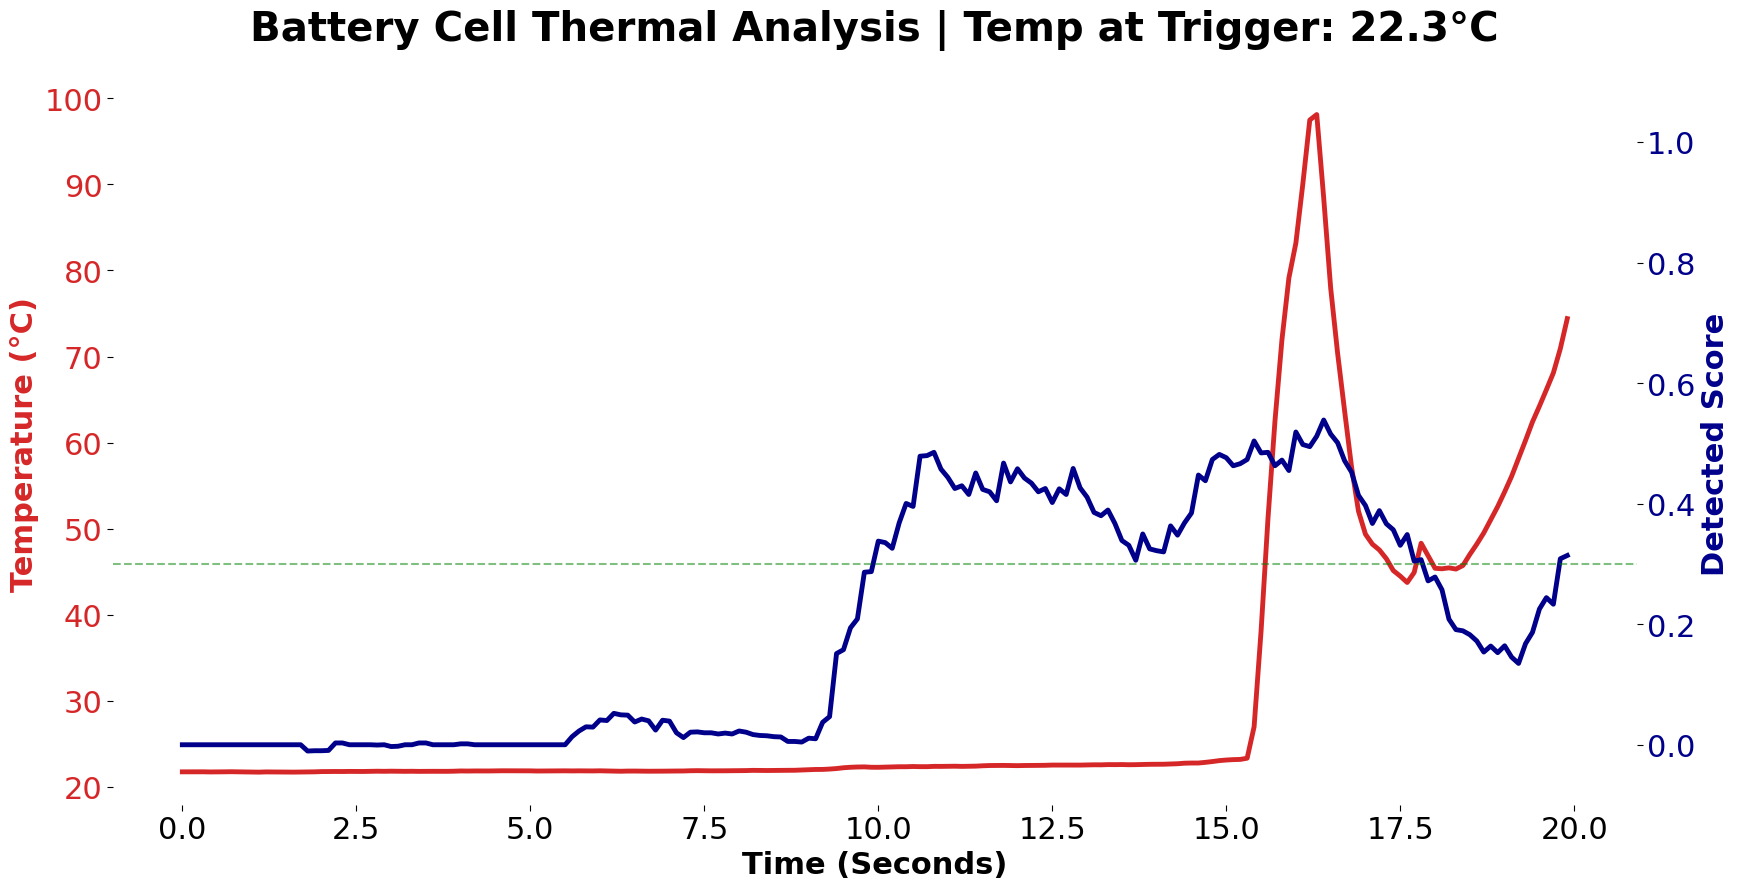

Clean numerical plot saved: Simulated_Datasets_Plots/Sorteria-Control-60SOC-cell1.xlsx_reform_severity_level7.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from adjustText import adjust_text
def plot_minimal_pro_T(filename, threshold=0.3, point_before=100, point_after=100,
                      output_name=None):
    if output_name is None:
        base_name = os.path.splitext(os.path.basename(filename))
        output_name = f"{base_name}_minimal_pro.png"
    fig, ax = plt.subplots(figsize=(17.5, 9.0))
    df = pd.read_csv(filename)
    trigger_indices = df.index[df['detected_value_rt'] >= threshold].tolist()
    if trigger_indices:
        trigger_point = trigger_indices[0] # Grab the first trigger
        start_idx = max(0, trigger_point - point_before)
        end_idx = min(len(df), trigger_point + point_after)
        df_plot = df.iloc[start_idx:end_idx].reset_index(drop=True)
        val = df.iloc[trigger_point]['temperature']
        temp_at_trigger = float(val.iloc if hasattr(val, 'iloc') else val)
    else:
        df_plot = df.iloc[:min(len(df), 1500)].reset_index(drop=True)
        temp_at_trigger = None
    time_seconds = df_plot.index * 0.1
    #fig, ax = plt.subplots(figsize=(13.5, 9.5))
    ax.plot(time_seconds, df_plot['temperature'], color='#d62728', lw=3.5)
    ax.set_ylabel('Temperature (°C)', color='#d62728', fontsize=22, fontweight='bold')
    ax.tick_params(axis='y', labelcolor='#d62728')
    ax_score = ax.twinx()
    ax_score.plot(time_seconds, df_plot['detected_value_rt'], color='darkblue', lw=3.5)
    ax_score.axhline(y=threshold, color='green', ls='--', alpha=0.5)
    ax_score.set_ylim(-0.1, 1.1)
    ax_score.set_ylabel('Detected Score', color='darkblue', fontsize=22, fontweight='bold')
    ax_score.tick_params(axis='y', labelcolor='darkblue')
    ax.set_xlabel('Time (Seconds)', fontsize=22, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_visible(False)
    for spine in ax_score.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    ax_score.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=22, length=4)
    ax_score.tick_params(axis='y', which='major', labelsize=22, length=4)
    cell_name = os.path.basename(filename).split('-')
    title_text = f"Battery Cell Thermal Analysis"
    if temp_at_trigger is not None:
        title_text += f" | Temp at Trigger: {temp_at_trigger:.1f}°C"
    ax.set_title(title_text, fontsize=29, fontweight='bold', pad=30)
    plt.tight_layout()
    plt.savefig(output_name, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Clean numerical plot saved: {output_name}")
def get_window_slope(df, t_start, window_size=10):
    t_end = t_start + window_size
    subset = df[(df['time'] >= t_start) & (df['time'] <= t_end)]
    if len(subset) < 2: return 0.0
    slope, _ = np.polyfit(subset['time'], subset['temperature'], 1)
    return slope

def simulate_battery_runaway(duration=150, dt=0.1):
    t = np.arange(0, duration, dt)
    n = len(t)
    t_abuse_start = 5
    t_tr_start = 12.5
    temp = np.zeros(n)
    for i, time in enumerate(t):
        if time < t_abuse_start:
            temp[i] = 25 + np.random.normal(0, 0.5)
        elif time < t_tr_start:
            temp[i] = 25 + 0.75 * (time - t_abuse_start) + np.random.normal(0, 1.5)
        else:
            growth = 10 * np.exp(0.5 * (time - t_tr_start))
            temp[i] = min(800, temp[i-1] + growth) + np.random.normal(0, 1.25)
    voltage = np.zeros(n)
    for i, time in enumerate(t):
        if time < t_tr_start:
            voltage[i] = 4.2 - 0.0005 * time + np.random.normal(0, 0.1)
        else:
            voltage[i] = max(0, 4.15 * np.exp(-0.8 * (time - t_tr_start))) + np.random.normal(0, 0.05)
    force = np.zeros(n)
    for i, time in enumerate(t):
        if time < t_abuse_start:
            force[i] = 50 + np.random.normal(0, 3)
        elif time < t_tr_start:
            force[i] = 50 + 3 * (time - t_abuse_start) + np.random.normal(0, 3.5)
        else:
            peak = 1500 * np.exp(-0.3 * (time - t_tr_start)) * np.abs(np.sin(0.2*(time-t_tr_start)))
            force[i] = 200 + peak + np.random.normal(0, 10)
    return pd.DataFrame({'time': t, 'temperature': temp, 'voltage': voltage, 'force': force})

df_sim = simulate_battery_runaway(duration = 20, dt = 0.1)
fig, ax_temp = plt.subplots(figsize=(17.5, 9.0))
fig.subplots_adjust(right=0.78, bottom=0.2, top = 0.73)
l1, = ax_temp.plot(df_sim['time'], df_sim['temperature'], color='#d62728', lw=3, label='Temperature')
ax_temp.set_ylabel('Temperature (°C)', color='#d62728', fontweight='bold', fontsize=20)
ax_temp.tick_params(axis='y', labelcolor='#d62728', labelsize=18)
ax_force = ax_temp.twinx()
ax_force.spines.right.set_position(("axes", 1.0))
l2, = ax_force.plot(df_sim['time'], df_sim['force'], color='#2ca02c', lw=2, alpha=0.7)
ax_force.set_ylabel('Force (N)', color='#2ca02c', fontweight='bold', fontsize=20)
ax_force.tick_params(axis='y', labelcolor='#2ca02c', labelsize=18)
ax_volt = ax_temp.twinx()
ax_volt.spines.right.set_position(("axes", 1.12))
l3, = ax_volt.plot(df_sim['time'], df_sim['voltage'], color='darkblue', lw=2, alpha=0.7)
ax_volt.set_ylabel('Voltage (V)', color='darkblue', fontweight='bold', fontsize=20)
ax_volt.tick_params(axis='y', labelcolor='darkblue', labelsize=18)
ax_temp.axvspan(0, 40, color = 'gray', alpha=0.05)
ax_temp.axvspan(40, 100, color = 'orange', alpha=0.08)
ax_temp.axvspan(100, 150, color = 'red', alpha=0.08)
ax_temp.axvspan(0, 5, color = 'gray', alpha=0.1)
ax_temp.text(3, 907, 'Stage 1:\nStable', ha='center', fontweight='bold', fontsize = 18)
ax_temp.axvspan(5, 12.5, color = 'orange', alpha=0.1)
ax_temp.text(8.5, 907, 'Stage 1:\nAbuse/Heating', ha='center', fontweight='bold', fontsize = 18)
ax_temp.axvspan(12.5, 20, color = 'red', alpha=0.1)
ax_temp.text(16, 907, 'Stage 3:\nThermal Runaway', ha='center', fontweight='bold', fontsize = 18)
ax_temp.set_title("Battery Thermal Runaway Analysis", fontweight='bold', pad=95, fontsize = 22)
win_size = 0.25
test_points = [3, 13]
texts = []

for tp in test_points:
    slope = get_window_slope(df_sim, tp, win_size)
    ax_temp.axvspan(tp, tp + win_size, color='blue', alpha = 0.15, linestyle='--', edgecolor='blue', linewidth=1)
    y_val = df_sim[df_sim['time'] == tp]['temperature'].values
    ax_temp.annotate(f'Window Slope:\n{slope:.2f} °C/s',
                     xy=(tp + win_size/2, y_val),
                     xytext=(tp + 2.25, y_val + 90),
                     arrowprops=dict(facecolor='black', shrink=0.1, width=2.25, headwidth=10),
                     fontsize=16, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="blue", alpha=0.8))
ax_temp.set_title("Battery Thermal Runaway: Running Window Slope Analysis", fontweight='bold', pad=45, fontsize=24)
ax_temp.set_xlabel('Time (Seconds)', fontsize=20, fontweight='bold')
ax_temp.set_xlim(0, 20)
ax_temp.set_ylim(0, 900)

plot_minimal_pro_T('T_Results_Whole/Sorteria-Control-60SOC-cell1.xlsx_reform_severity_level7.csv_rt_detect_result_window100.csv',
                   threshold = 0.3, output_name = 'Simulated_Datasets_Plots/Sorteria-Control-60SOC-cell1.xlsx_reform_severity_level7.png')

/tmp/ipykernel_12955/1100618980.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


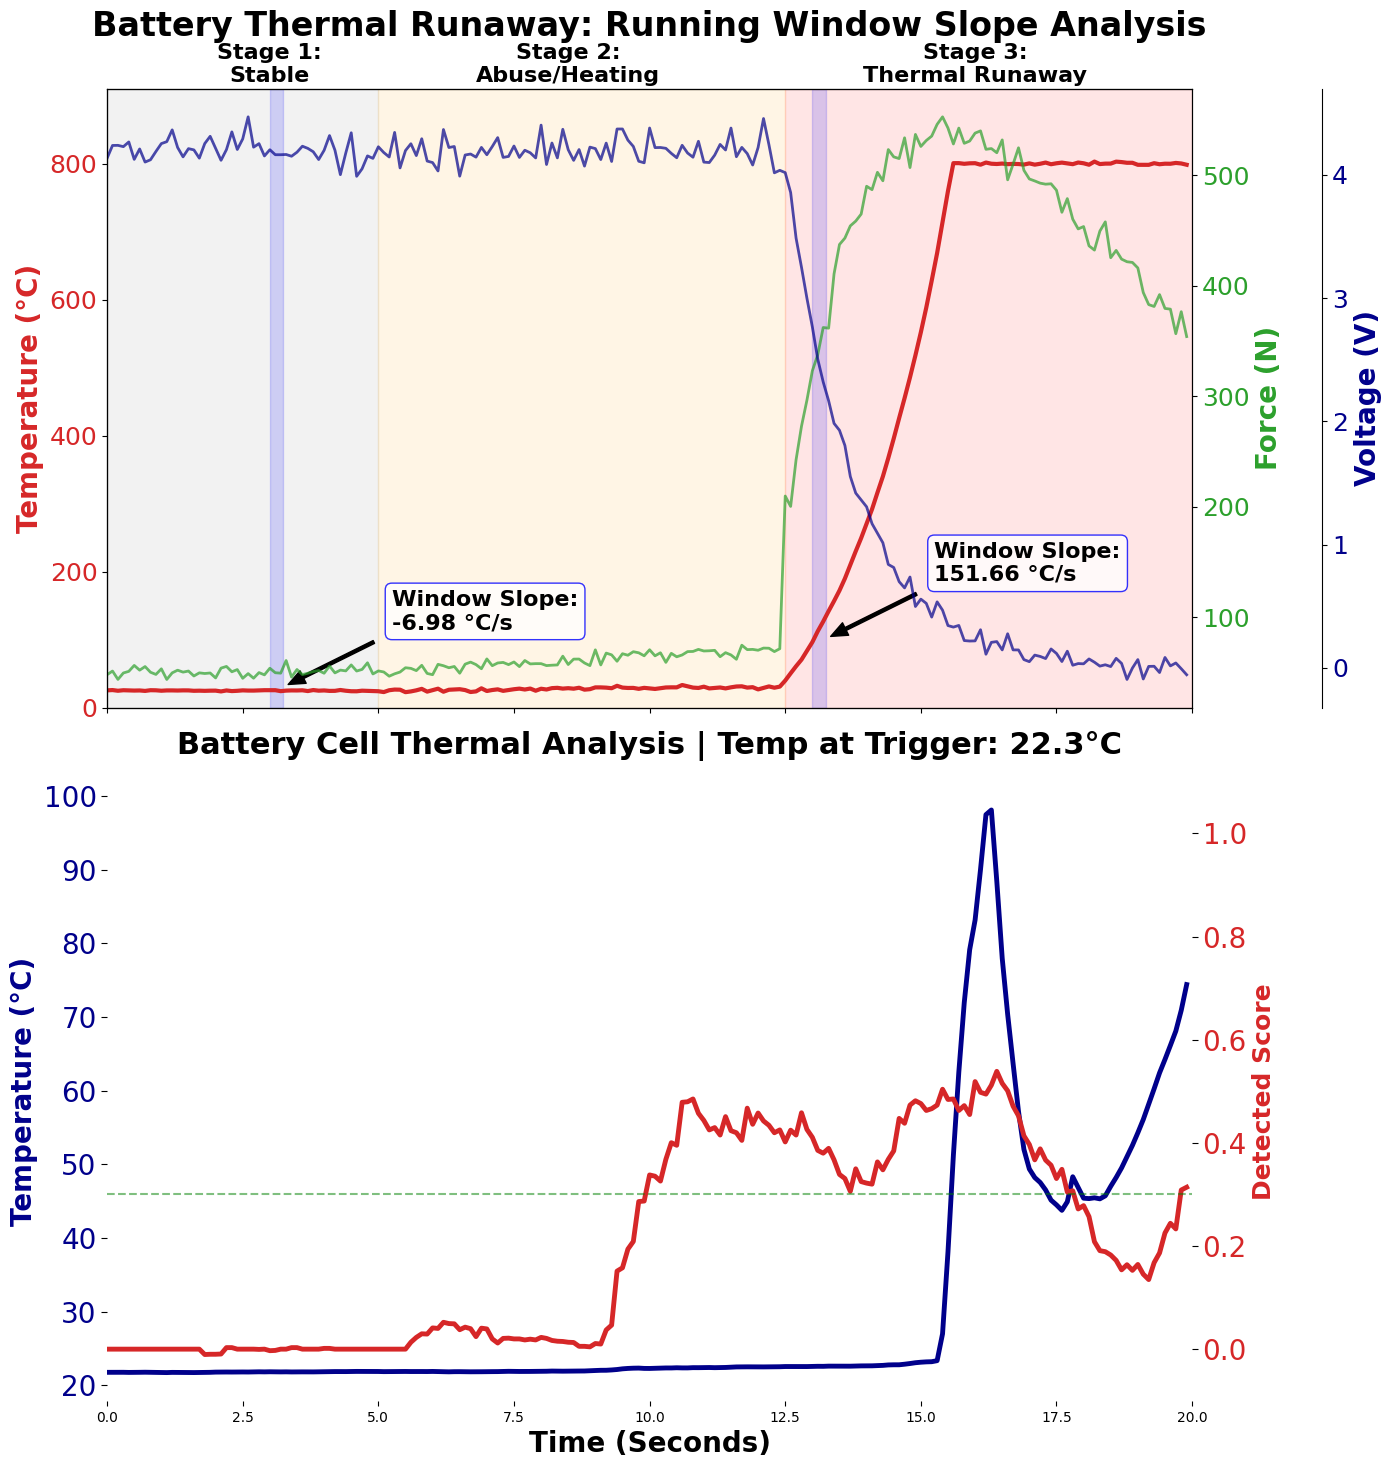

Combined figure saved: combined_shared_x_plot.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
#Drawing the slopes here:
def get_window_slope(df, t_start, window_size=10):
    t_end = t_start + window_size
    subset = df[(df['time'] >= t_start) & (df['time'] <= t_end)]
    if len(subset) < 2:
        return 0.0
    slope, _ = np.polyfit(subset['time'], subset['temperature'], 1)
    return slope
def simulate_battery_runaway(duration=150, dt=0.1):
    t = np.arange(0, duration, dt)
    n = len(t)
    t_abuse_start = 5
    t_tr_start = 12.5
    temp = np.zeros(n)
    for i, time in enumerate(t):
        if time < t_abuse_start:
            temp[i] = 25 + np.random.normal(0, 0.5)
        elif time < t_tr_start:
            temp[i] = 25 + 0.75 * (time - t_abuse_start) + np.random.normal(0, 1.5)
        else:
            growth = 10 * np.exp(0.5 * (time - t_tr_start))
            temp[i] = min(800, temp[i-1] + growth) + np.random.normal(0, 1.25)
    voltage = np.zeros(n)
    for i, time in enumerate(t):
        if time < t_tr_start:
            voltage[i] = 4.2 - 0.0005 * time + np.random.normal(0, 0.1)
        else:
            voltage[i] = max(0, 4.15 * np.exp(-0.8 * (time - t_tr_start))) + np.random.normal(0, 0.05)
    force = np.zeros(n)
    for i, time in enumerate(t):
        if time < t_abuse_start:
            force[i] = 50 + np.random.normal(0, 3)
        elif time < t_tr_start:
            force[i] = 50 + 3 * (time - t_abuse_start) + np.random.normal(0, 3.5)
        else:
            peak = 1500 * np.exp(-0.3 * (time - t_tr_start)) * np.abs(np.sin(0.2*(time-t_tr_start)))
            force[i] = 200 + peak + np.random.normal(0, 10)
    return pd.DataFrame({
        'time': t,
        'temperature': temp,
        'voltage': voltage,
        'force': force
    })


def plot_simulated_panel(ax_temp, df_sim):
    l1, = ax_temp.plot(df_sim['time'], df_sim['temperature'],
                       color='#d62728', lw=3, label='Temperature')
    ax_temp.set_ylabel('Temperature (°C)', color='#d62728',
                       fontweight='bold', fontsize=20)
    ax_temp.tick_params(axis='y', labelcolor='#d62728', labelsize=18)
    ax_force = ax_temp.twinx()
    ax_force.spines.right.set_position(("axes", 1.0))
    l2, = ax_force.plot(df_sim['time'], df_sim['force'],
                        color='#2ca02c', lw=2, alpha=0.7)
    ax_force.set_ylabel('Force (N)', color='#2ca02c',
                        fontweight='bold', fontsize=20)
    ax_force.tick_params(axis='y', labelcolor='#2ca02c', labelsize=18)
    ax_volt = ax_temp.twinx()
    ax_volt.spines.right.set_position(("axes", 1.12))
    l3, = ax_volt.plot(df_sim['time'], df_sim['voltage'],
                       color='darkblue', lw=2, alpha=0.7)
    ax_volt.set_ylabel('Voltage (V)', color='darkblue',
                       fontweight='bold', fontsize=20)
    ax_volt.tick_params(axis='y', labelcolor='darkblue', labelsize=18)
    ax_temp.axvspan(0, 5, color='gray', alpha=0.1)
    ax_temp.text(3, 920, 'Stage 1:\nStable',
                 ha='center', fontweight='bold', fontsize=16)
    ax_temp.axvspan(5, 12.5, color='orange', alpha=0.1)
    ax_temp.text(8.5, 920, 'Stage 2:\nAbuse/Heating',
                 ha='center', fontweight='bold', fontsize=16)
    ax_temp.axvspan(12.5, 20, color='red', alpha=0.1)
    ax_temp.text(16, 920, 'Stage 3:\nThermal Runaway',
                 ha='center', fontweight='bold', fontsize=16)
    win_size = 0.25
    test_points = [3, 13]
    for tp in test_points:
        slope = get_window_slope(df_sim, tp, win_size)
        ax_temp.axvspan(tp, tp + win_size, color='blue', alpha=0.15)
        y_val = df_sim.loc[np.isclose(df_sim['time'], tp), 'temperature'].values[0]
        ax_temp.annotate(
            f'Window Slope:\n{slope:.2f} °C/s',
            xy=(tp + win_size/2, y_val),
            xytext=(tp + 2.25, y_val + 90),
            arrowprops=dict(facecolor='black', shrink=0.1, width=2.25, headwidth=10),
            fontsize=16, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="blue", alpha=0.8)
        )
    ax_temp.set_title("Battery Thermal Runaway: Running Window Slope Analysis",
                      fontweight='bold', pad=38, fontsize=24)
    ax_temp.set_xlim(0, 20)
    ax_temp.set_ylim(0, 910)
    return ax_force, ax_volt


def plot_minimal_pro_T_panel(ax, filename, threshold=0.3, point_before=100, point_after=100):
    df = pd.read_csv(filename)
    trigger_indices = df.index[df['detected_value_rt'] >= threshold].tolist()
    if trigger_indices:
        trigger_point = trigger_indices[0]
        start_idx = max(0, trigger_point - point_before)
        end_idx = min(len(df), trigger_point + point_after)
        df_plot = df.iloc[start_idx:end_idx].reset_index(drop=True)
        val = df.iloc[trigger_point]['temperature']
        temp_at_trigger = float(val.iloc if hasattr(val, 'iloc') else val)
    else:
        df_plot = df.iloc[:min(len(df), 1500)].reset_index(drop=True)
        temp_at_trigger = None
    time_seconds = df_plot.index * 0.1
    ax.plot(time_seconds, df_plot['temperature'], color='darkblue', lw=3.5)
    ax.set_ylabel('Temperature (°C)', color='darkblue',
                  fontsize=20, fontweight='bold')
    ax.tick_params(axis='y', labelcolor='darkblue', labelsize=20, length=4)
    ax_score = ax.twinx()
    ax_score.plot(time_seconds, df_plot['detected_value_rt'],
                  color='#d62728', lw=3.5)
    ax_score.axhline(y=threshold, color='green', ls='--', alpha=0.5)
    ax_score.set_ylim(-0.1, 1.1)
    ax_score.set_ylabel('Detected Score', color='#d62728',
                        fontsize=18, fontweight='bold')
    ax_score.tick_params(axis='y', labelcolor='#d62728', labelsize=20, length=4)
    for spine in ax.spines.values():
        spine.set_visible(False)
    for spine in ax_score.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    ax_score.grid(False)
    title_text = "Battery Cell Thermal Analysis"
    if temp_at_trigger is not None:
        title_text += f" | Temp at Trigger: {temp_at_trigger:.1f}°C"
    ax.set_title(title_text, fontsize=22, fontweight='bold', pad=20)
    return ax_score

def plot_combined_shared_x(
    rt_filename,
    threshold=0.3,
    point_before=100,
    point_after=100,
    output_name='combined_shared_x_plot.png'
):
    df_sim = simulate_battery_runaway(duration=20, dt=0.1)
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(14, 16),
        sharex=True,
        gridspec_kw={'hspace': 0.12}
    )
    ax1_force, ax1_volt = plot_simulated_panel(ax1, df_sim)
    ax2_score = plot_minimal_pro_T_panel(
        ax2,
        rt_filename,
        threshold=threshold,
        point_before=point_before,
        point_after=point_after
    )
    ax2.set_xlabel('Time (Seconds)', fontsize=20, fontweight='bold')
    ax2.set_xlim(0, 20)
    fig.subplots_adjust(top=0.93)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(output_name, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Combined figure saved: {output_name}")
plot_combined_shared_x(
    rt_filename='T_Results_Whole/Sorteria-Control-60SOC-cell1.xlsx_reform_severity_level7.csv_rt_detect_result_window100.csv',
    threshold=0.3,
    point_before=100,
    point_after=100,
    output_name='combined_shared_x_plot.png'
)

/tmp/ipykernel_2691/1442834257.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.08, 1, 0.95])


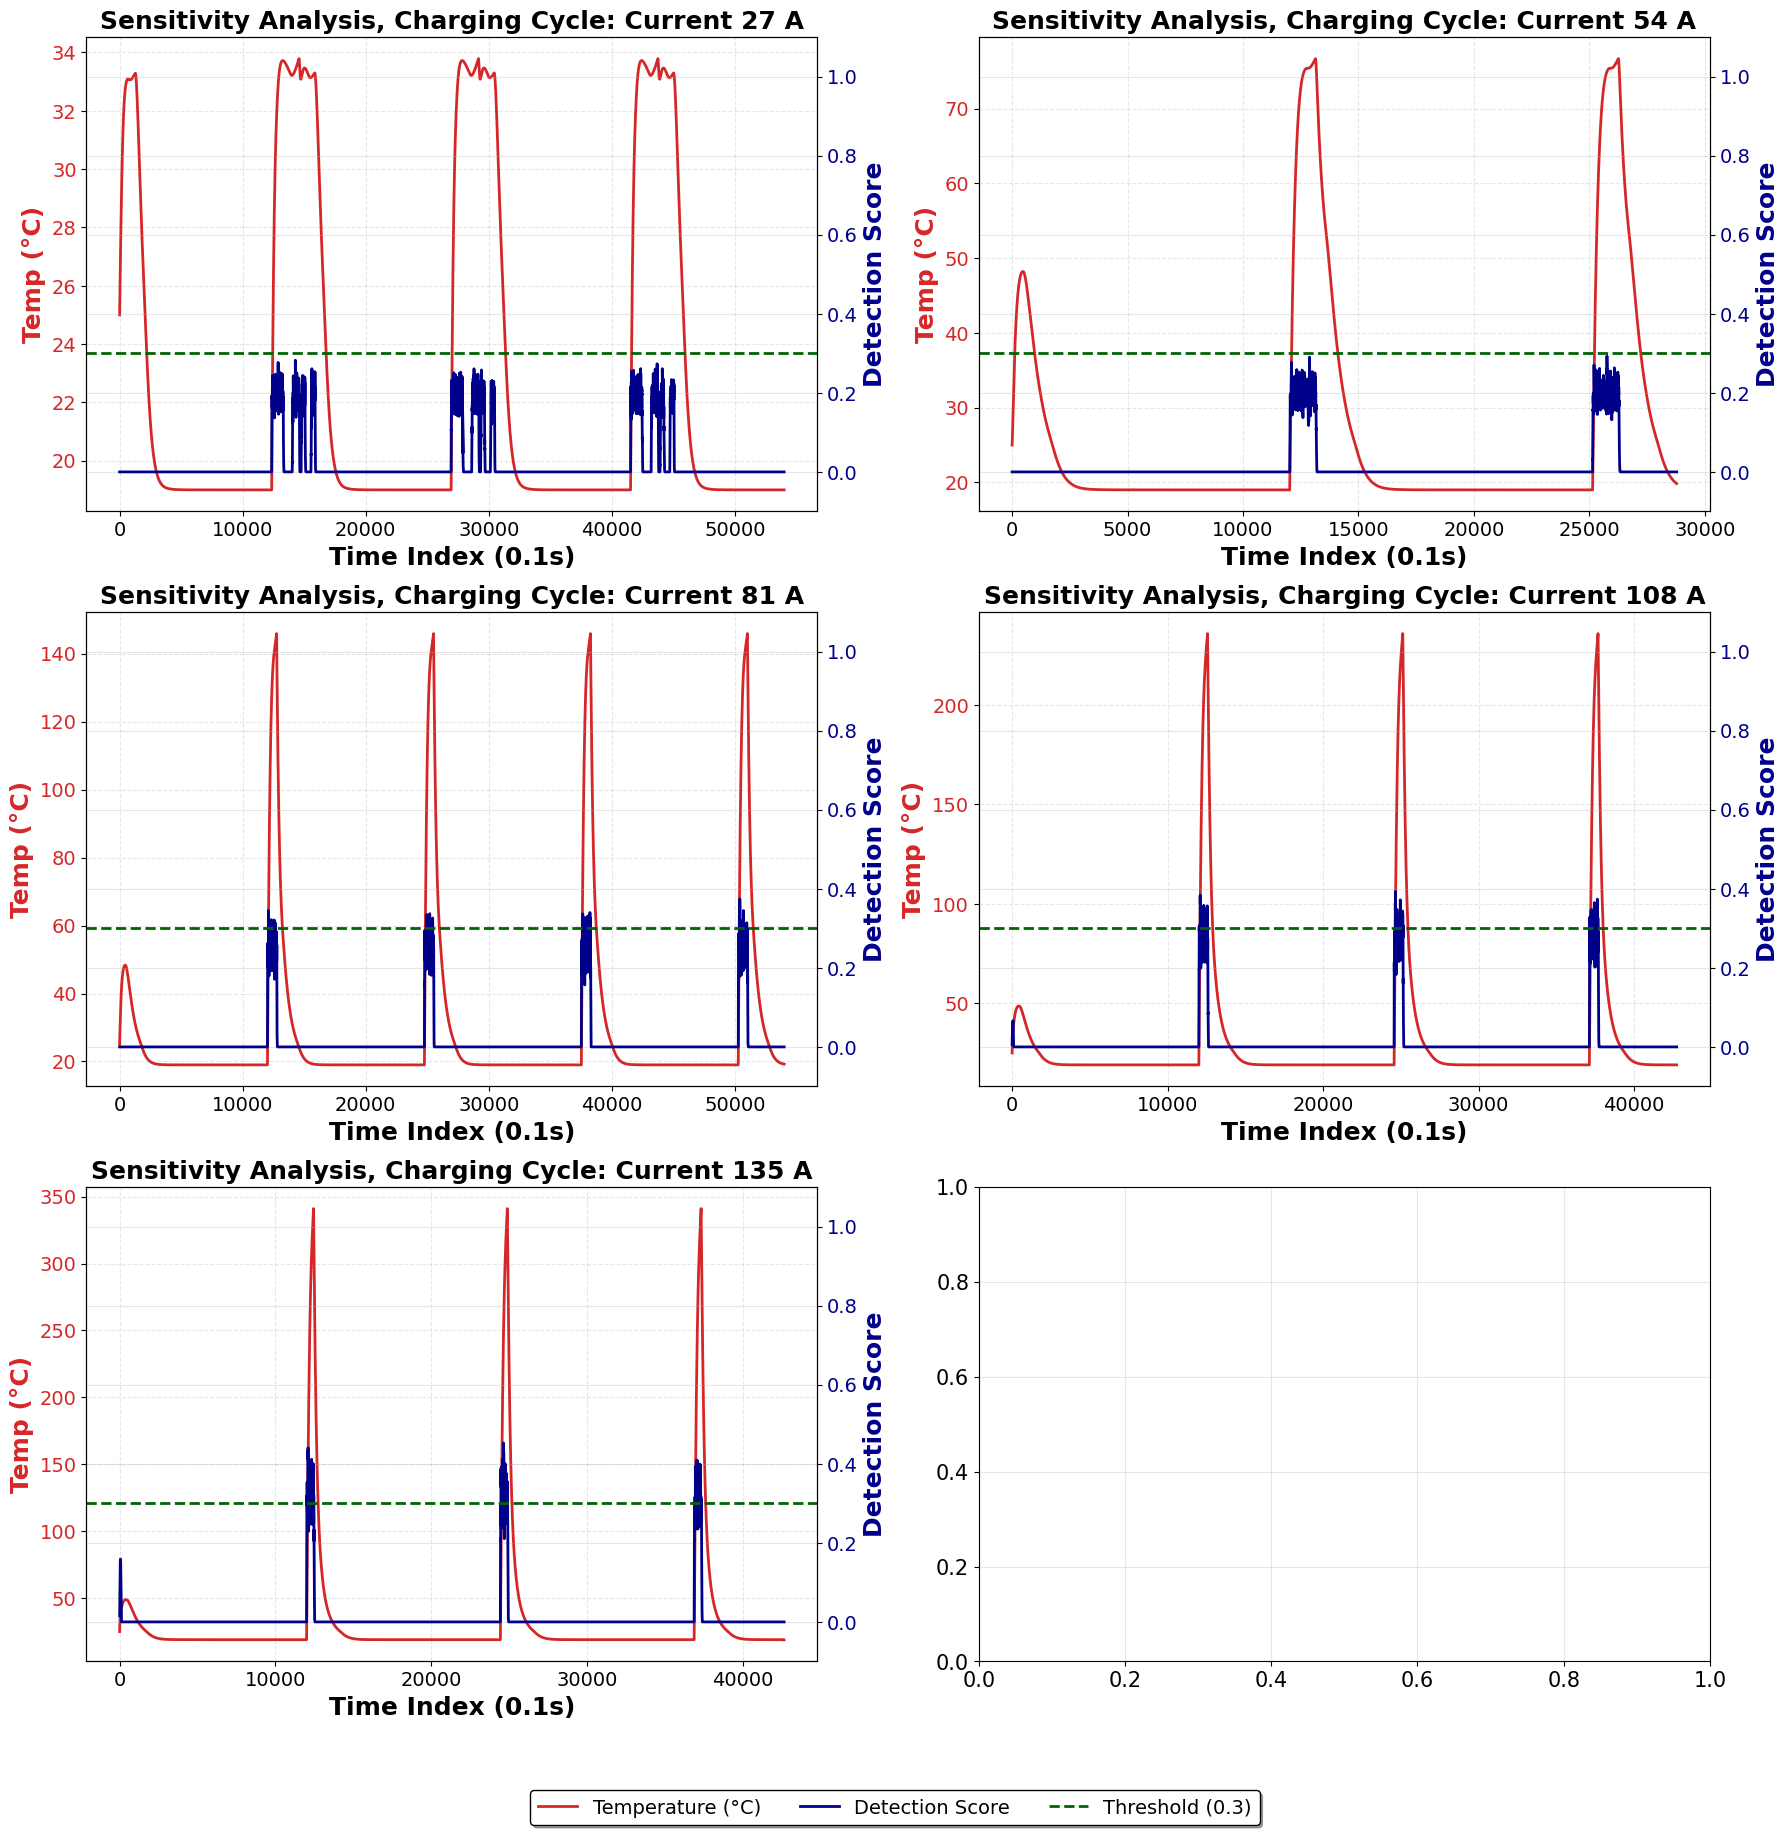

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
currents =[27, 54, 81, 108, 135]
files = [f"df_t_batterycccv{c}.csv" for c in currents]
THRESHOLD = 0.3
plt.rcParams.update({'font.family': 'sans-serif', 'figure.facecolor': 'white'})
LABEL_SIZE, TICK_SIZE, TITLE_SIZE = 18, 14, 18
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
axes = axes.flatten()
handles = []
for i, (amp, fname) in enumerate(zip(currents, files)):
    ax1 = axes[i]
    df = pd.read_csv("Simulated_Datasets/" + fname)
    df['temp_C'] = df['signal'] - 273.15 #Transform from F to C
    l1, = ax1.plot(df['time_ind'], df['temp_C'], color='#d62728', lw=2.0)
    ax1.set_ylabel('Temp (°C)', color='#d62728', fontweight='bold', fontsize=LABEL_SIZE)
    ax1.set_xlabel('Time Index (0.1s)', fontweight='bold', fontsize=LABEL_SIZE)
    ax1.tick_params(axis='both', labelsize=TICK_SIZE)
    ax1.tick_params(axis='y', labelcolor='#d62728')
    ax1.grid(True, linestyle='--', alpha=0.3)
    # 2. Right Axis: Real-time Detection Score
    ax2 = ax1.twinx()
    l2, = ax2.plot(df['time_ind'], df['detected_value_rt'], color='darkblue', lw=2.0)
    ax2.set_ylabel('Detection Score', color='darkblue', fontweight='bold', fontsize=LABEL_SIZE)
    ax2.tick_params(axis='y', labelcolor='darkblue', labelsize=TICK_SIZE)
    ax2.set_ylim(-0.1, 1.1)
    # 3. Thresholding Line
    l3 = ax2.axhline(y=THRESHOLD, color='darkgreen', linestyle='--', lw=2.0)
    ax1.set_title(f"Sensitivity Analysis, Charging Cycle: Current {amp} A", fontsize=TITLE_SIZE, fontweight='bold')
    if i == 0:
        handles = [l1, l2, l3]
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
# Adding the legend
fig.legend(handles, ['Temperature (°C)', 'Detection Score', f'Threshold ({THRESHOLD})'],
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.03),
           frameon=True, edgecolor='black', shadow=True, fontsize=TICK_SIZE)
plt.savefig("Simulated_Datasets_Plots/Battery_MultiCurrent_3by2.png", dpi=300)
plt.show()


In [ ]:
def apply_standard_style():
    """The plots configs"""
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "axes.titlesize": 20,
        "axes.labelsize": 16,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 18,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "savefig.dpi": 300,
        "figure.constrained_layout.use": True,
        "figure.facecolor": 'white',
        'axes.facecolor': 'white'
    })

/tmp/ipykernel_2691/223688719.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.08, 1, 0.95])


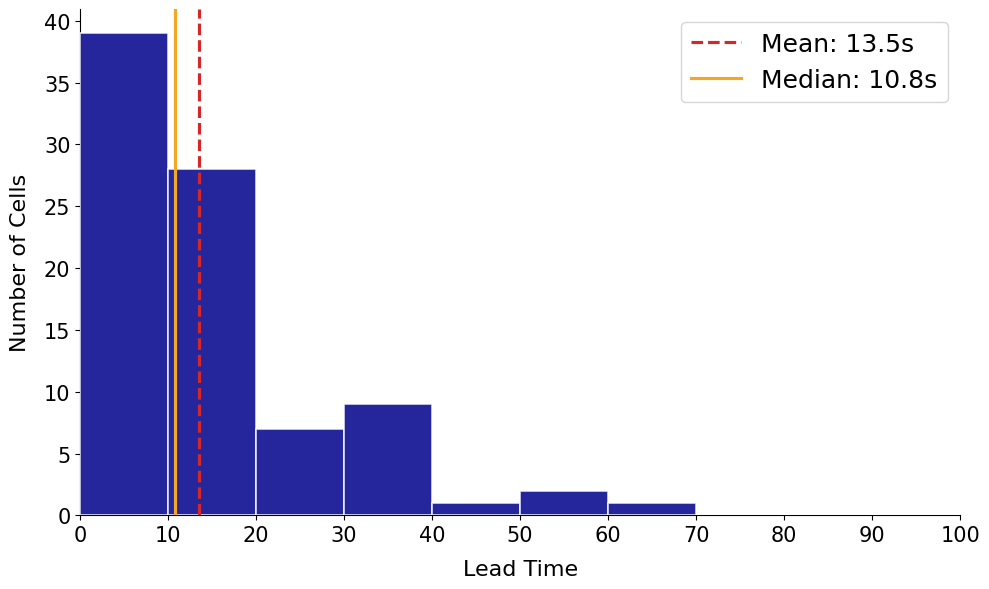

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('Simulated_Datasets/dataset_description_with_time3.csv')
data = pd.to_numeric(df["second_buy"], errors='coerce').dropna()
data = data[(data >= 0) & (data <= 80)]
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
bins = np.arange(0, 101, 10)
ax.hist(data, bins=bins, color='darkblue', edgecolor="white", linewidth=1.2, alpha=0.85, zorder=3)
mean_val, median_val = data.mean(), data.median()
ax.axvline(mean_val, color='#d62728', linestyle="--", linewidth=2.25, label=f"Mean: {mean_val:.1f}s", zorder=4)
ax.axvline(median_val, color="#F5A623", linestyle="-", linewidth=2.25, label=f"Median: {median_val:.1f}s", zorder=4)
#ax.set_title(f"Lead Time Distribution", pad=20, fontweight='bold', fontsize = 20)
ax.set_xlabel("Lead Time", labelpad=10, fontsize = 16)
ax.set_ylabel("Number of Cells", labelpad=10, fontsize = 16)
ax.set_xlim(0, 100)
ax.set_xticks(bins)
#ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0)
for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.legend(loc="upper right", fontsize = 18)
ax.grid(False)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.tight_layout()
plt.savefig('Lead_Time_Distribution.png')
plt.show()